# Connect Forest Management Model with Forest Carbon Budget Model

In [14]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import ws3.forest
import time
import gurobipy as grb
import pickle
import libcbm
import os
from util import compile_events, cbm_report, compile_scenario_maxstock, plot_scenario_maxstock, run_cbm_emissionstock, run_scenario, plugin_c_curves, plugin_c_curves_both, cbm_report_both, compare_ws3_cbm, compare_ws3_cbm_both, track_system_stock, track_system_emission, compile_scenario_minemission, plot_scenario_minemission, kpi_age, kpi_species, cmp_c_ss, cmp_c_se, results_scenarios, bootstrap_ogi, compare_kpi_age

In [15]:
base_year = 2020
horizon = 10
period_length = 10
max_age = 1000
n_steps = 100
tvy_name = 'totvol'
max_harvest = 1.0

In [16]:
# Define scenario options based on case study
scenario_options = {
    'redchris': ['no_cons','evenflow_cons', 'redchrs_AAC_90%', 'redchrs_AAC_80%', 'redchrs_AAC_70%', 'redchrs_AAC_60%', 'redchrs_AAC_50%', 'redchrs_AAC_40%', 'redchrs_AAC_30%', 'redchrs_AAC_20%', 'redchrs_AAC_10%' ],
    'goldenbear': ['no_cons', 'evenflow_cons', 'gldbr_AAC_90%', 'gldbr_AAC_80%', 'gldbr_AAC_70%', 'gldbr_AAC_60%', 'gldbr_AAC_50%', 'gldbr_AAC_40%', 'gldbr_AAC_30%', 'gldbr_AAC_20%', 'gldbr_AAC_10%'],
    'equitysilver': [ 'no_cons','evenflow_cons', 'eqtslvr_AAC_90%', 'eqtslvr_AAC_80%', 'eqtslvr_AAC_70%', 'eqtslvr_AAC_60%', 'eqtslvr_AAC_50%', 'eqtslvr_AAC_40%', 'eqtslvr_AAC_30%', 'eqtslvr_AAC_20%', 'eqtslvr_AAC_10%'],
    'test': ['no_cons', 'evenflow_cons', 'bau_redchrs']
}

# Function to handle case study selection and update scenario dropdown
def select_case_study(case_study):
    print(f"Selected case study: {case_study}")
    # Update the scenario dropdown based on the selected case study
    scenario_dropdown.options = scenario_options.get(case_study, [])
    scenario_dropdown.value = scenario_options[case_study][0]  # Set a default value

# Case study dropdown
case_study_dropdown = widgets.Dropdown(
    options=['redchris', 'goldenbear', 'equitysilver', 'test'],
    value='goldenbear',
    description='Case Study:'
)
case_study_dropdown.observe(lambda change: select_case_study(change['new']), names='value')
display(case_study_dropdown)

# Function to handle scenario selection
def select_scenario(scenario_name):
    print(f"Selected scenario: {scenario_name}")

# Scenario dropdown
scenario_dropdown = widgets.Dropdown(
    options=scenario_options['redchris'],  # Set initial options based on default case study
    value=scenario_options['redchris'][1],  # Set initial value
    description='Scenario:'
)
scenario_dropdown.observe(lambda change: select_scenario(change['new']), names='value')
display(scenario_dropdown)

# Function to handle objective functon
def select_obj(obj_mode):
    print(f"Selected objective: {obj_mode}")
obj_dropdown = widgets.Dropdown(
    options=['max_hv', 'min_ha', 'max_st', 'min_em'],
    value='min_ha',
    description='Objective:'
)
display(obj_dropdown)
obj_dropdown.observe(lambda change: select_obj(change['new']), names='value')

Dropdown(description='Case Study:', index=1, options=('redchris', 'goldenbear', 'equitysilver', 'test'), value…

Dropdown(description='Scenario:', index=1, options=('no_cons', 'evenflow_cons', 'bau_redchrs', 'redchrs_AAC_90…

Dropdown(description='Objective:', index=1, options=('max_hv', 'min_ha', 'max_st', 'min_em'), value='min_ha')

In [17]:
# Initialize main widget components 
hwp_pool_effect = widgets.FloatSlider(min=0, max=1, step=1, description='HWP_effect', value=1, layout=widgets.Layout(margin='10px 0'))
release_immediately = widgets.FloatSlider(min=0, max=1, step=1, description='Release immediately', value=1, layout=widgets.Layout(margin='10px 0'))
displacement_effect = widgets.FloatSlider(min=0, max=1, step=1, description='Displacement', value=1, layout=widgets.Layout(margin='10px 0'))
clt_percentage = widgets.FloatSlider(min=0, max=1, step=0.1, description='CLT_percent:', value=0.5, layout=widgets.Layout(margin='10px 0'))
credibility = widgets.FloatSlider(min=0, max=1, step=0.1, description='Credibility:', value=1, layout=widgets.Layout(margin='10px 0'))
# max_harvest = widgets.FloatSlider(min=0, max=1, step=0.05, description='Max_harvest:', value=1.0, layout=widgets.Layout(margin='10px 0'))
budget_input = widgets.FloatText(value=10000000, description='Budget:', layout=widgets.Layout(margin='10px 0'))

release_immediately.layout.display = 'none' if hwp_pool_effect.value != 0 else 'block'
displacement_effect.layout.display = 'block' if hwp_pool_effect.value != 0 else 'none'
clt_percentage.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'
credibility.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'

container = widgets.VBox([
    hwp_pool_effect, release_immediately, displacement_effect, clt_percentage, credibility, budget_input  
    # ,max_harvest
])

display(container)

def update_widgets(change):
    hwp_pool_effect_value = hwp_pool_effect.value
    displacement_effect_value = displacement_effect.value

    release_immediately.layout.display = 'block' if hwp_pool_effect_value == 0 else 'none'
    displacement_effect.layout.display = 'block' if hwp_pool_effect_value != 0 else 'none'

    clt_percentage.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'
    credibility.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'

hwp_pool_effect.observe(update_widgets, names='value')
displacement_effect.observe(update_widgets, names='value')

In [18]:
#Start Calculating the Running Time
Start = time.time()

In [19]:
case_study = case_study_dropdown.value
scenario_name = scenario_dropdown.value
obj_mode = obj_dropdown.value
hwp_pool_effect_value = hwp_pool_effect.value
release_immediately_value = release_immediately.value if hwp_pool_effect_value == 0 else 0
displacement_effect = displacement_effect.value if hwp_pool_effect_value != 0 else 0
clt_percentage = clt_percentage.value if displacement_effect != 0 else 0
credibility = credibility.value if displacement_effect != 0 else 0
# max_harvest = max_harvest.value
budget_input = budget_input.value

In [20]:
# Define case study mappings and retrieve model details based on case study
case_study_options = {
    'redchris': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris'
    },
    'goldenbear': {
        'model_name': 'goldenbear',
        'model_path': './data/woodstock_model_files_goldenbear'
    },
    'equitysilver': {
        'model_name': 'equitysilver',
        'model_path': './data/woodstock_model_files_equitysilver'
    },
    'test': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris_test'
    }
}

model_info = case_study_options.get(case_study)

if model_info:
    model_name = model_info['model_name']
    model_path = model_info['model_path']
else:
    print('The case study name is not valid')


In [21]:
# Create and Run `ForestModel` instance
fm = ws3.forest.ForestModel(model_name=model_name,
                            model_path=model_path,
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()
fm.grow()

In [22]:
# Flag 'harvest' as a harvesting action in the ws3 model
harvest_acode='harvest'
fm.actions[harvest_acode].is_harvest = True

In [23]:
# Read curves
file_directory = "./inputs/curves"
file_names = [f"{case_study}_c_curves_p.pkl", f"{case_study}_c_curves_f.pkl"]
loaded_data = {}

for filename in file_names:
    file_path = os.path.join(file_directory, filename)
    with open(file_path, 'rb') as file:
        loaded_data[filename] = pickle.load(file)
    print(f"Loaded data from {file_path}")

c_curves_p = loaded_data.get(f"{case_study}_c_curves_p.pkl")
c_curves_f = loaded_data.get(f"{case_study}_c_curves_f.pkl")

Loaded data from ./inputs/curves/goldenbear_c_curves_p.pkl
Loaded data from ./inputs/curves/goldenbear_c_curves_f.pkl


In [24]:
# Plug carbon and old groth yield curves into forest model
plugin_c_curves_both(fm, c_curves_p, c_curves_f)
bootstrap_ogi(fm)

Running for goldenbear_min_ha_no_cons...
running no_cons scenario
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3905 rows, 36130 columns and 36130 nonzeros
Model fingerprint: 0x801989dc
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 3905 rows and 36130 columns
Presolve time: 0.03s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.04 seconds (0.01 work units)
Optimal objective  0.000000000e+00


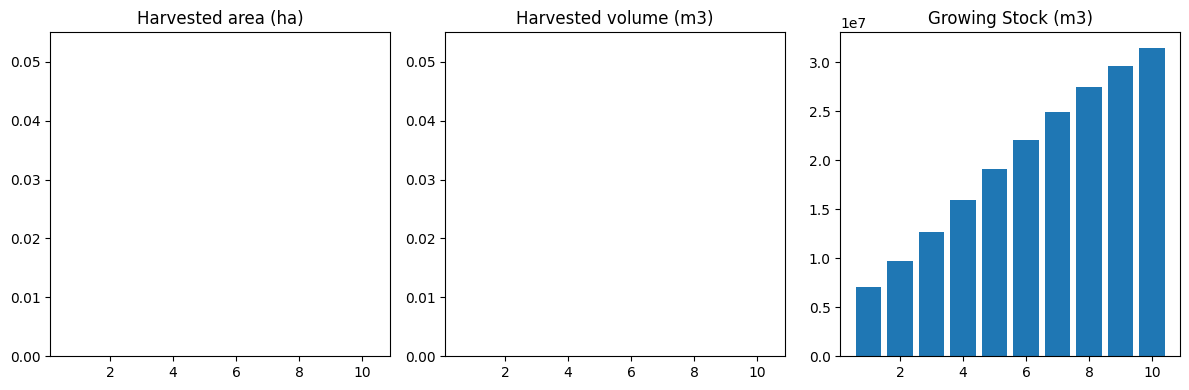

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_no_cons_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  0
The economic indicator (the provincial government revenues) is:  0
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


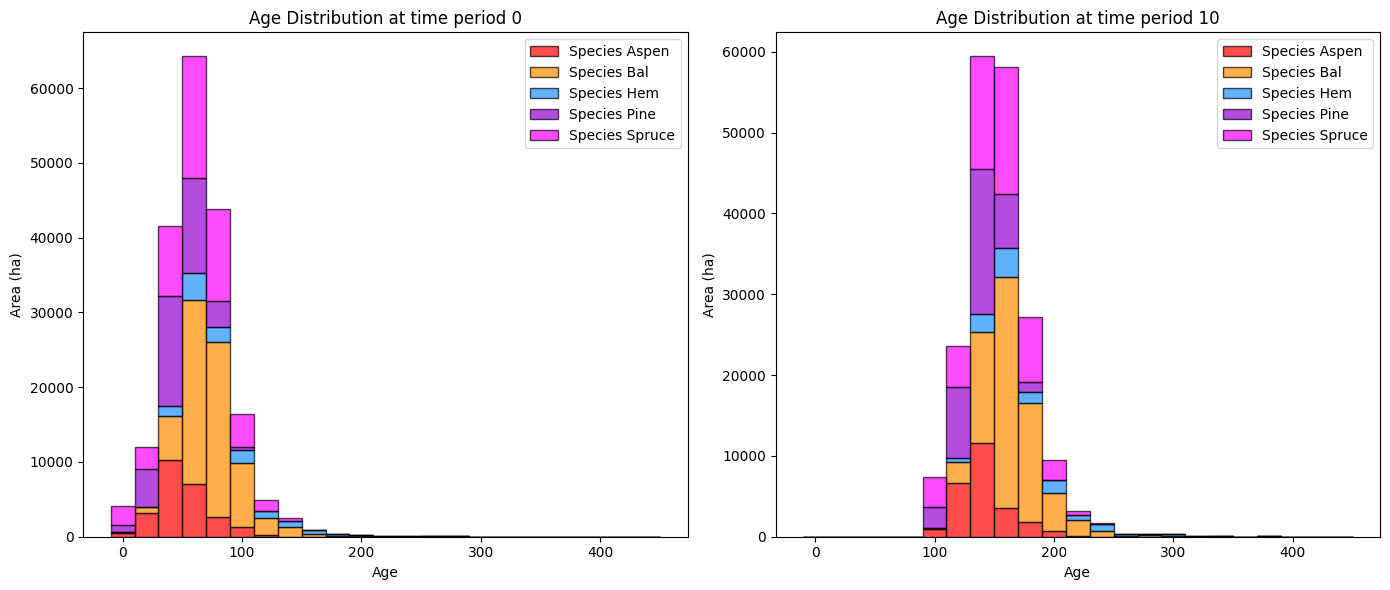

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_no_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   8040.264040   8037.555506
Bal     278.565372  15963.007735  15684.442363
Aspen   273.490478  13191.618272  12918.127794
Pine      0.000000   7631.887200   7631.887200
Hem     419.699331   3929.593538   3509.894208

Overall diversity has **increased** by 47781.91 hectares from time period 0 to time period 10.


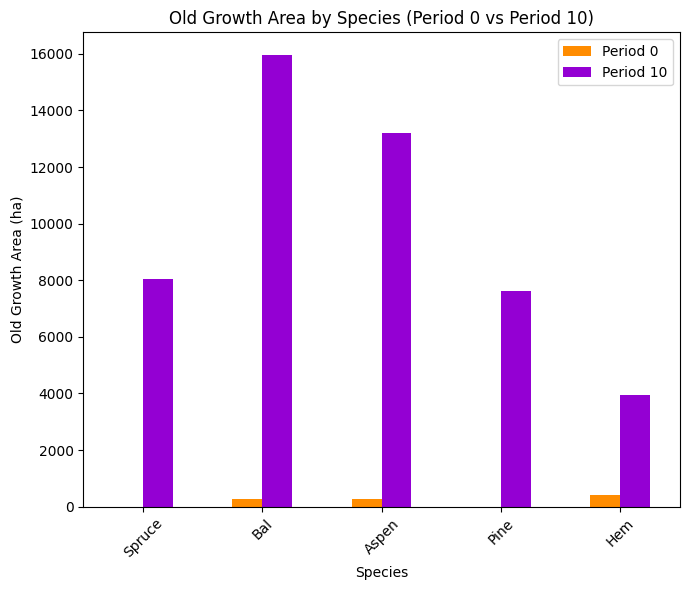

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_no_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9285

Diversity has **decreased** by 1.71% from time 0 to time 10.


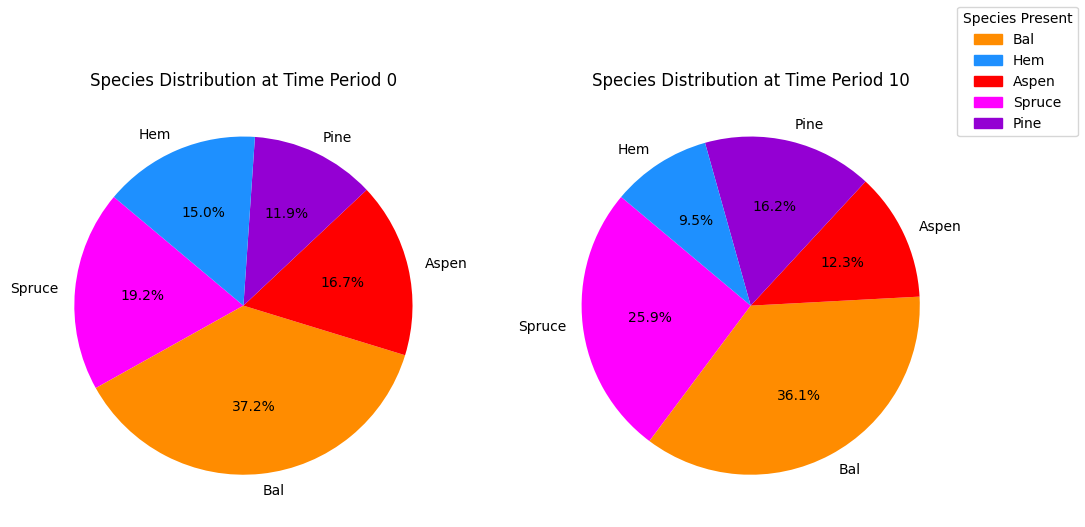

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_no_cons_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x17162bc7
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.23s
Presolved: 1911 rows, 32225 columns, 407291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00

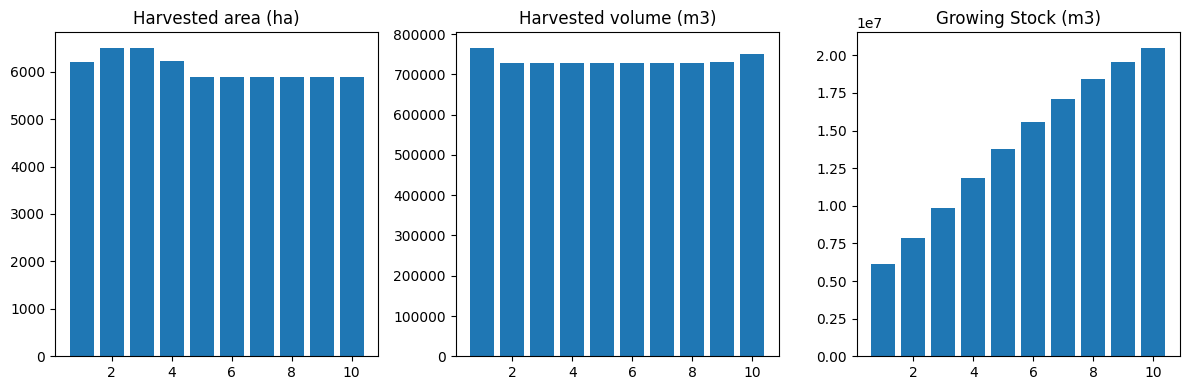

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7759
The economic indicator (the provincial government revenues) is:  264628
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


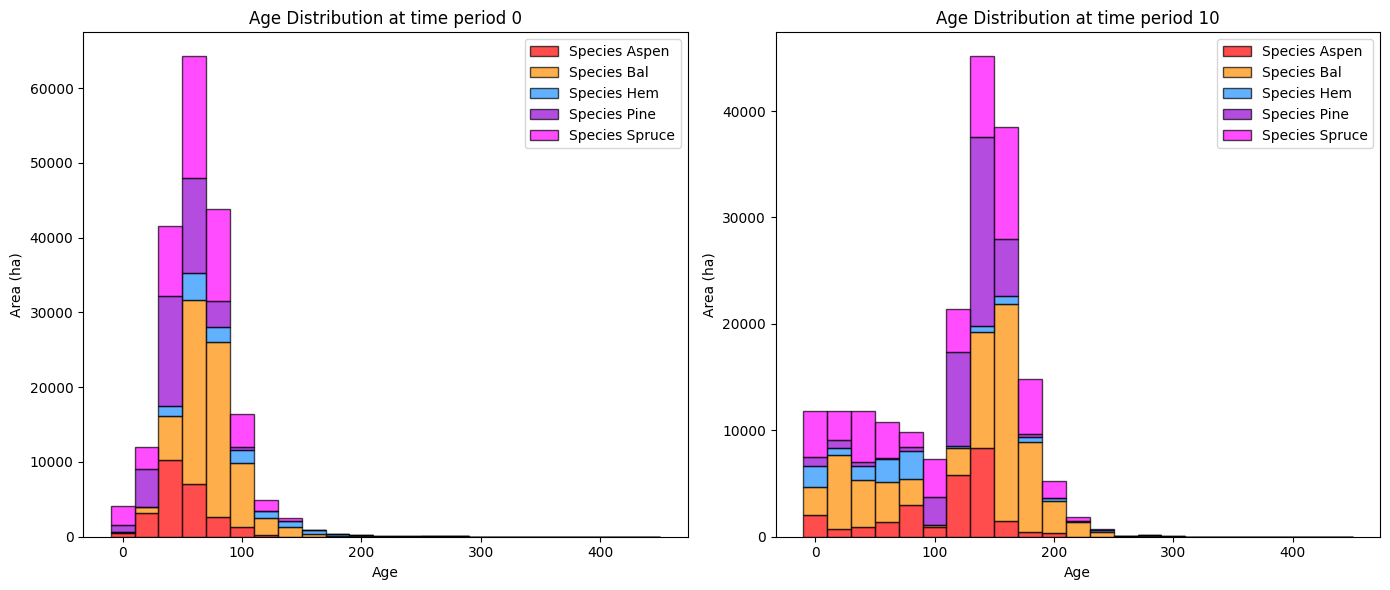

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4259.936249  4257.227716
Bal     278.565372  9020.773269  8742.207898
Aspen   273.490478  6525.108441  6251.617963
Pine      0.000000  5968.010518  5968.010518
Hem     419.699331   801.166864   381.467533

Overall diversity has **increased** by 25600.53 hectares from time period 0 to time period 10.


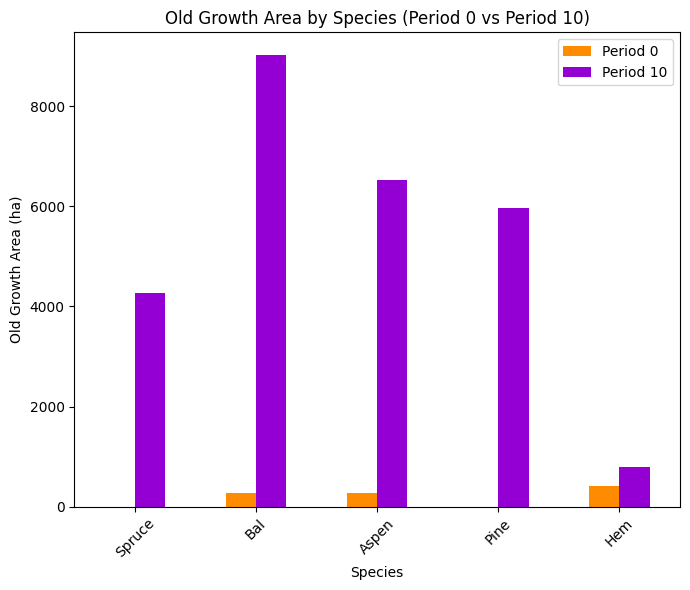

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9003

Diversity has **decreased** by 4.53% from time 0 to time 10.


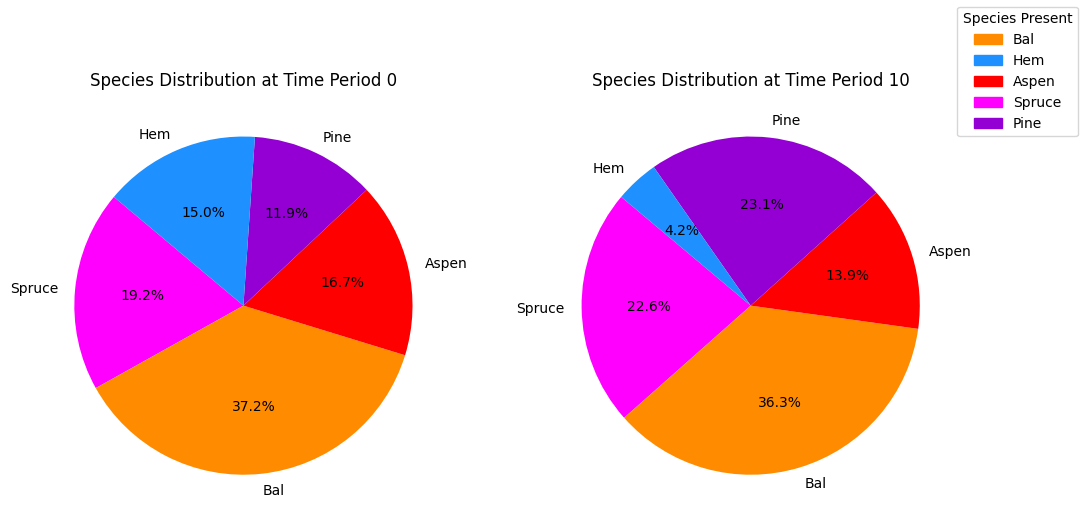

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_species_pie.pdf


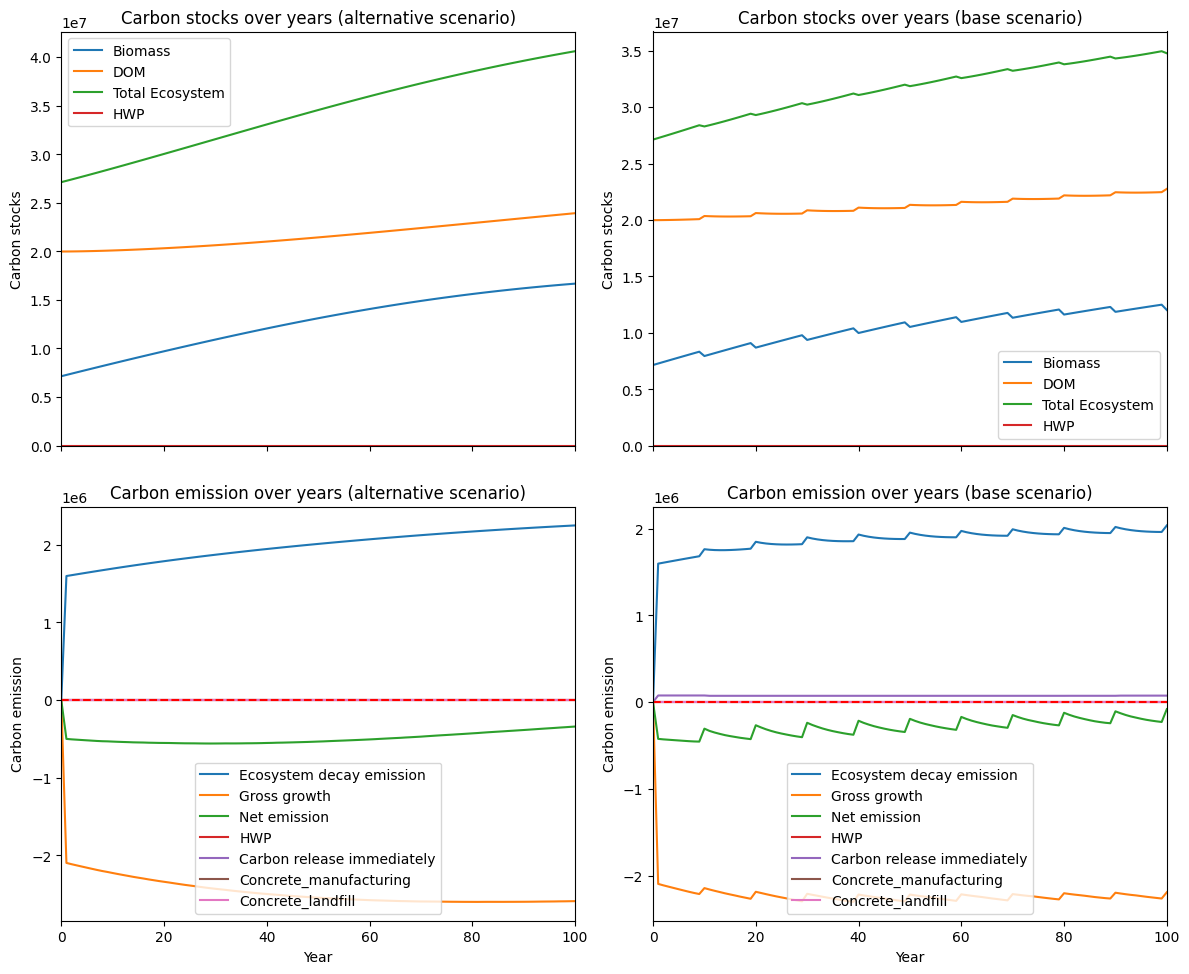

---------------------------------------------------------------------------------------
Net emission difference -3550581.138939184
Net emission base scenario -12873402.697854219
Net emission alternative scenario -9322821.558915036
dollar_per_ton is:  2.816440354039543
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  3780.327790  3780.327790
Bal     0.0  6942.234465  6942.234465
Aspen   0.0  6666.509832  6666.509832
Pine    0.0  1663.876682  1663.876682
Hem     0.0  3128.426675  3128.426675

Overall, the old growth area has **increased** by 22181.38 hectares in the alternative scenario compared to the base scenario.


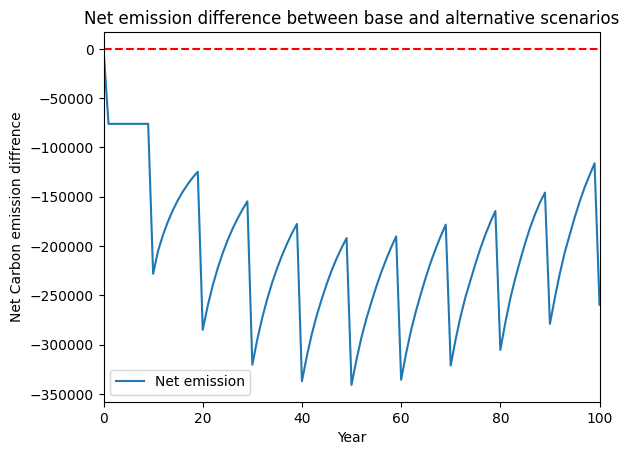

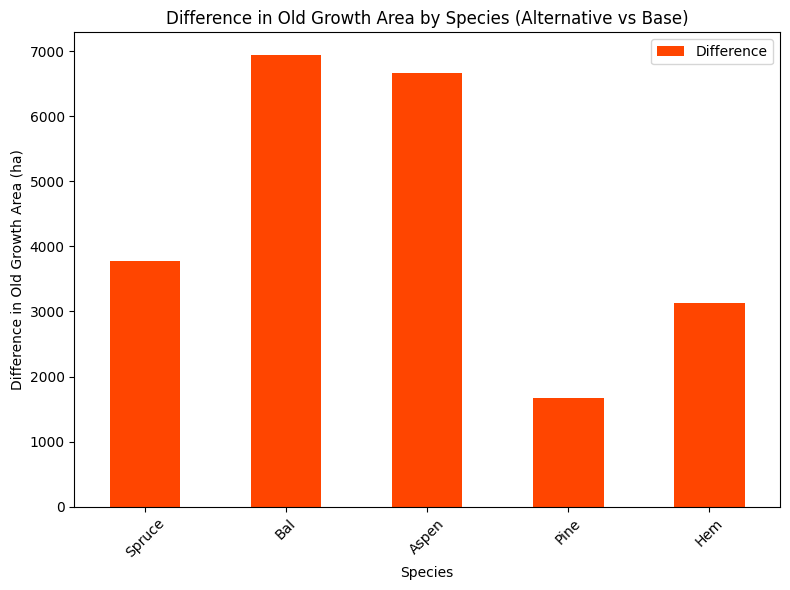

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_age_difference.pdf


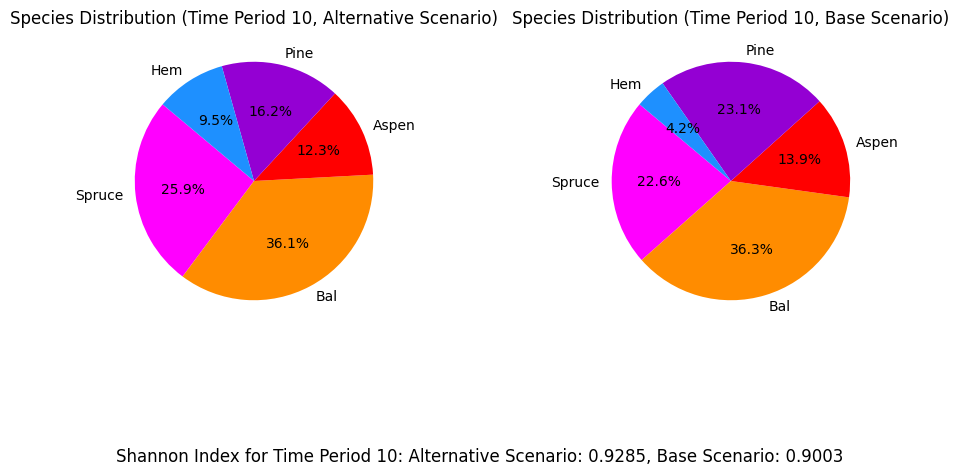

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_ha_evenflow_cons...
running even flow constraints scenario
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3945 rows, 36130 columns and 430076 nonzeros
Model fingerprint: 0xa2964300
Coefficient statistics:
  Matrix range     [1e-02, 9e+04]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 3945 rows and 36130 columns
Presolve time: 0.05s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   0.000000e+00   0.000000e+00  

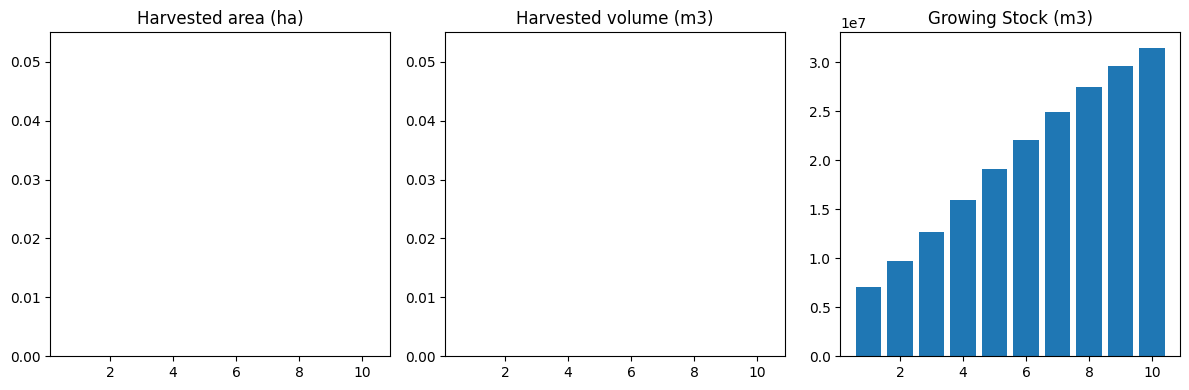

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_evenflow_cons_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  0
The economic indicator (the provincial government revenues) is:  0
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


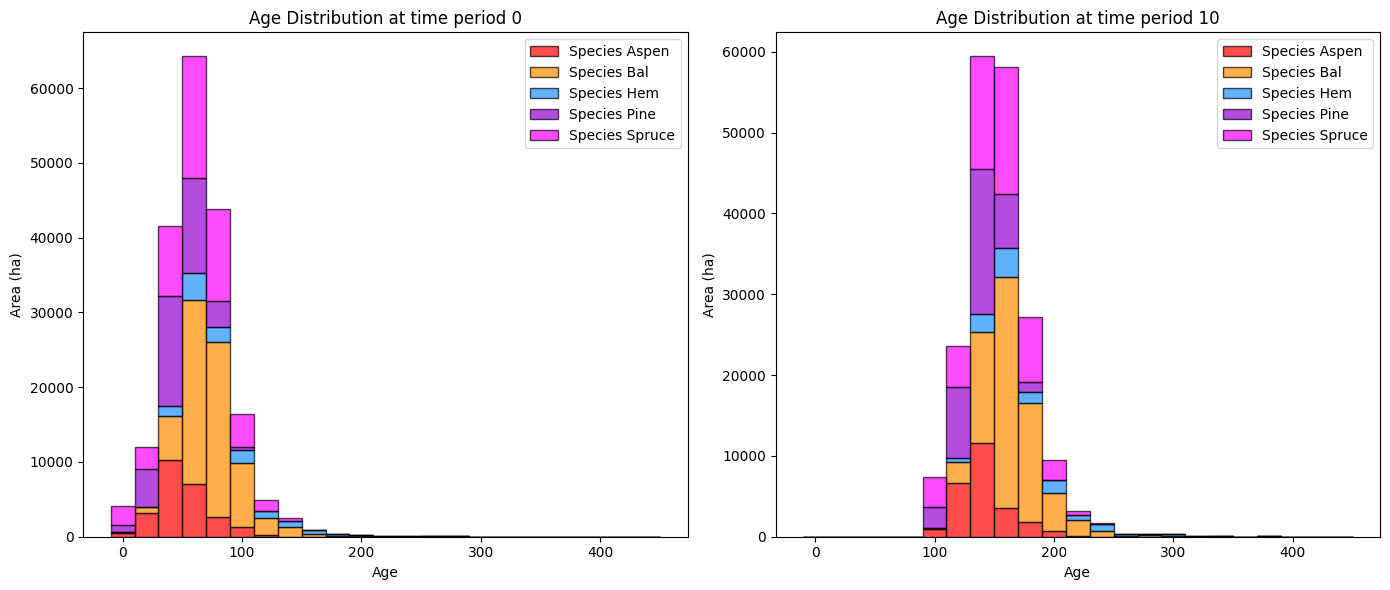

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_evenflow_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   8040.264040   8037.555506
Bal     278.565372  15963.007735  15684.442363
Aspen   273.490478  13191.618272  12918.127794
Pine      0.000000   7631.887200   7631.887200
Hem     419.699331   3929.593538   3509.894208

Overall diversity has **increased** by 47781.91 hectares from time period 0 to time period 10.


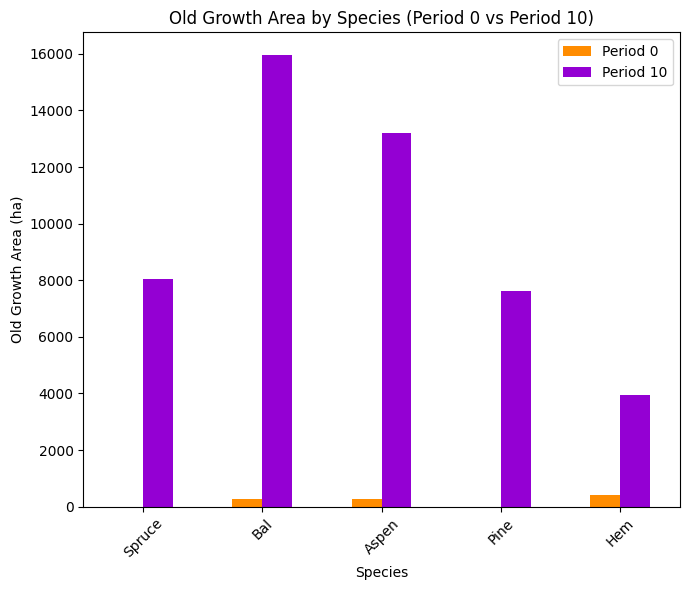

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_evenflow_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9285

Diversity has **decreased** by 1.71% from time 0 to time 10.


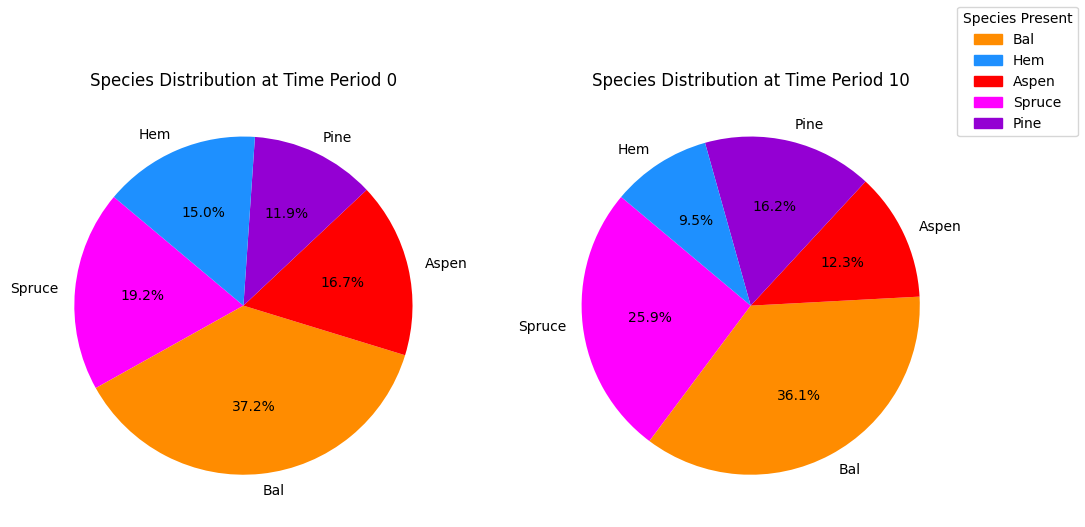

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_evenflow_cons_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x17162bc7
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.19s
Presolved: 1911 rows, 32225 columns, 407291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

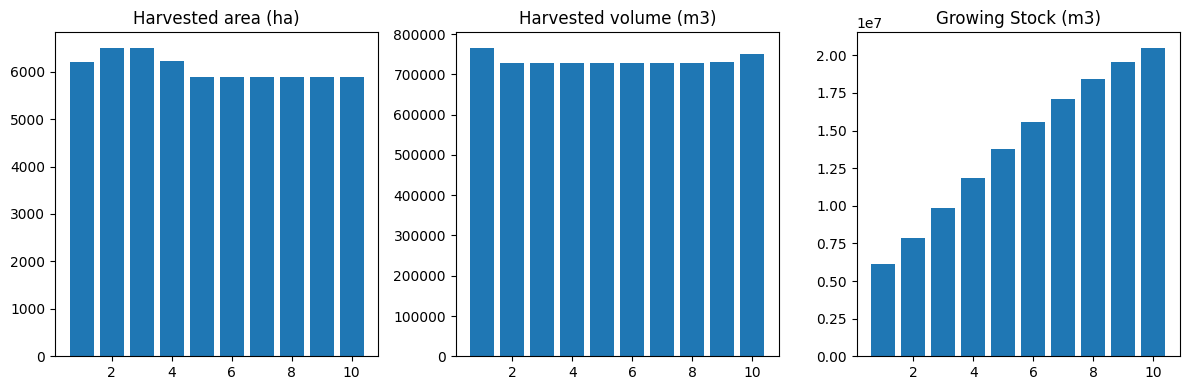

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7759
The economic indicator (the provincial government revenues) is:  264628
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


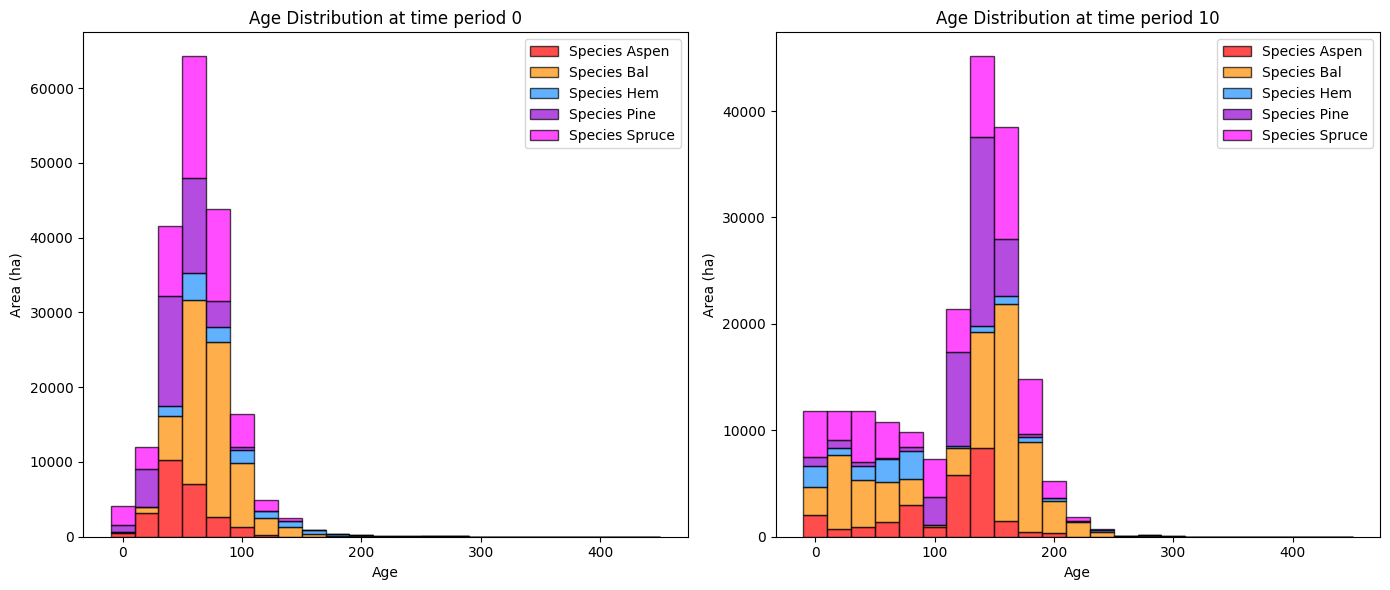

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4259.936249  4257.227716
Bal     278.565372  9020.773269  8742.207898
Aspen   273.490478  6525.108441  6251.617963
Pine      0.000000  5968.010518  5968.010518
Hem     419.699331   801.166864   381.467533

Overall diversity has **increased** by 25600.53 hectares from time period 0 to time period 10.


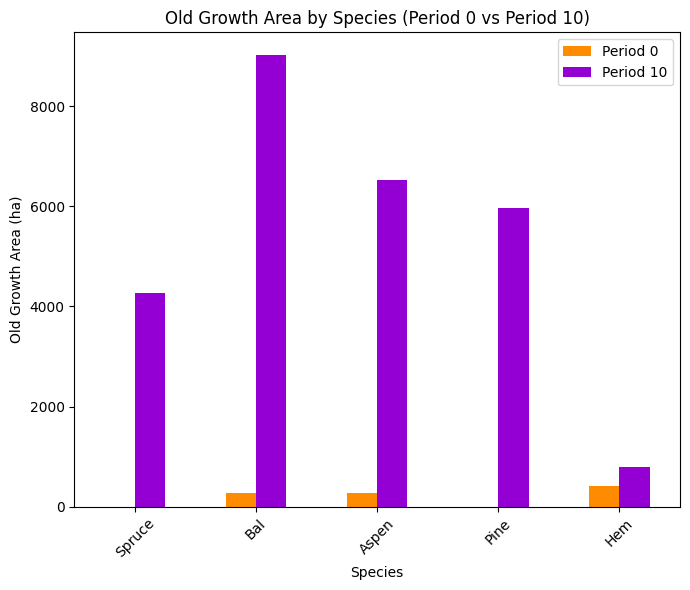

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9003

Diversity has **decreased** by 4.53% from time 0 to time 10.


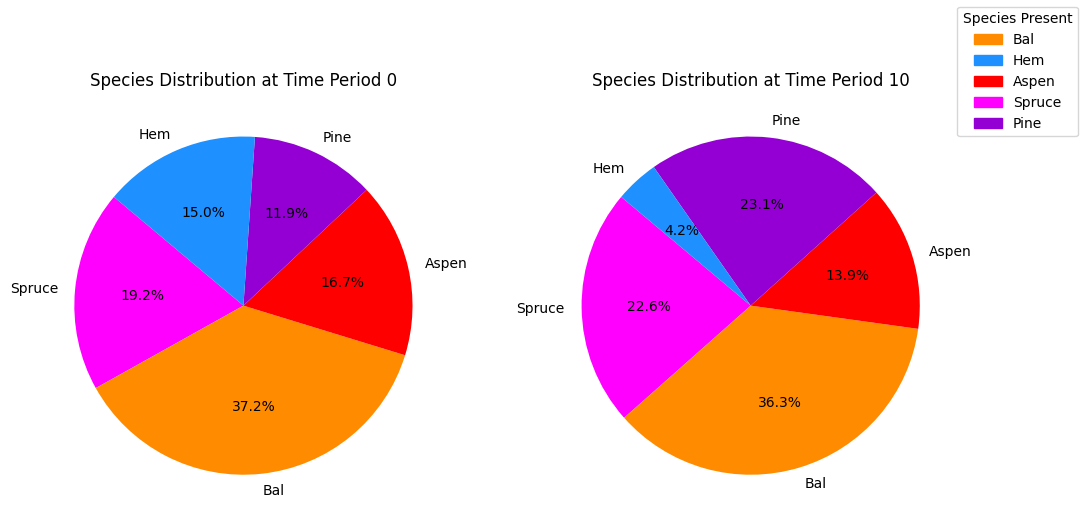

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_species_pie.pdf


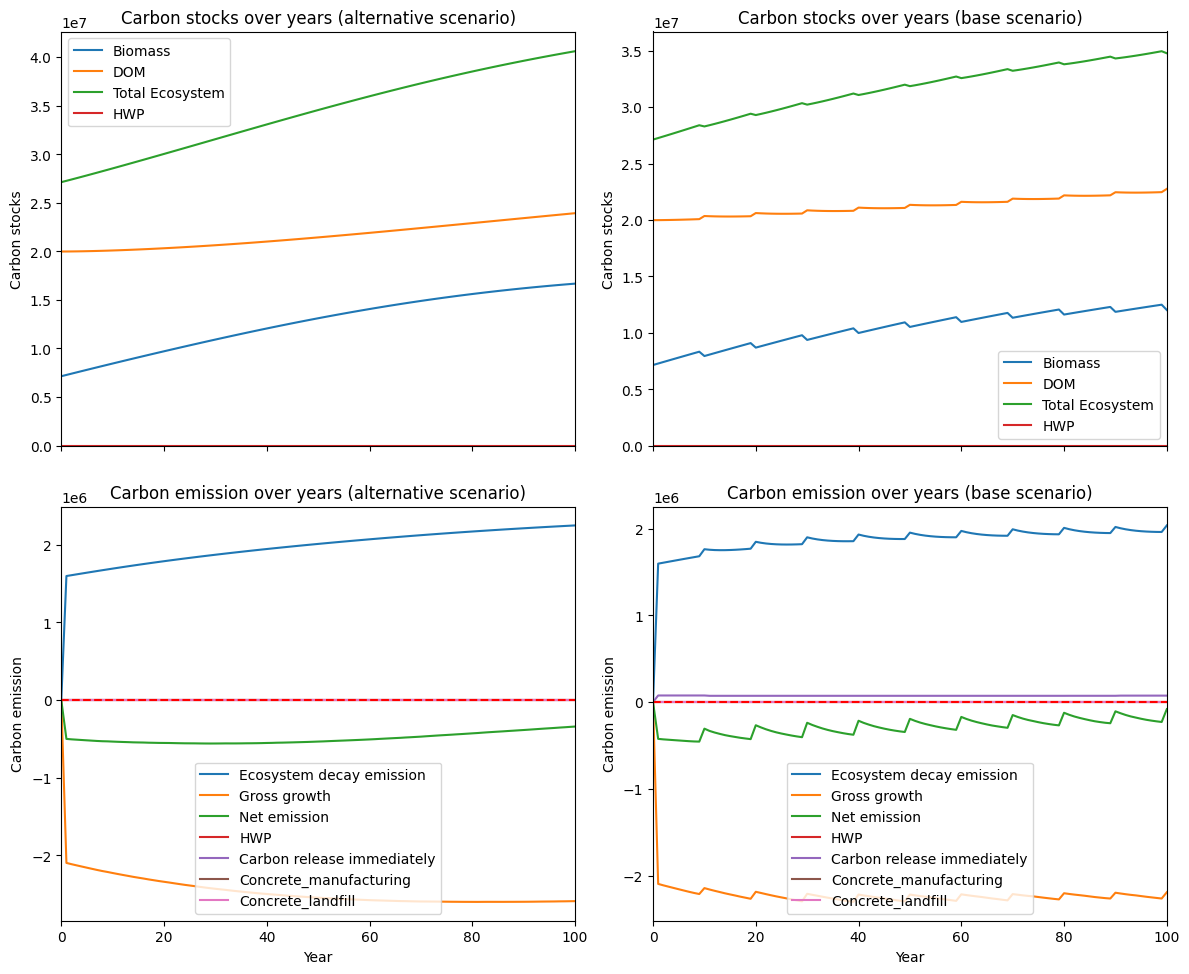

---------------------------------------------------------------------------------------
Net emission difference -3550581.138939184
Net emission base scenario -12873402.697854219
Net emission alternative scenario -9322821.558915036
dollar_per_ton is:  2.816440354039543
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  3780.327790  3780.327790
Bal     0.0  6942.234465  6942.234465
Aspen   0.0  6666.509832  6666.509832
Pine    0.0  1663.876682  1663.876682
Hem     0.0  3128.426675  3128.426675

Overall, the old growth area has **increased** by 22181.38 hectares in the alternative scenario compared to the base scenario.


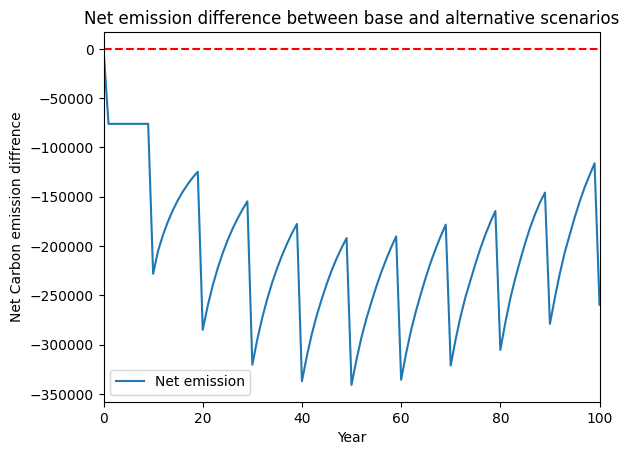

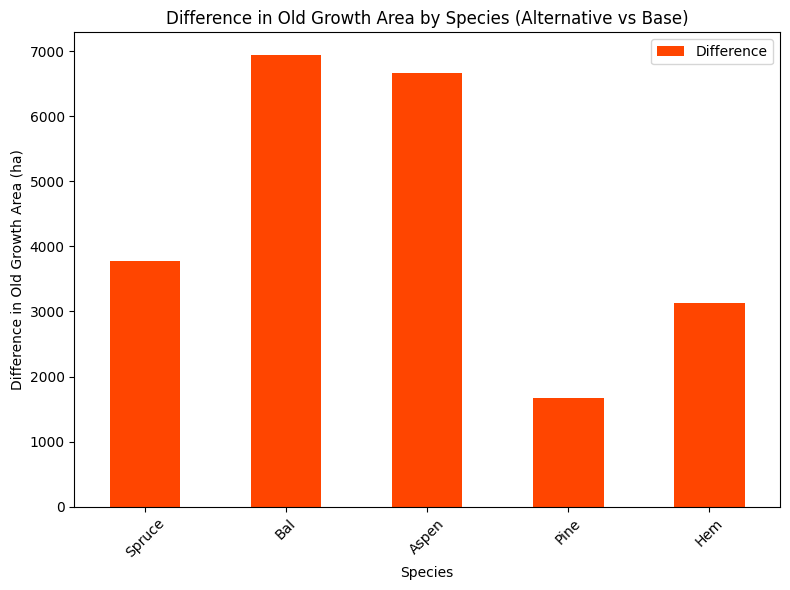

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_age_difference.pdf


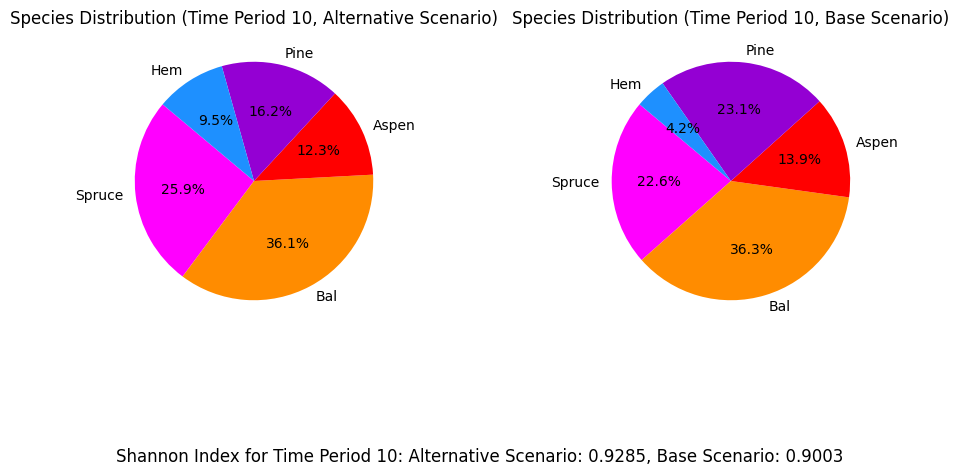

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_ha_bau_gldbr...
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x17162bc7
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.19s
Presolved: 1911 rows, 32225 col

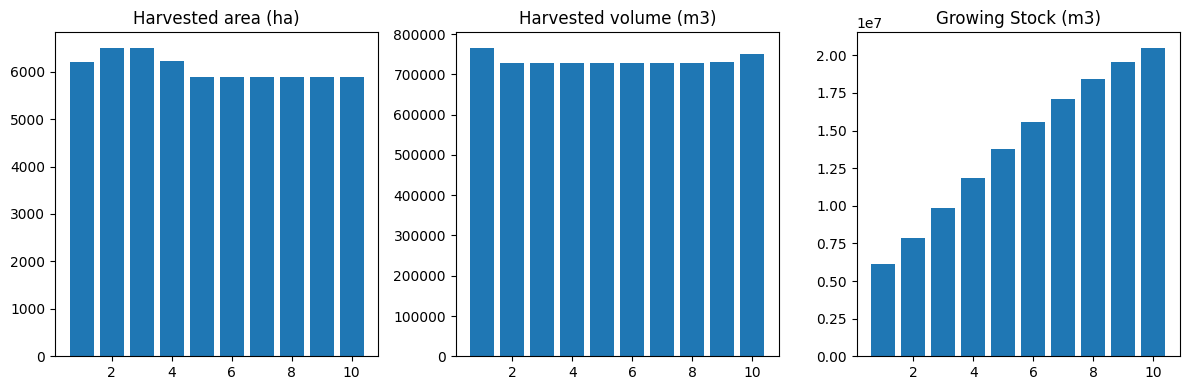

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7759
The economic indicator (the provincial government revenues) is:  264628
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


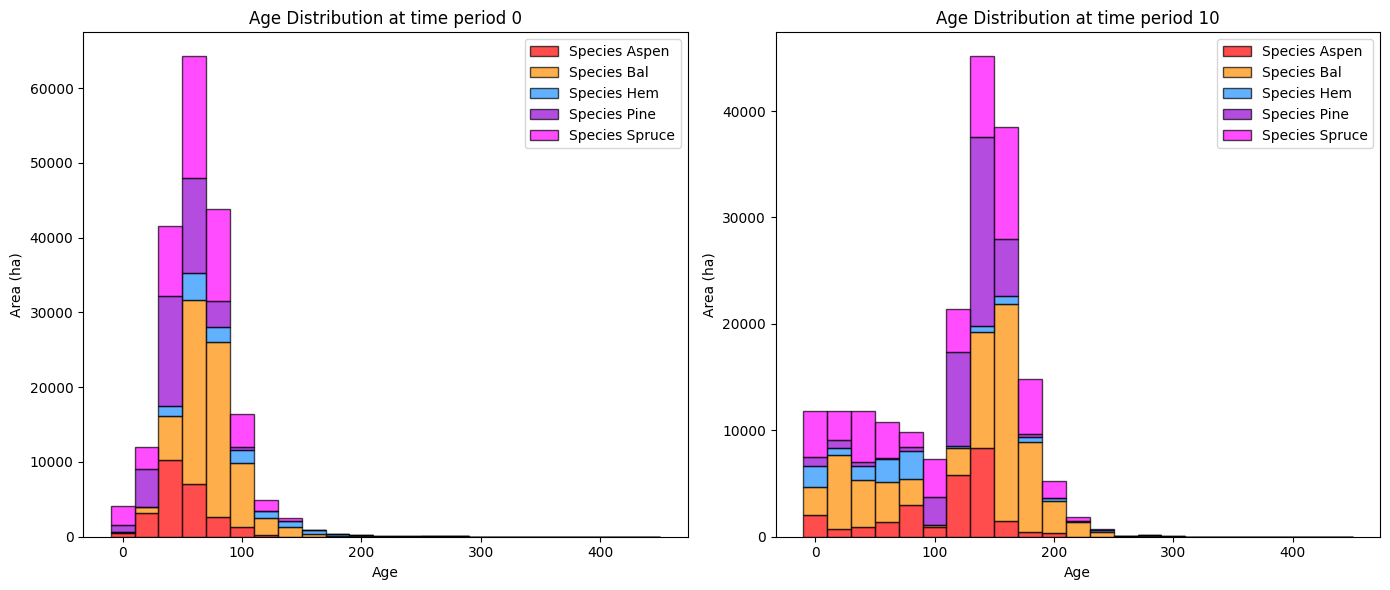

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4259.936249  4257.227716
Bal     278.565372  9020.773269  8742.207898
Aspen   273.490478  6525.108441  6251.617963
Pine      0.000000  5968.010518  5968.010518
Hem     419.699331   801.166864   381.467533

Overall diversity has **increased** by 25600.53 hectares from time period 0 to time period 10.


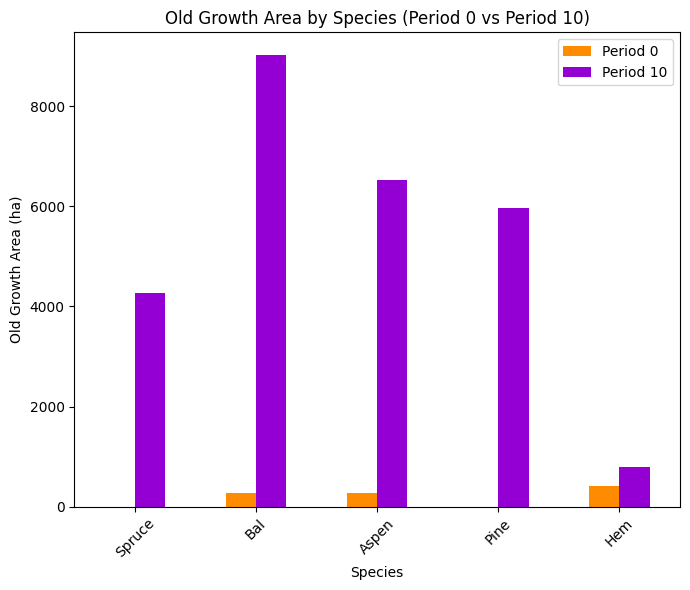

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9003

Diversity has **decreased** by 4.53% from time 0 to time 10.


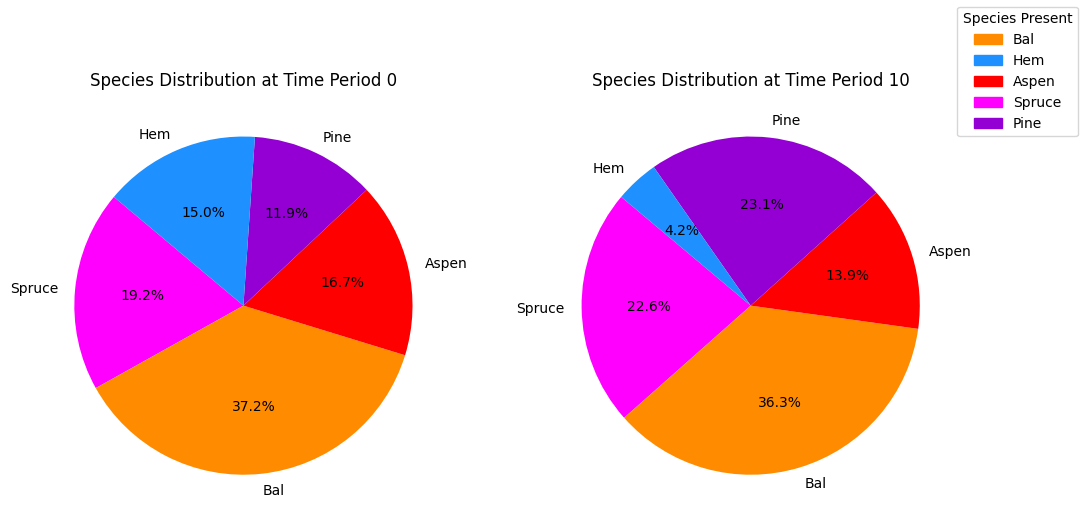

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x17162bc7
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.20s
Presolved: 1911 rows, 32225 columns, 407291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.

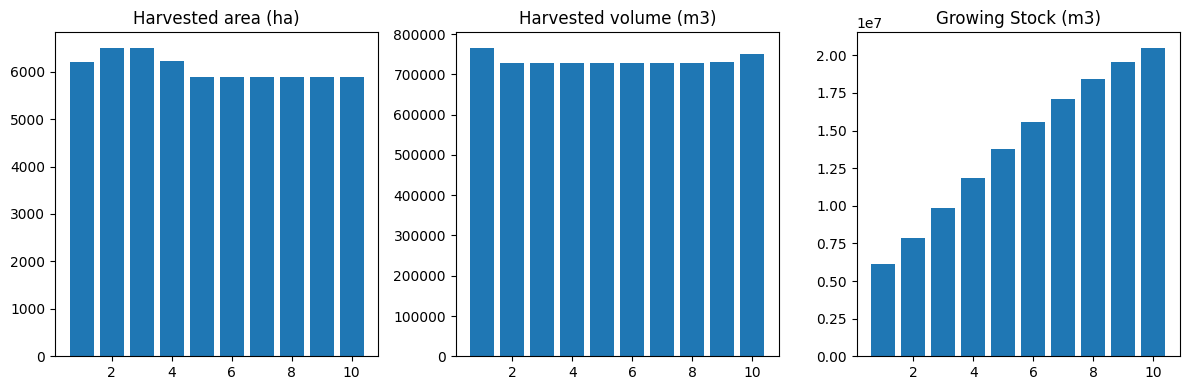

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7759
The economic indicator (the provincial government revenues) is:  264628
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


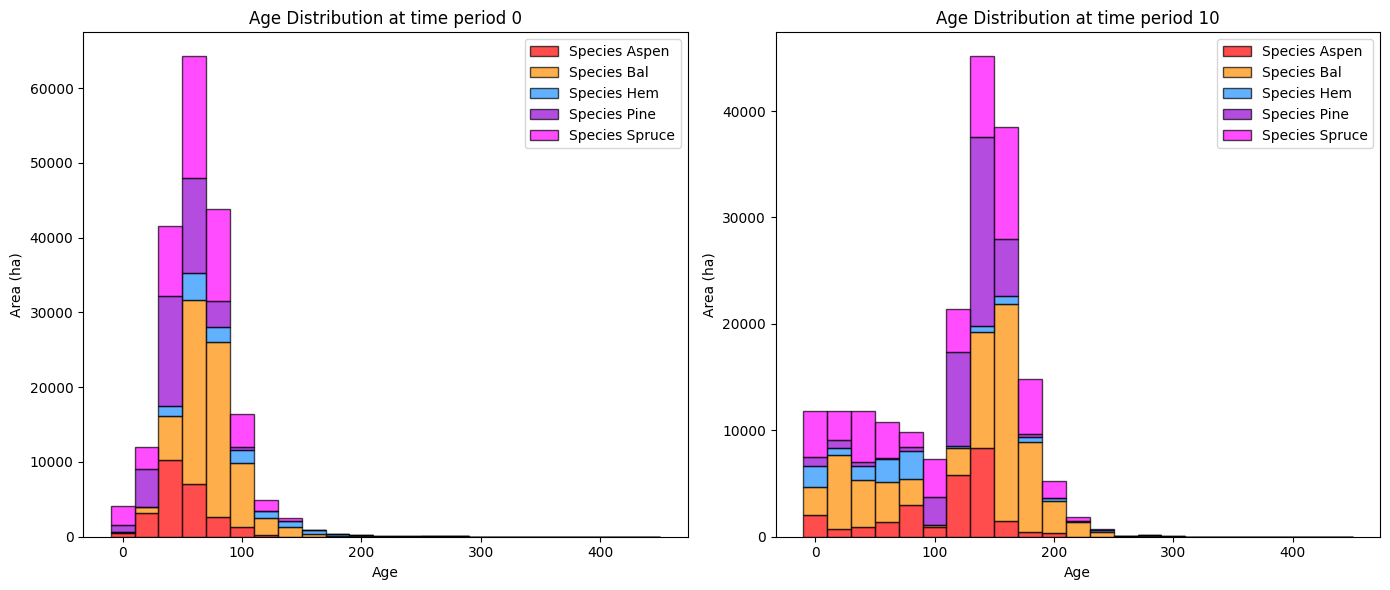

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4259.936249  4257.227716
Bal     278.565372  9020.773269  8742.207898
Aspen   273.490478  6525.108441  6251.617963
Pine      0.000000  5968.010518  5968.010518
Hem     419.699331   801.166864   381.467533

Overall diversity has **increased** by 25600.53 hectares from time period 0 to time period 10.


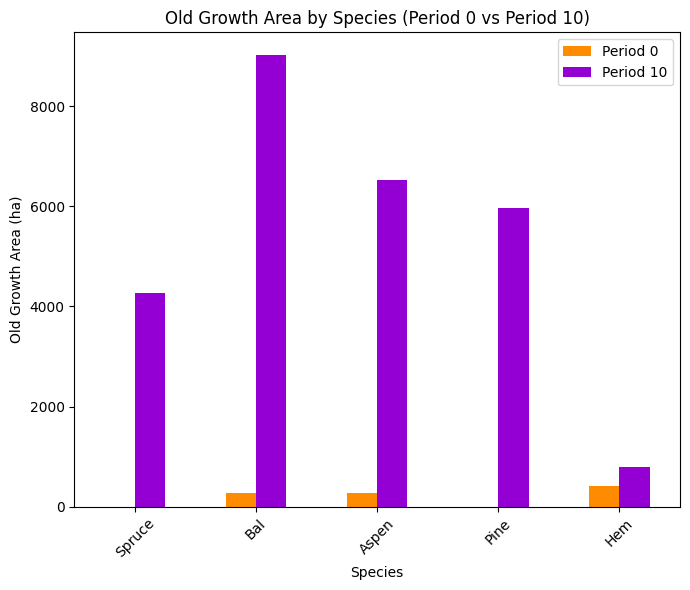

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9003

Diversity has **decreased** by 4.53% from time 0 to time 10.


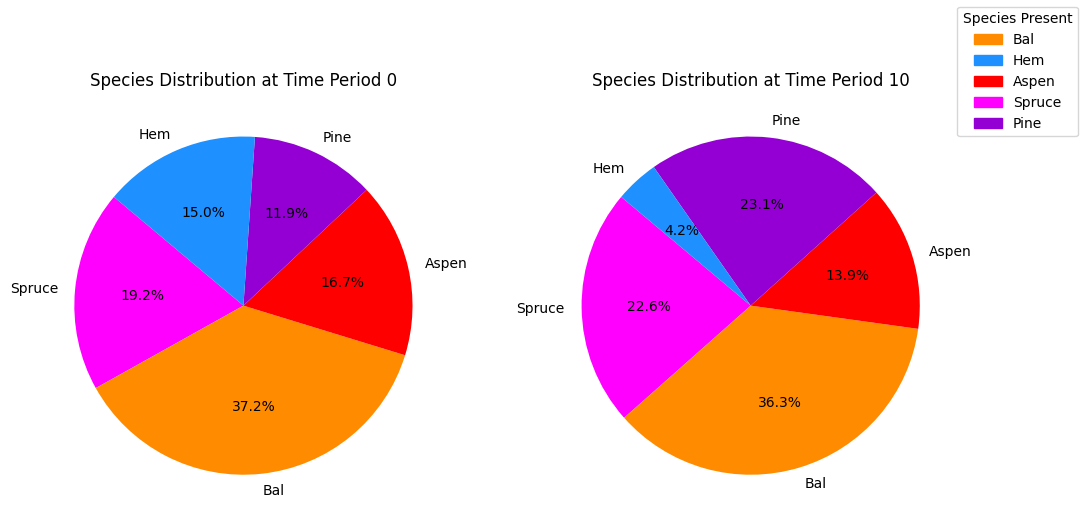

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_species_pie.pdf


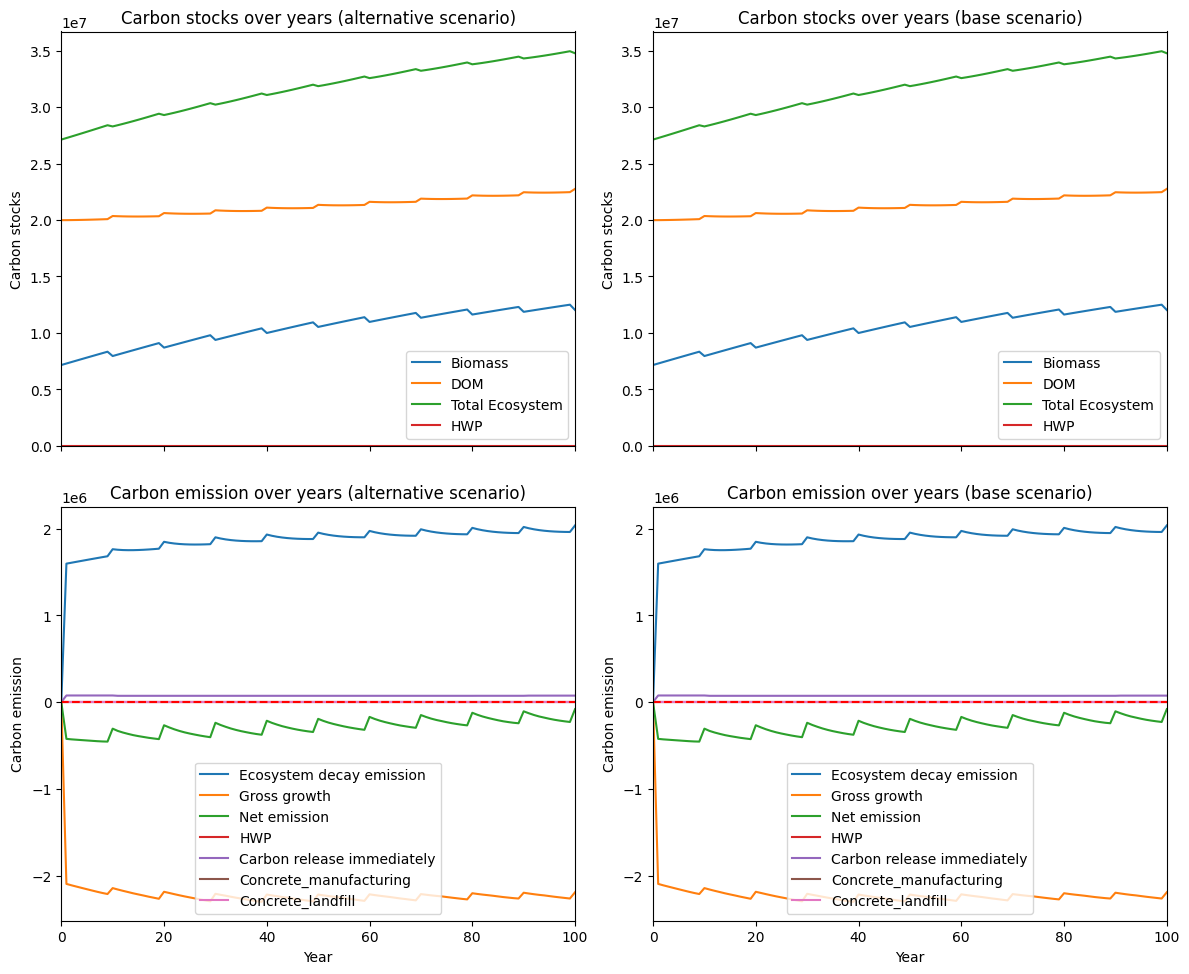

---------------------------------------------------------------------------------------
Net emission difference 0.0
Net emission base scenario -9322821.558915036
Net emission alternative scenario -9322821.558915036
dollar_per_ton is:  inf
Comparison of Old Growth Areas (Alternative - Base)
          0   10  Difference
Spruce  0.0  0.0         0.0
Bal     0.0  0.0         0.0
Aspen   0.0  0.0         0.0
Pine    0.0  0.0         0.0
Hem     0.0  0.0         0.0

Overall, the old growth area has **increased** by 0.00 hectares in the alternative scenario compared to the base scenario.


/media/data/project/eghasemi/nbds_mining/util_opt.py:1211: RuntimeWarning: divide by zero encountered in scalar divide
  dollar_per_ton = abs(budget_input / dif_scenario.iloc[:25]['Net emission'].sum())


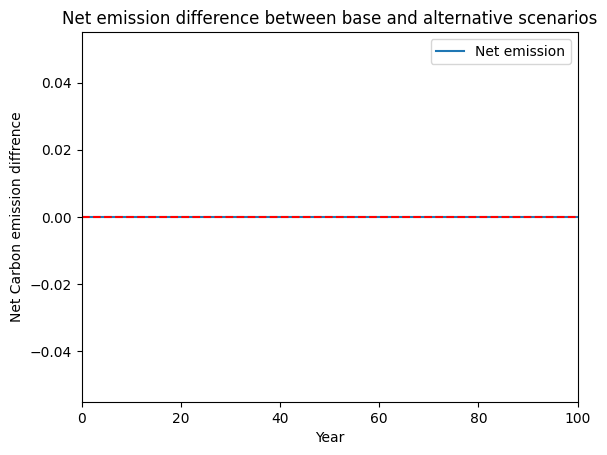

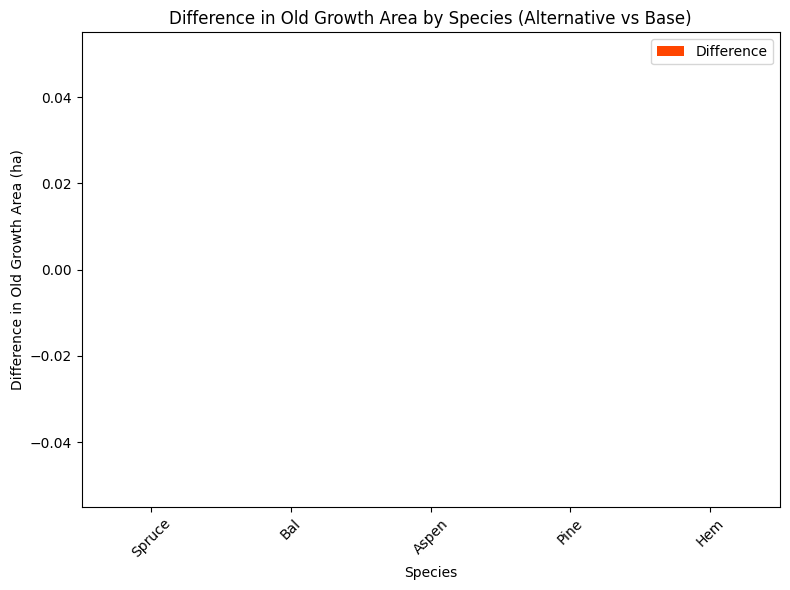

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_age_difference.pdf


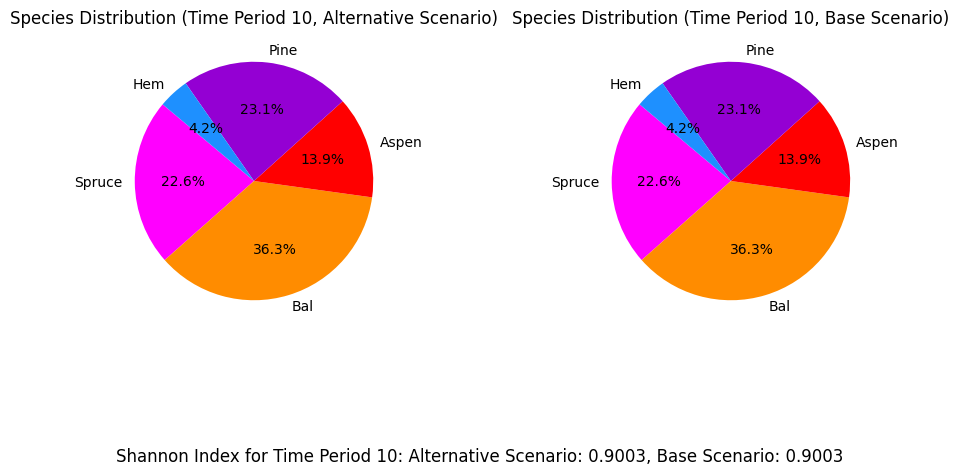

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_ha_gldbr_AAC_90%...
running the scenario for the Golden Bear mining site (90%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x8f70c844
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.24s
Presolved: 1911 rows, 32226 

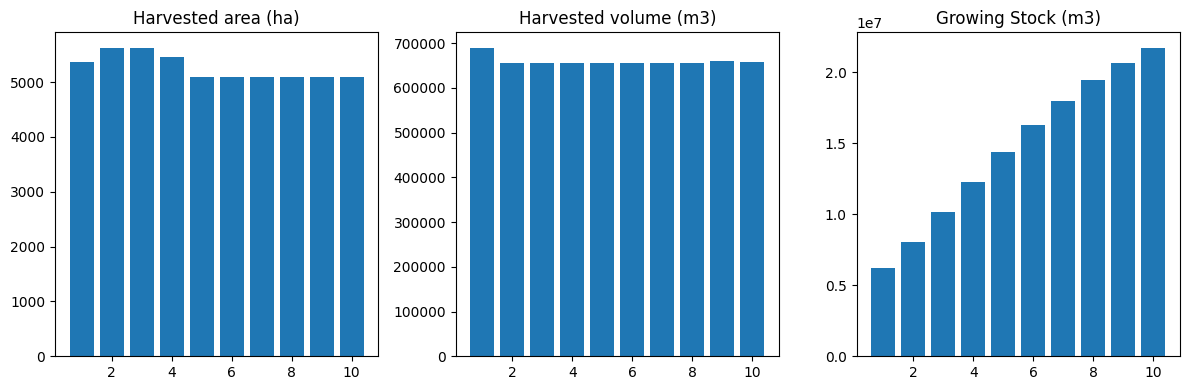

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_90%_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  6968
The economic indicator (the provincial government revenues) is:  237650
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


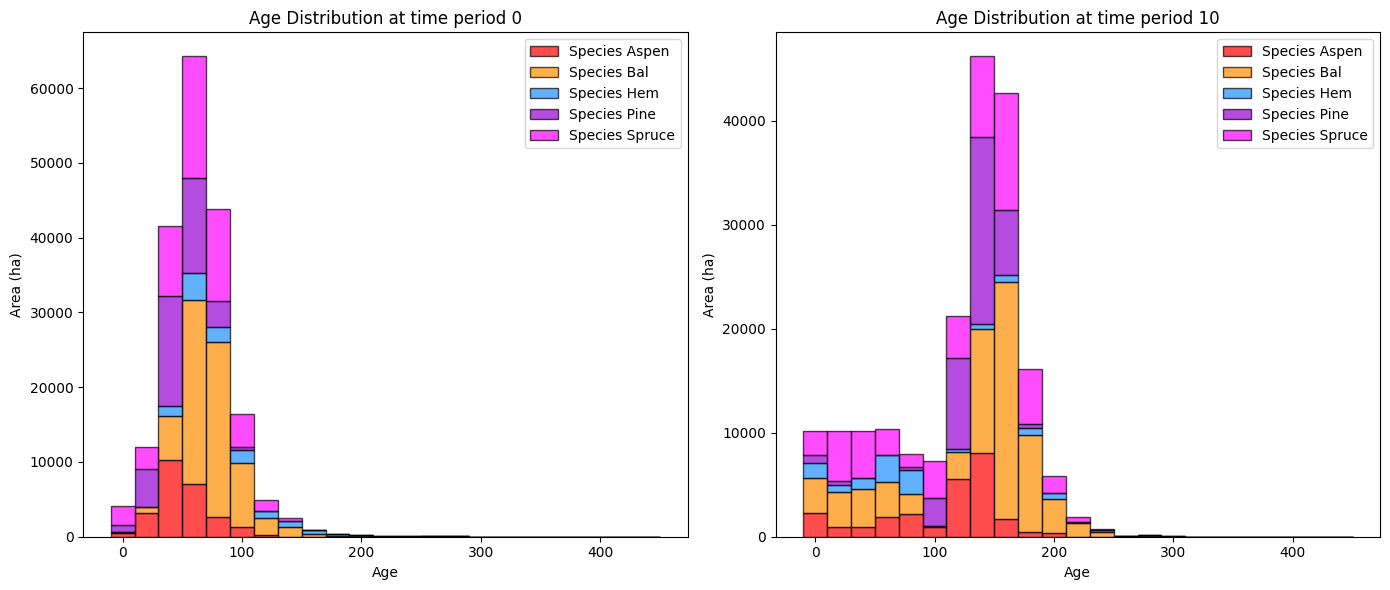

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_90%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4450.840228  4448.131695
Bal     278.565372  9918.328413  9639.763041
Aspen   273.490478  6631.044913  6357.554435
Pine      0.000000  6641.205351  6641.205351
Hem     419.699331  1026.165012   606.465681

Overall diversity has **increased** by 27693.12 hectares from time period 0 to time period 10.


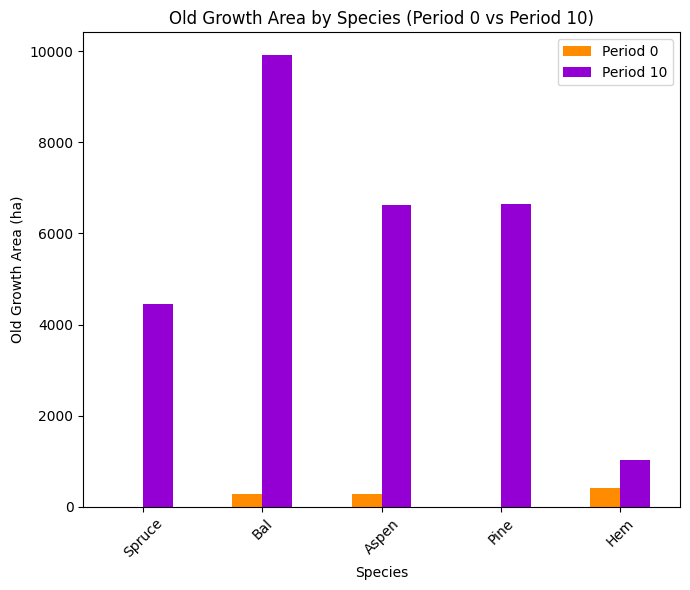

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_90%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8939

Diversity has **decreased** by 5.16% from time 0 to time 10.


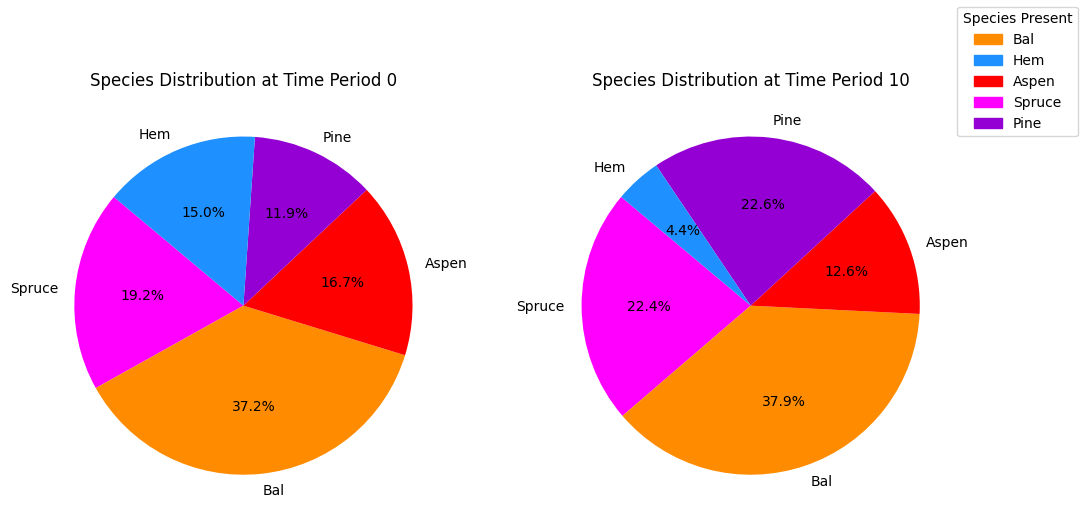

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_90%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x17162bc7
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.22s
Presolved: 1911 rows, 32225 columns, 407291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

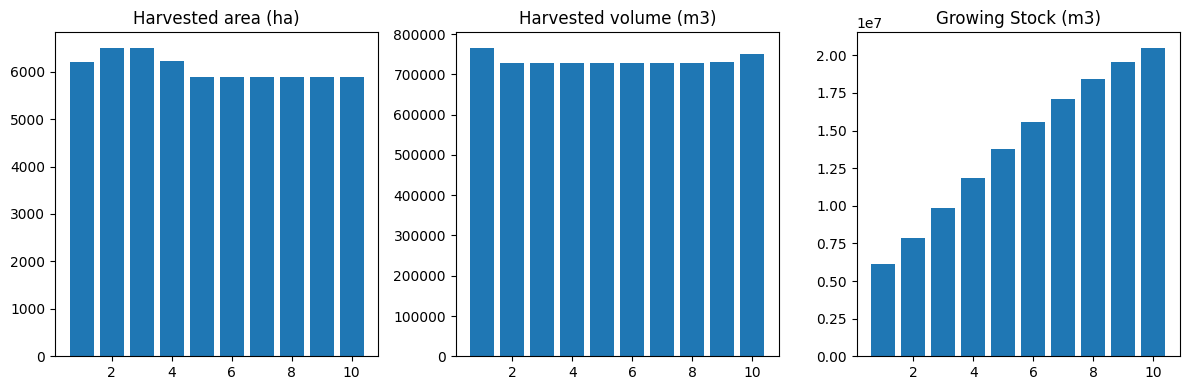

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7759
The economic indicator (the provincial government revenues) is:  264628
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


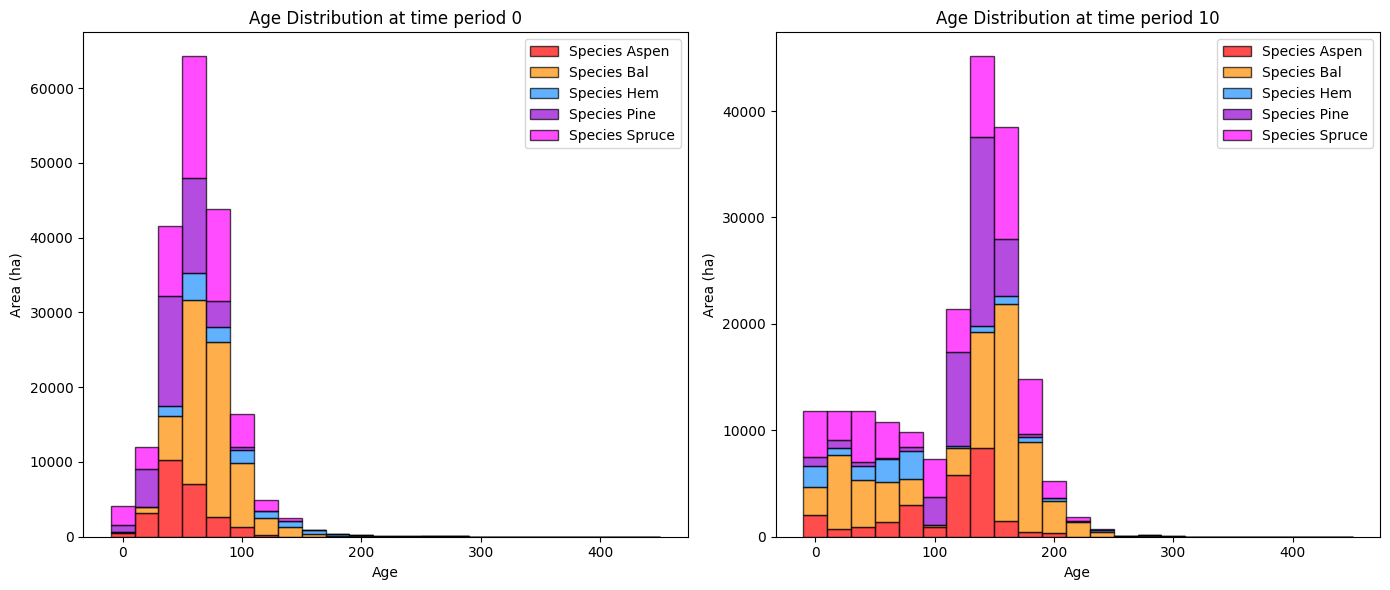

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4259.936249  4257.227716
Bal     278.565372  9020.773269  8742.207898
Aspen   273.490478  6525.108441  6251.617963
Pine      0.000000  5968.010518  5968.010518
Hem     419.699331   801.166864   381.467533

Overall diversity has **increased** by 25600.53 hectares from time period 0 to time period 10.


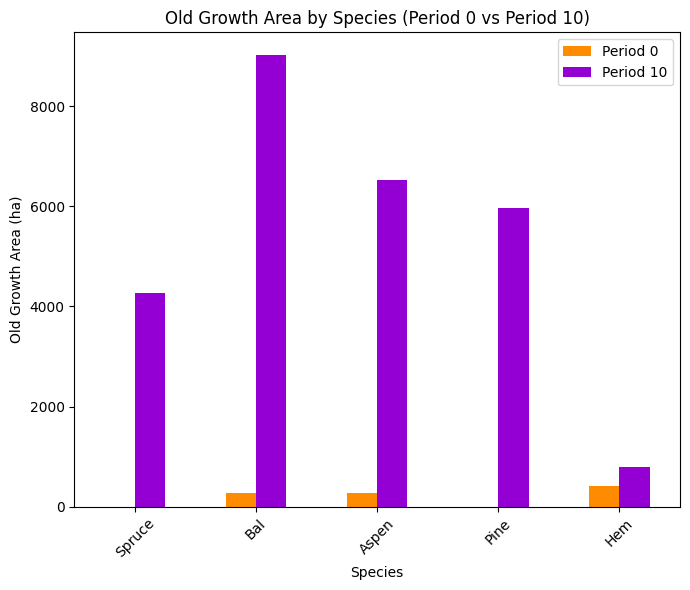

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9003

Diversity has **decreased** by 4.53% from time 0 to time 10.


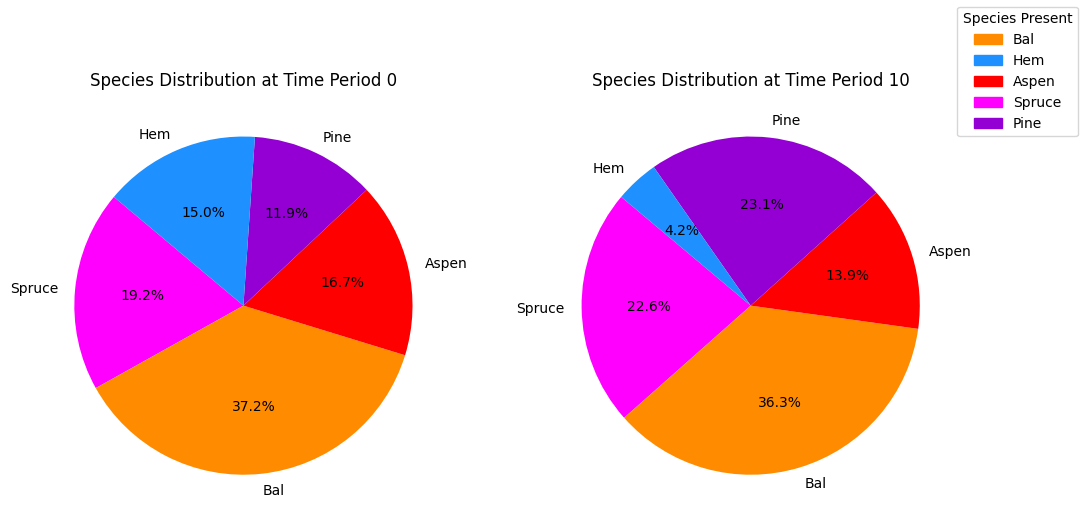

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_species_pie.pdf


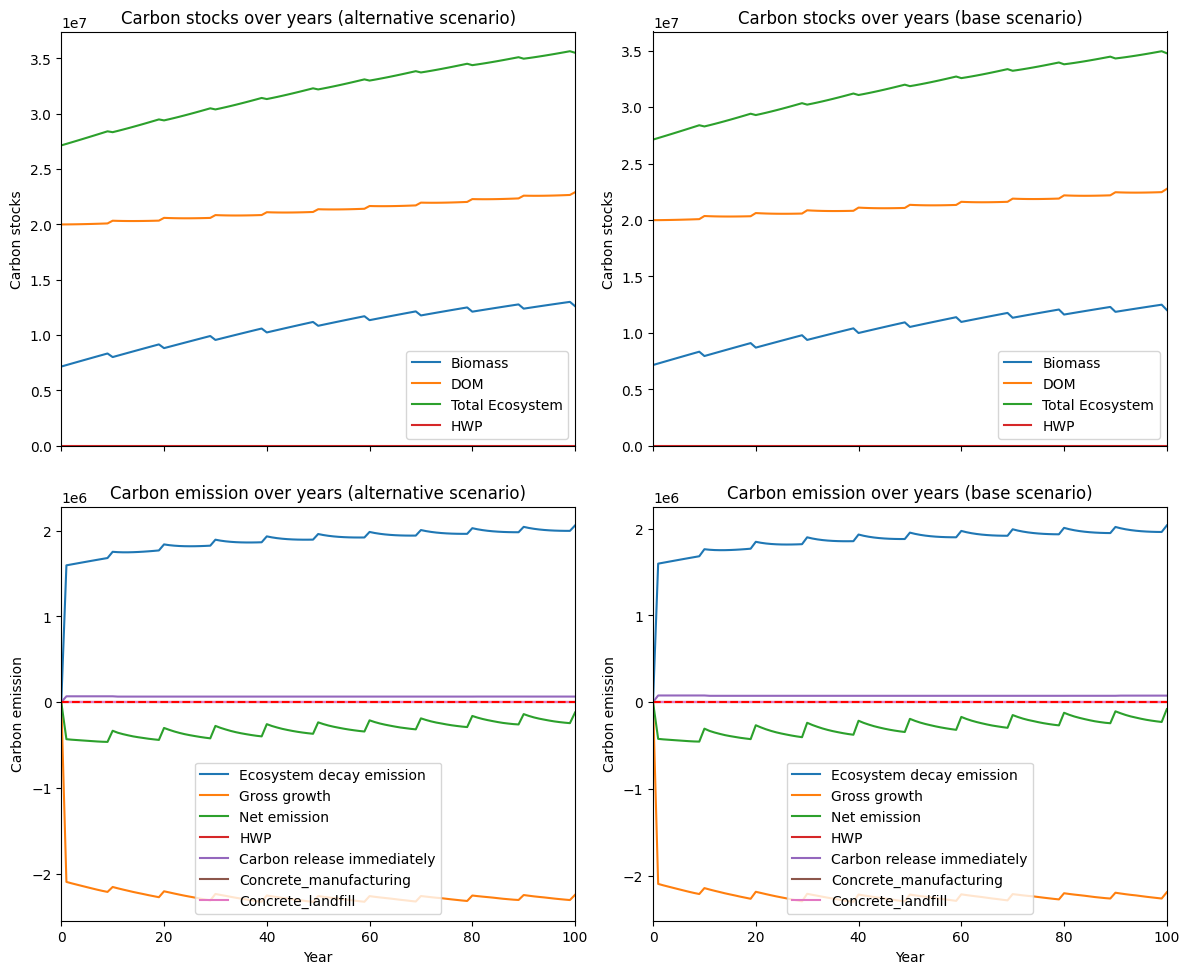

---------------------------------------------------------------------------------------
Net emission difference -394275.07382638904
Net emission base scenario -9717096.632741425
Net emission alternative scenario -9322821.558915036
dollar_per_ton is:  25.363003303635917
Comparison of Old Growth Areas (Alternative - Base)
          0          10  Difference
Spruce  0.0  190.903979  190.903979
Bal     0.0  897.555143  897.555143
Aspen   0.0  105.936472  105.936472
Pine    0.0  673.194833  673.194833
Hem     0.0  224.998148  224.998148

Overall, the old growth area has **increased** by 2092.59 hectares in the alternative scenario compared to the base scenario.


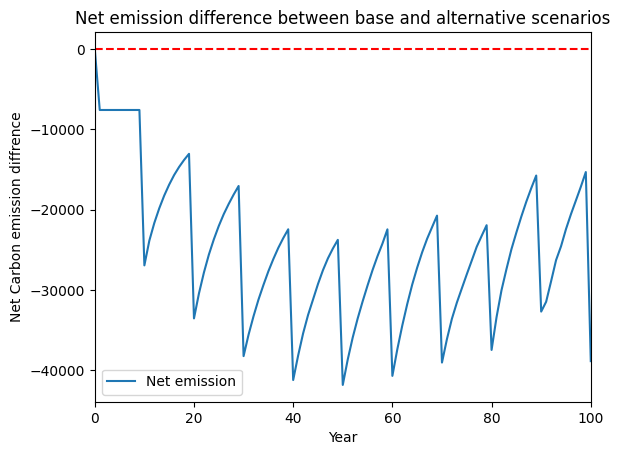

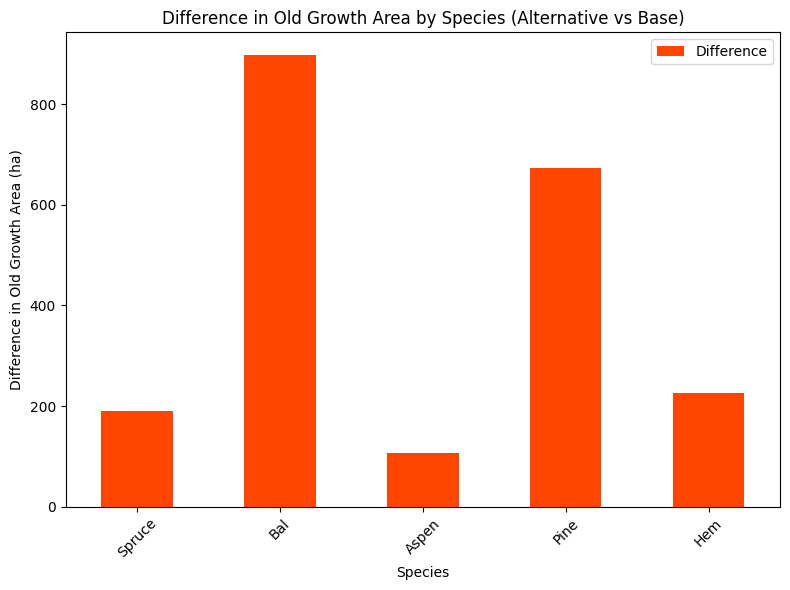

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_age_difference.pdf


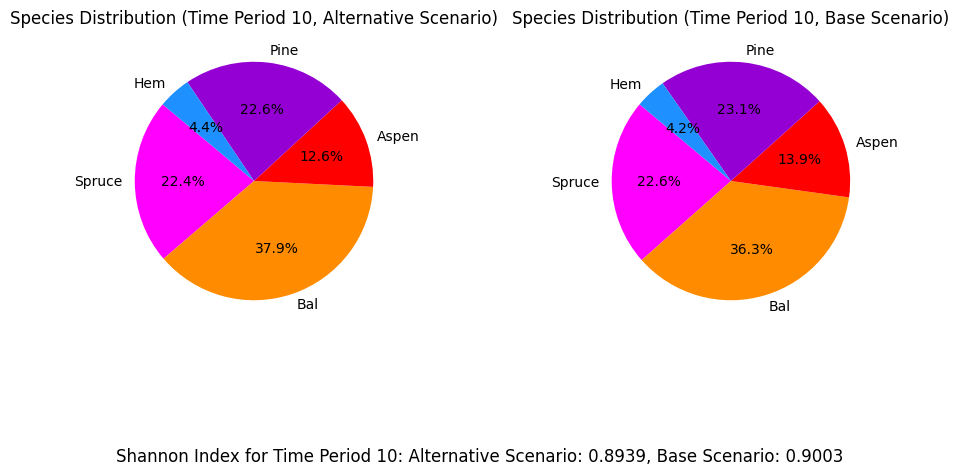

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_ha_gldbr_AAC_80%...
running the scenario for the Golden Bear mining site (80%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x9ab17877
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.20s
Presolved: 1911 rows, 32226 

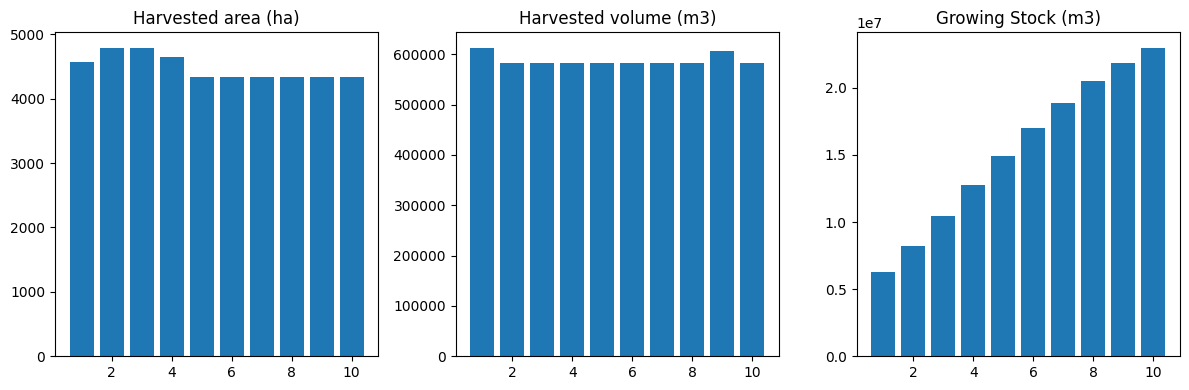

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_80%_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  6213
The economic indicator (the provincial government revenues) is:  211883
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


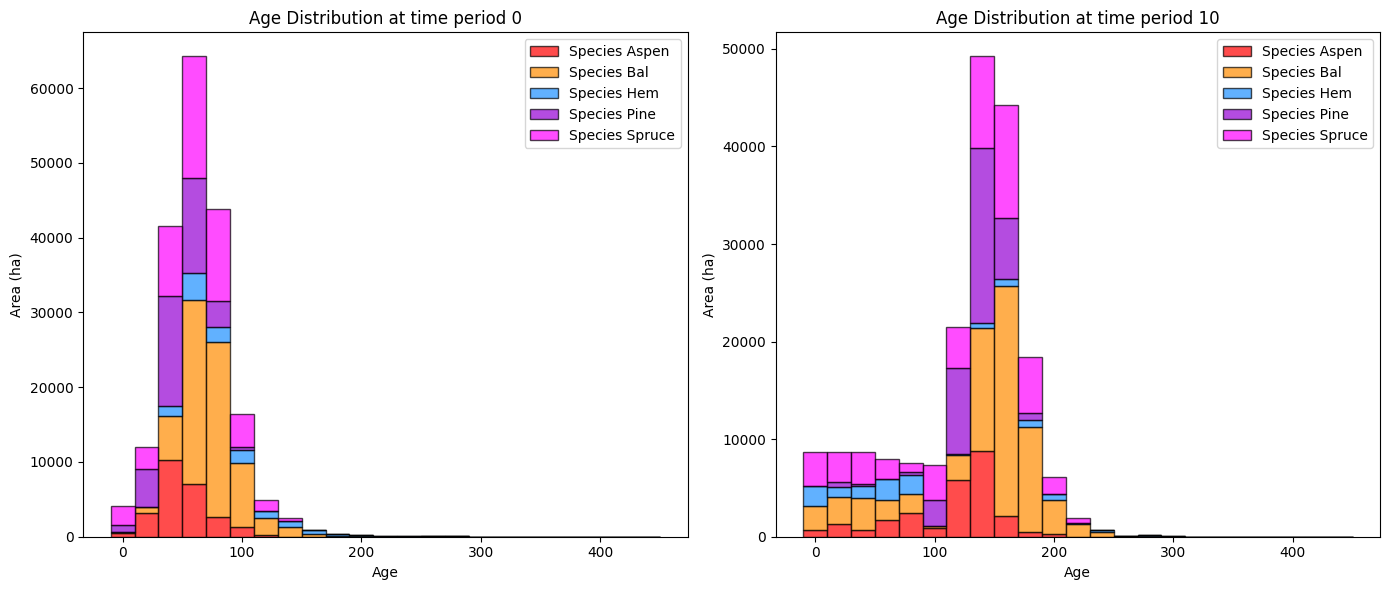

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_80%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   4915.394358   4912.685825
Bal     278.565372  10562.350438  10283.785066
Aspen   273.490478   7567.810555   7294.320077
Pine      0.000000   6842.645737   6842.645737
Hem     419.699331   1066.892542    647.193212

Overall diversity has **increased** by 29980.63 hectares from time period 0 to time period 10.


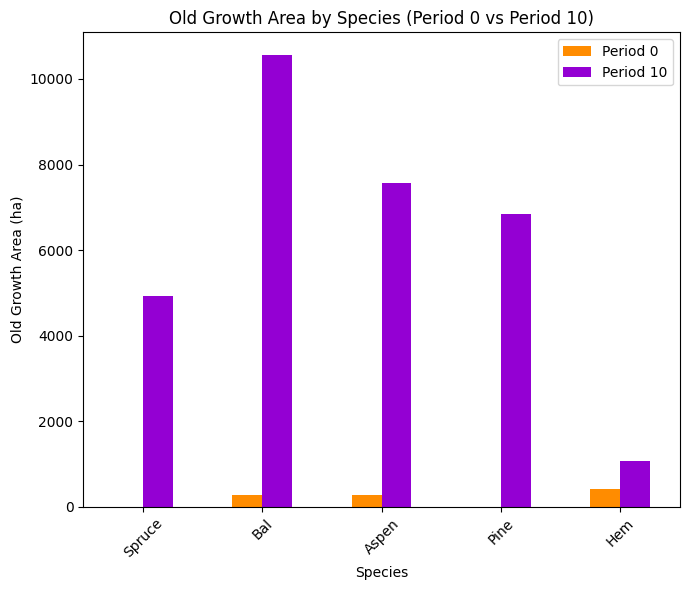

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_80%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8886

Diversity has **decreased** by 5.70% from time 0 to time 10.


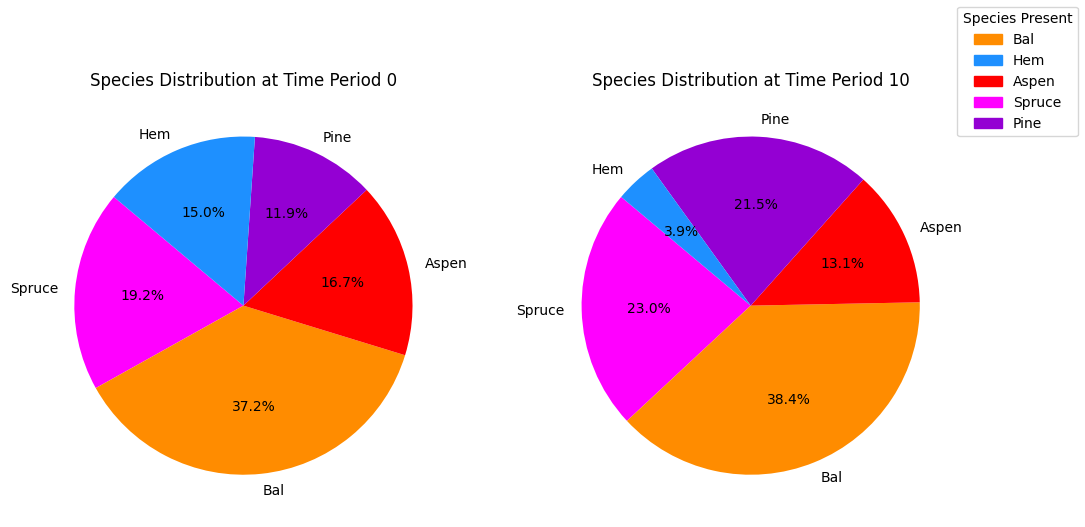

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_80%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x17162bc7
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.22s
Presolved: 1911 rows, 32225 columns, 407291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

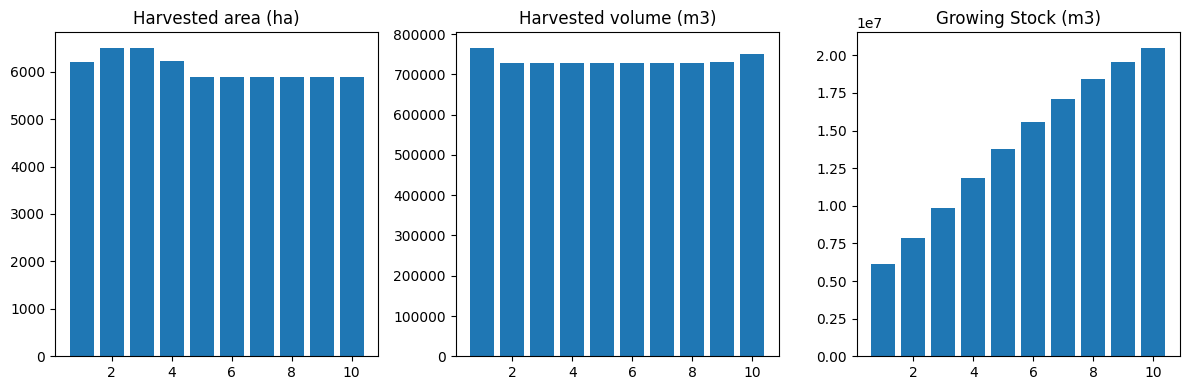

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7759
The economic indicator (the provincial government revenues) is:  264628
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


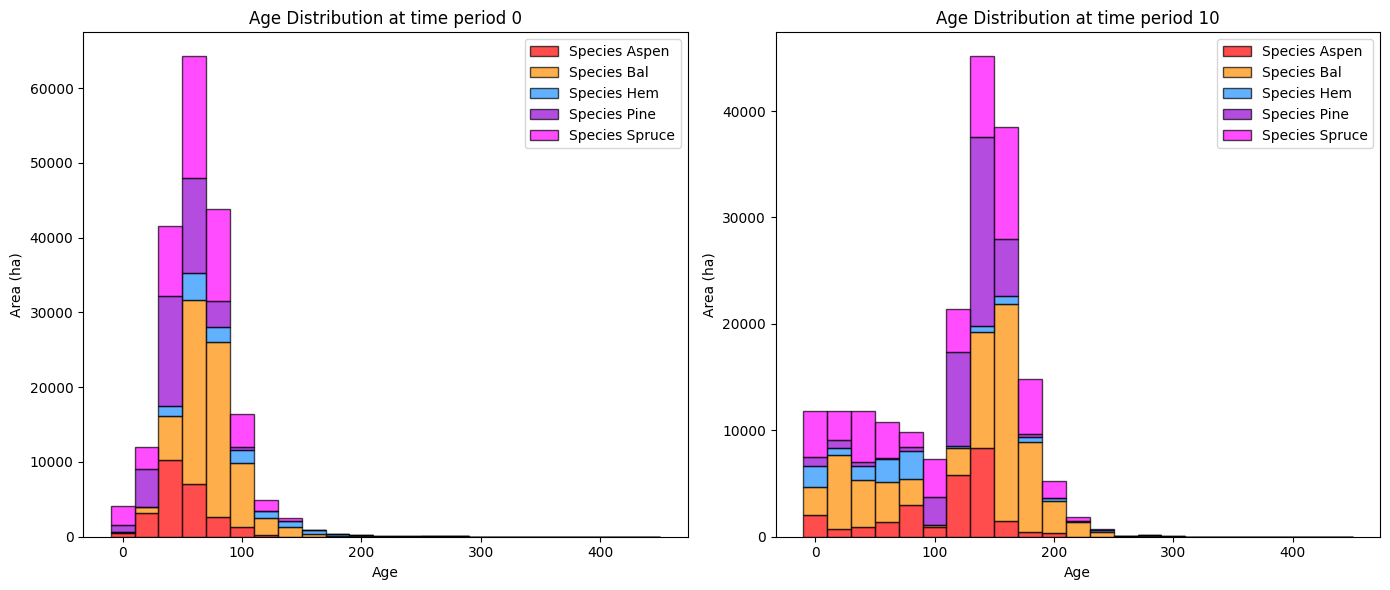

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4259.936249  4257.227716
Bal     278.565372  9020.773269  8742.207898
Aspen   273.490478  6525.108441  6251.617963
Pine      0.000000  5968.010518  5968.010518
Hem     419.699331   801.166864   381.467533

Overall diversity has **increased** by 25600.53 hectares from time period 0 to time period 10.


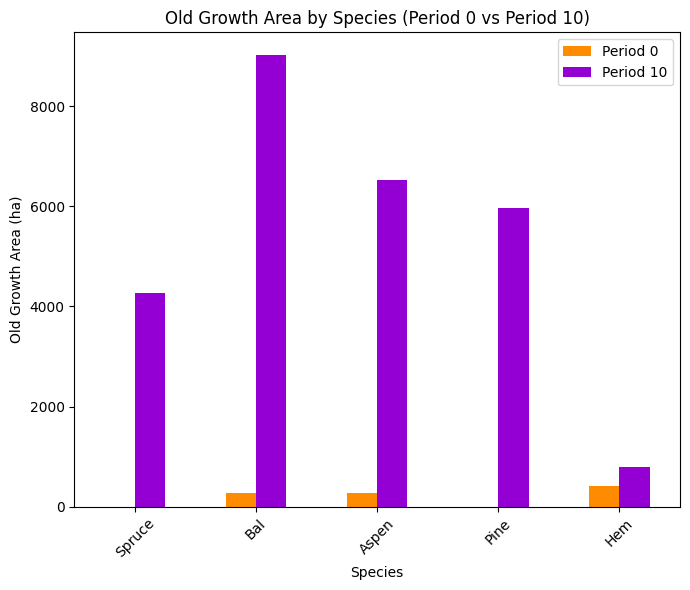

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9003

Diversity has **decreased** by 4.53% from time 0 to time 10.


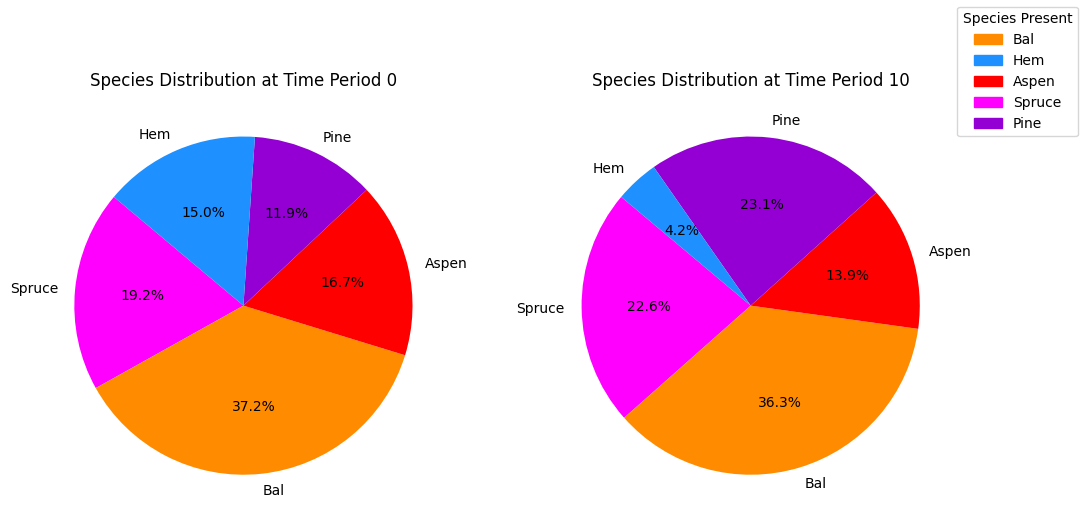

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_species_pie.pdf


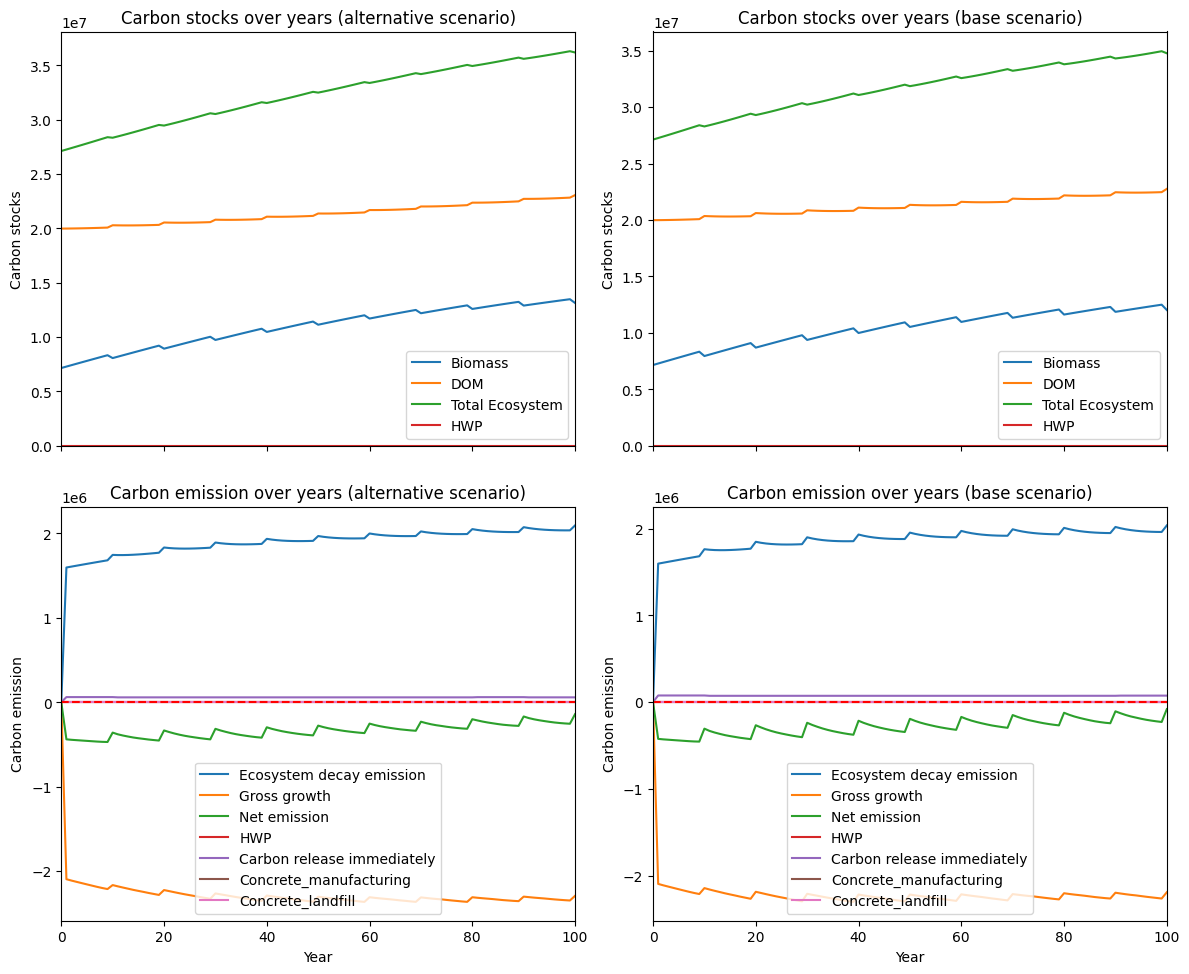

---------------------------------------------------------------------------------------
Net emission difference -790587.3527725872
Net emission base scenario -10113408.911687624
Net emission alternative scenario -9322821.558915036
dollar_per_ton is:  12.6488236434975
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0   655.458109   655.458109
Bal     0.0  1541.577169  1541.577169
Aspen   0.0  1042.702114  1042.702114
Pine    0.0   874.635218   874.635218
Hem     0.0   265.725679   265.725679

Overall, the old growth area has **increased** by 4380.10 hectares in the alternative scenario compared to the base scenario.


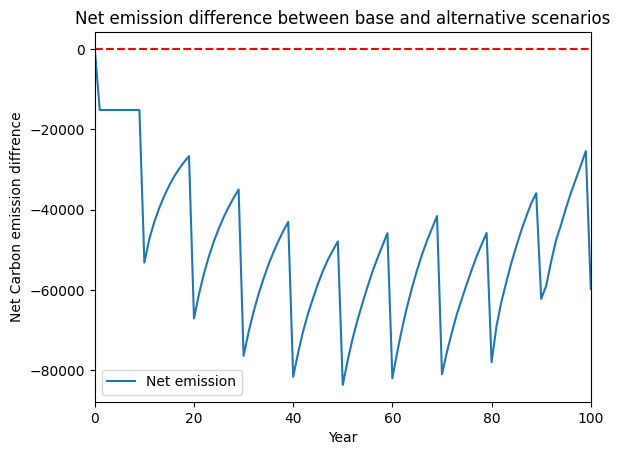

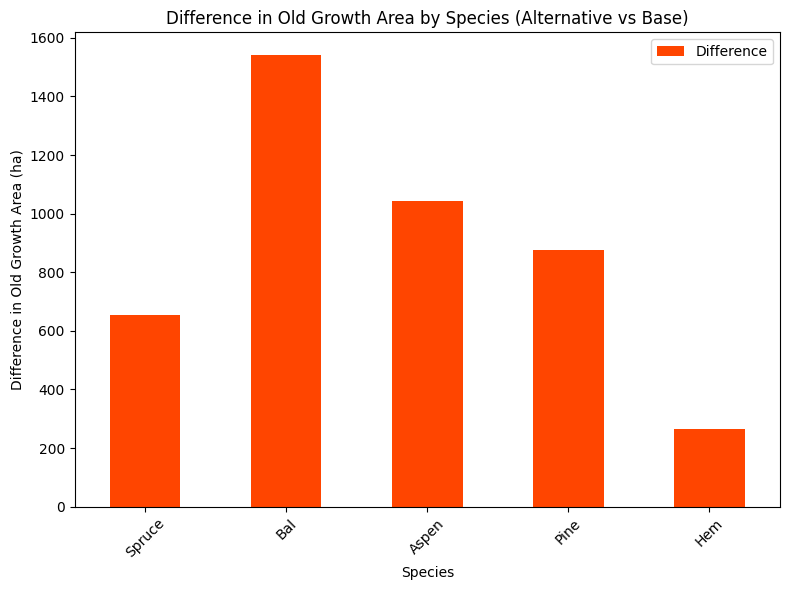

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_age_difference.pdf


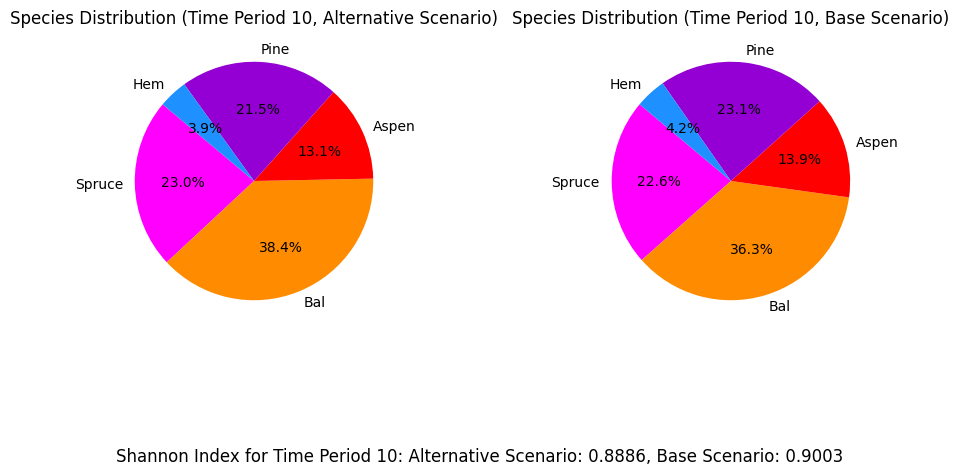

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_ha_gldbr_AAC_70%...
running the scenario for the Golden Bear mining site (70%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xdc12fc48
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.20s
Presolved: 1911 rows, 32226 

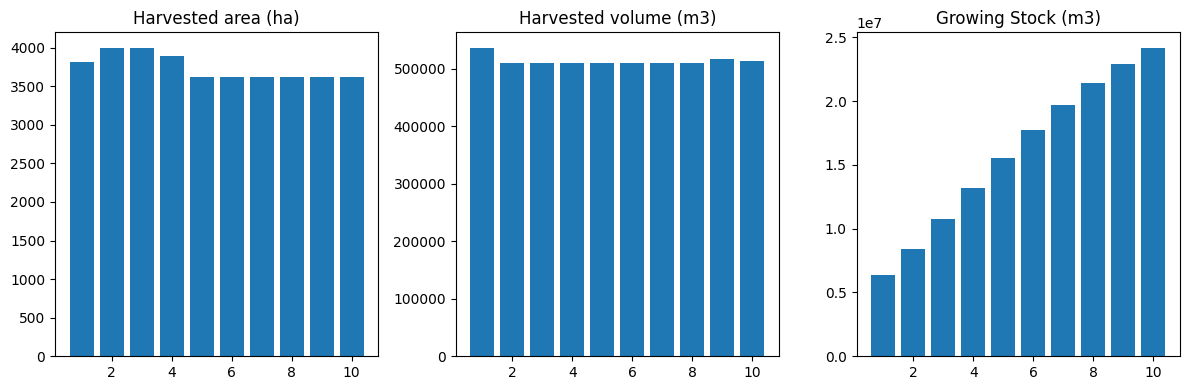

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_70%_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  5426
The economic indicator (the provincial government revenues) is:  185047
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


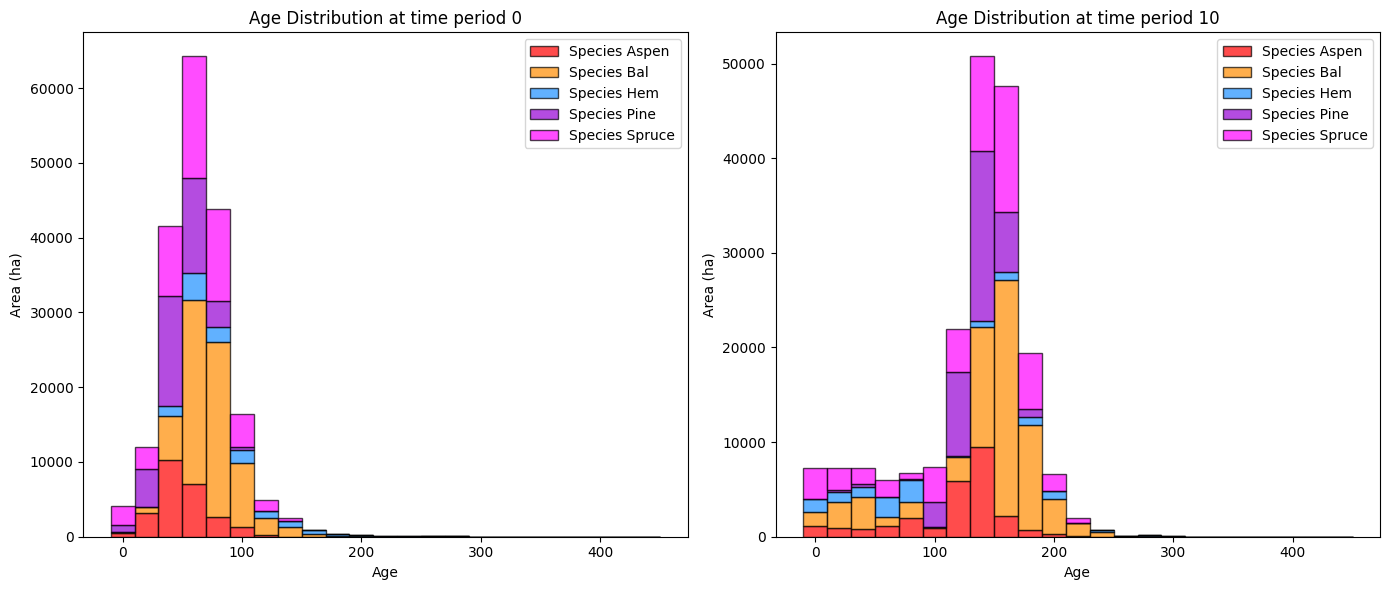

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_70%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5341.051597   5338.343063
Bal     278.565372  11508.976439  11230.411067
Aspen   273.490478   8331.468835   8057.978357
Pine      0.000000   7105.753142   7105.753142
Hem     419.699331   1143.808471    724.109140

Overall diversity has **increased** by 32456.59 hectares from time period 0 to time period 10.


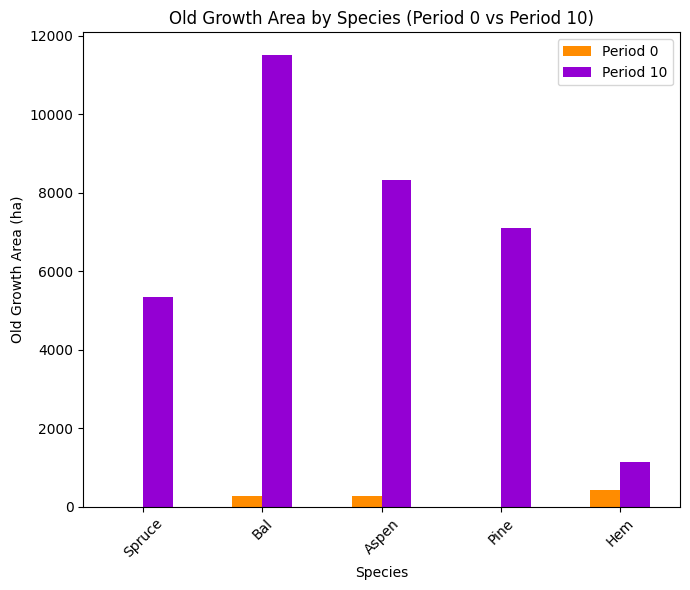

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_70%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8883

Diversity has **decreased** by 5.72% from time 0 to time 10.


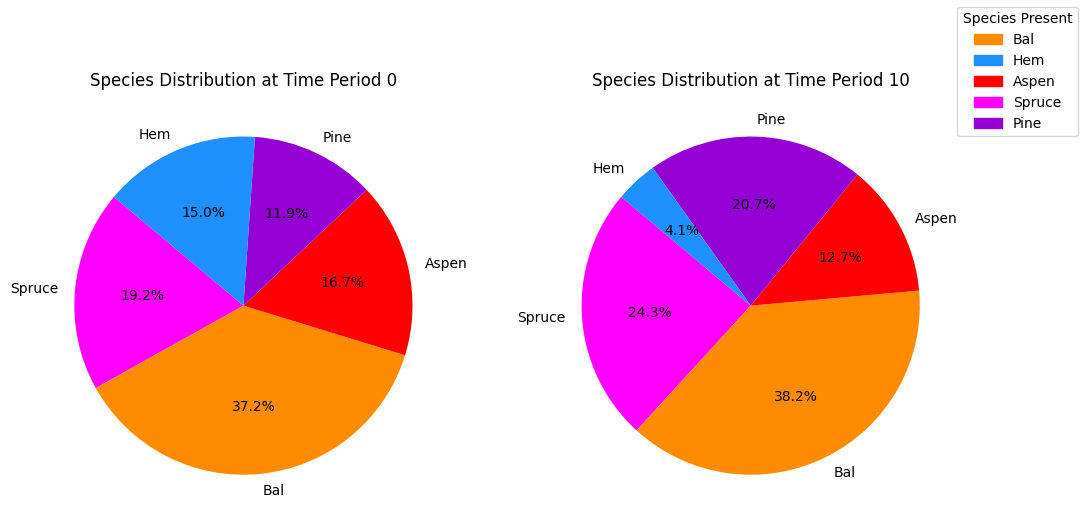

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_70%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x17162bc7
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.24s
Presolved: 1911 rows, 32225 columns, 407291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

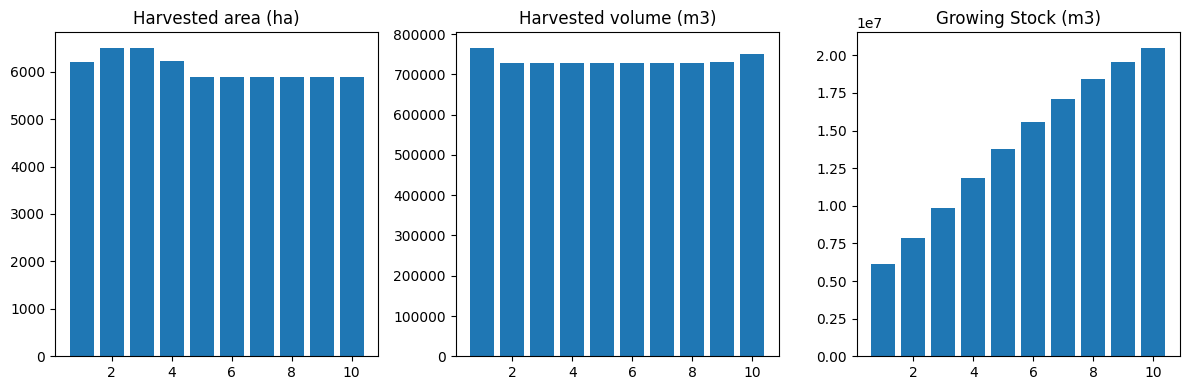

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7759
The economic indicator (the provincial government revenues) is:  264628
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


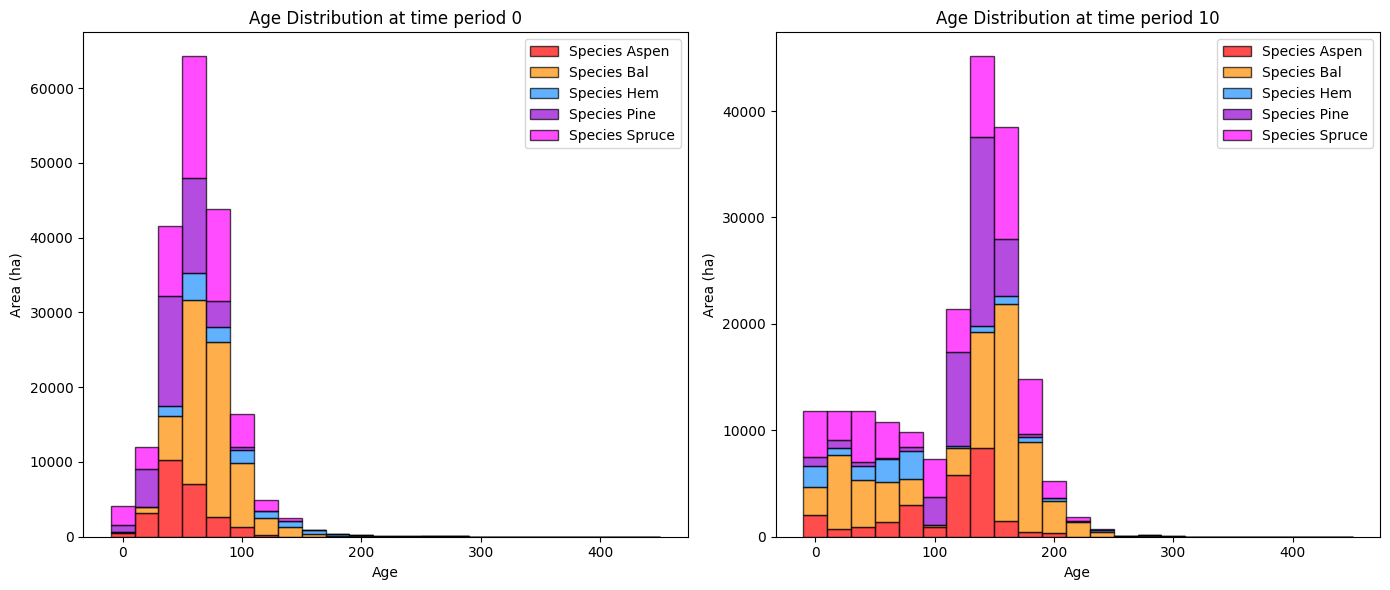

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4259.936249  4257.227716
Bal     278.565372  9020.773269  8742.207898
Aspen   273.490478  6525.108441  6251.617963
Pine      0.000000  5968.010518  5968.010518
Hem     419.699331   801.166864   381.467533

Overall diversity has **increased** by 25600.53 hectares from time period 0 to time period 10.


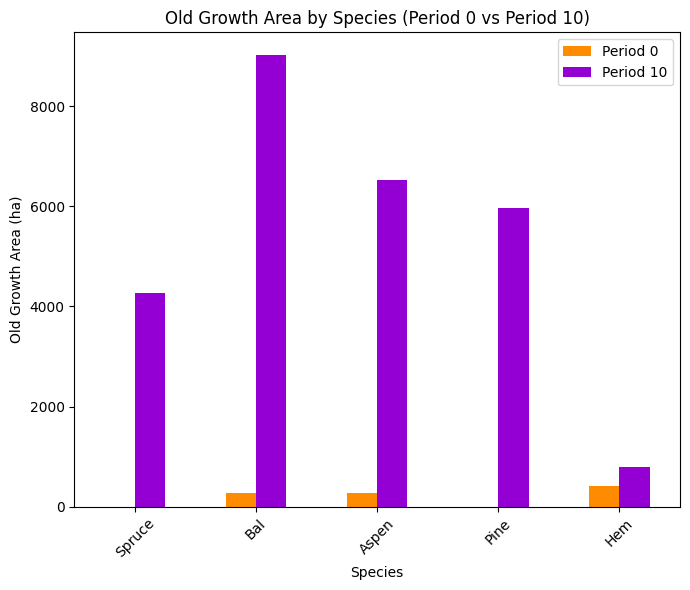

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9003

Diversity has **decreased** by 4.53% from time 0 to time 10.


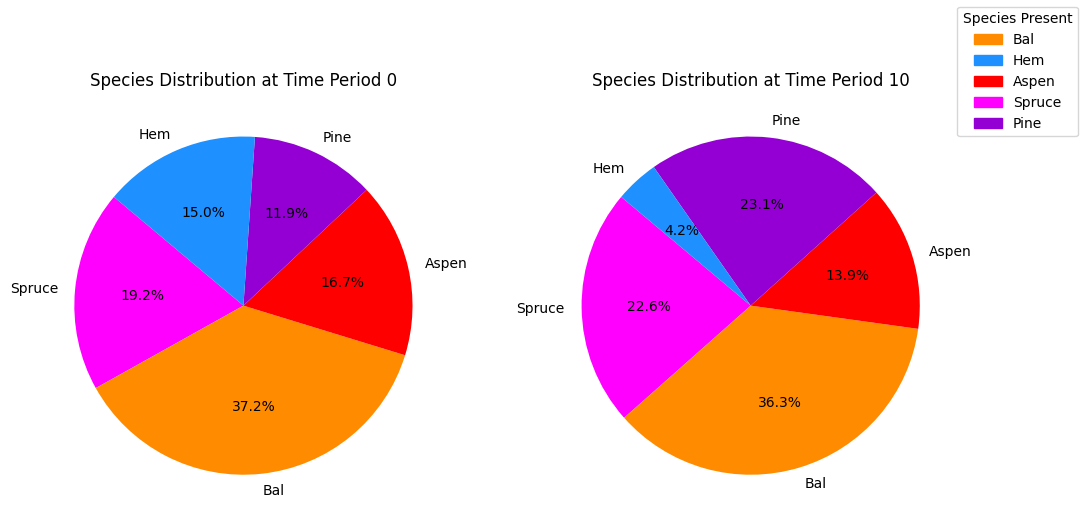

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_species_pie.pdf


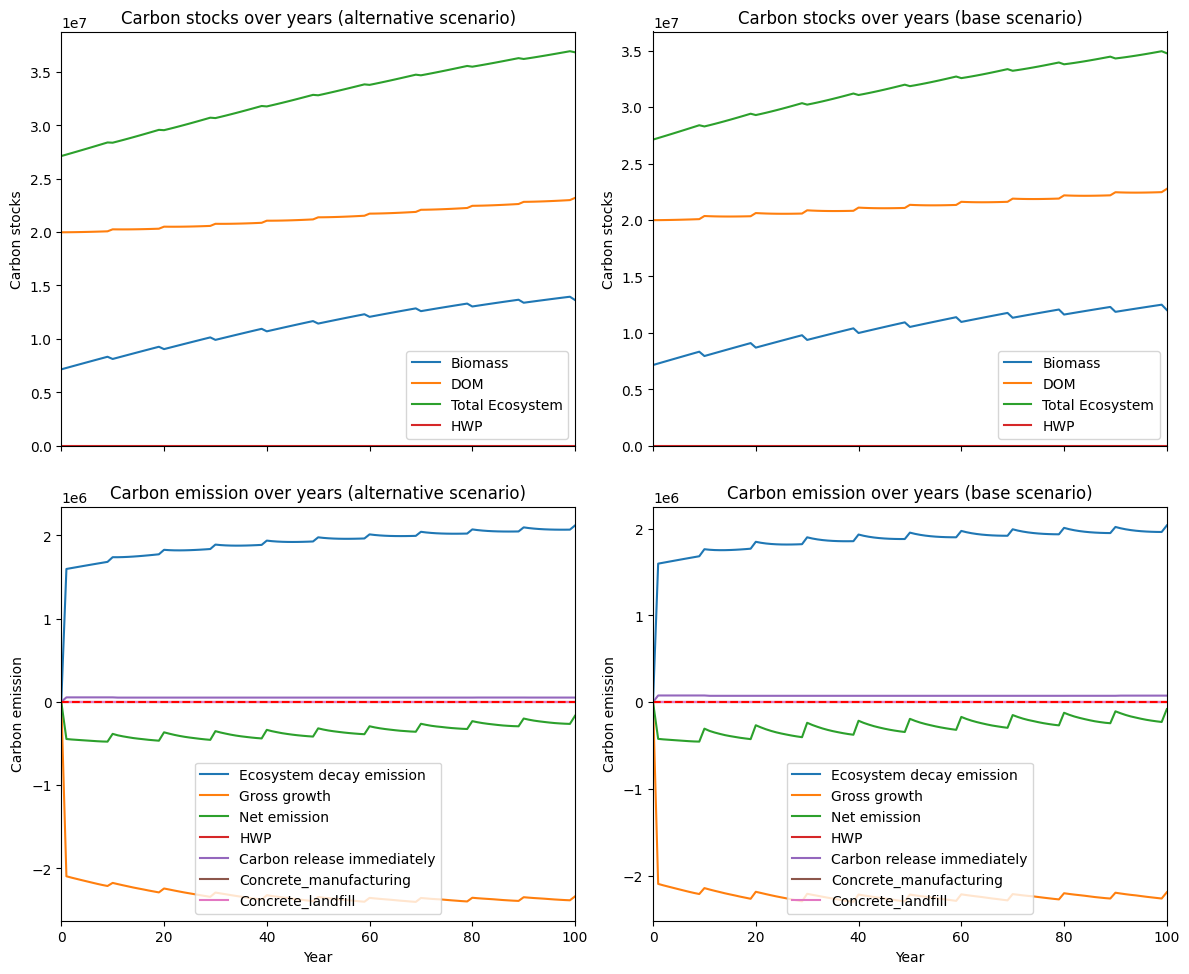

---------------------------------------------------------------------------------------
Net emission difference -1178231.7230285534
Net emission base scenario -10501053.28194359
Net emission alternative scenario -9322821.558915036
dollar_per_ton is:  8.487294820322589
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  1081.115348  1081.115348
Bal     0.0  2488.203170  2488.203170
Aspen   0.0  1806.360395  1806.360395
Pine    0.0  1137.742624  1137.742624
Hem     0.0   342.641607   342.641607

Overall, the old growth area has **increased** by 6856.06 hectares in the alternative scenario compared to the base scenario.


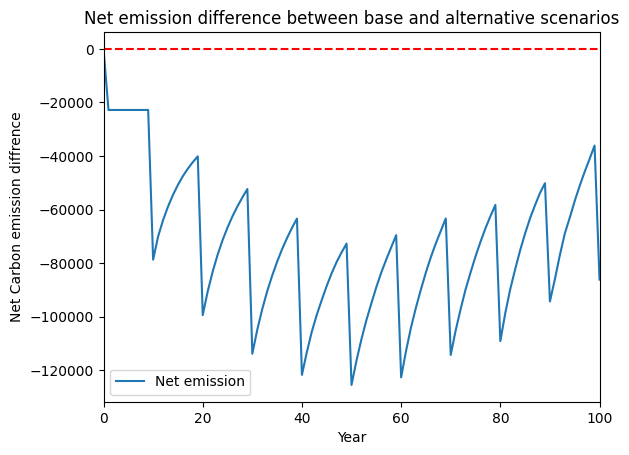

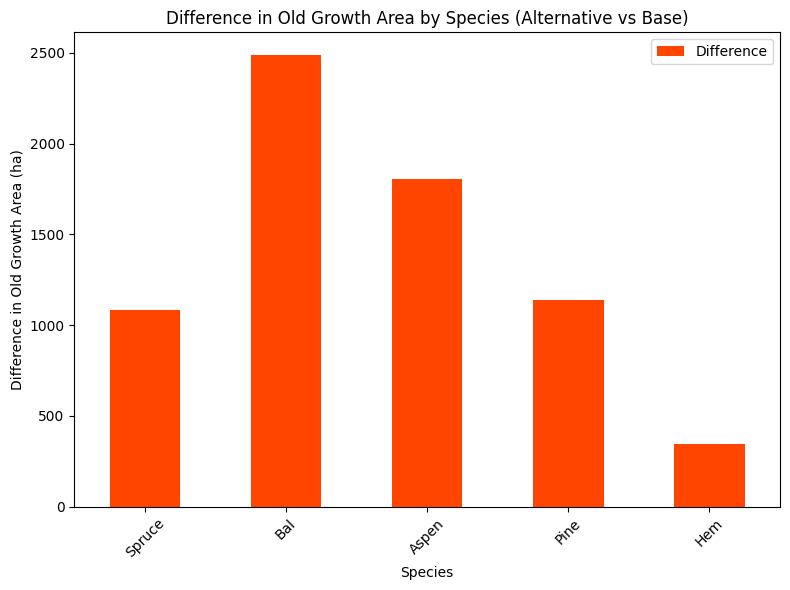

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_age_difference.pdf


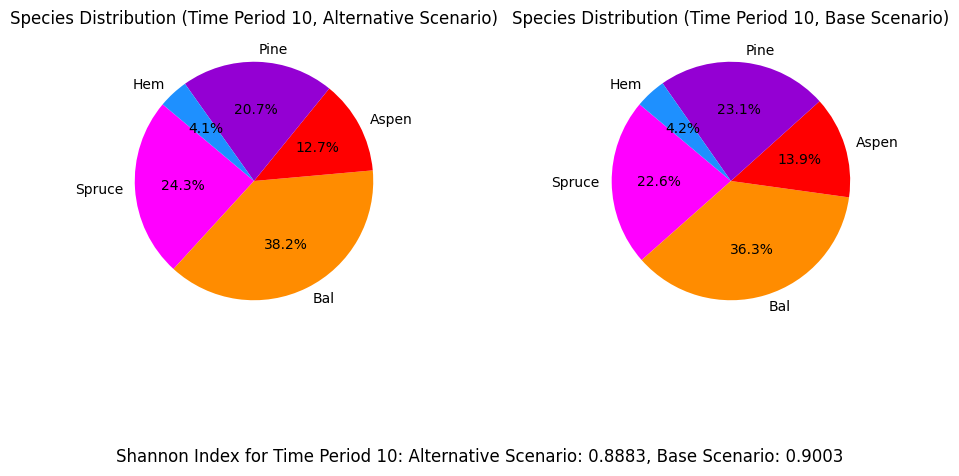

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_ha_gldbr_AAC_60%...
running the scenario for the Golden Bear mining site (60%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x783b6ded
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.23s
Presolved: 1911 rows, 32226 

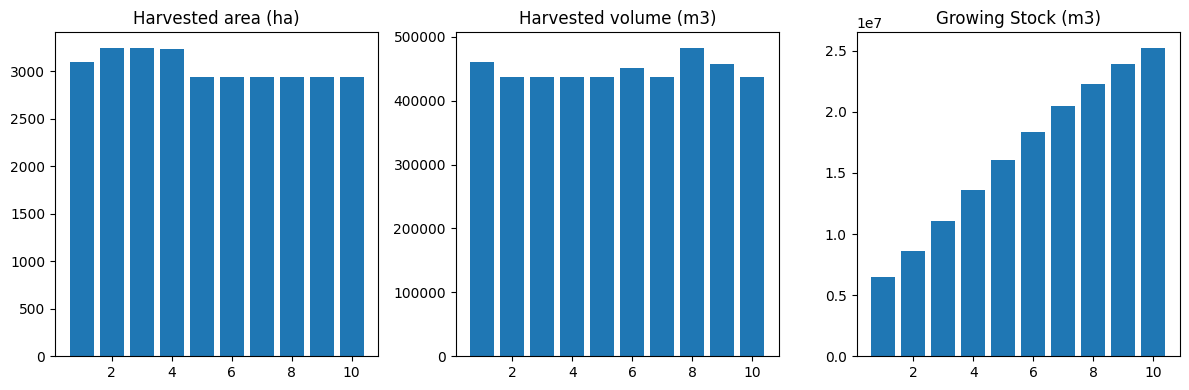

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_60%_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  4726
The economic indicator (the provincial government revenues) is:  161180
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


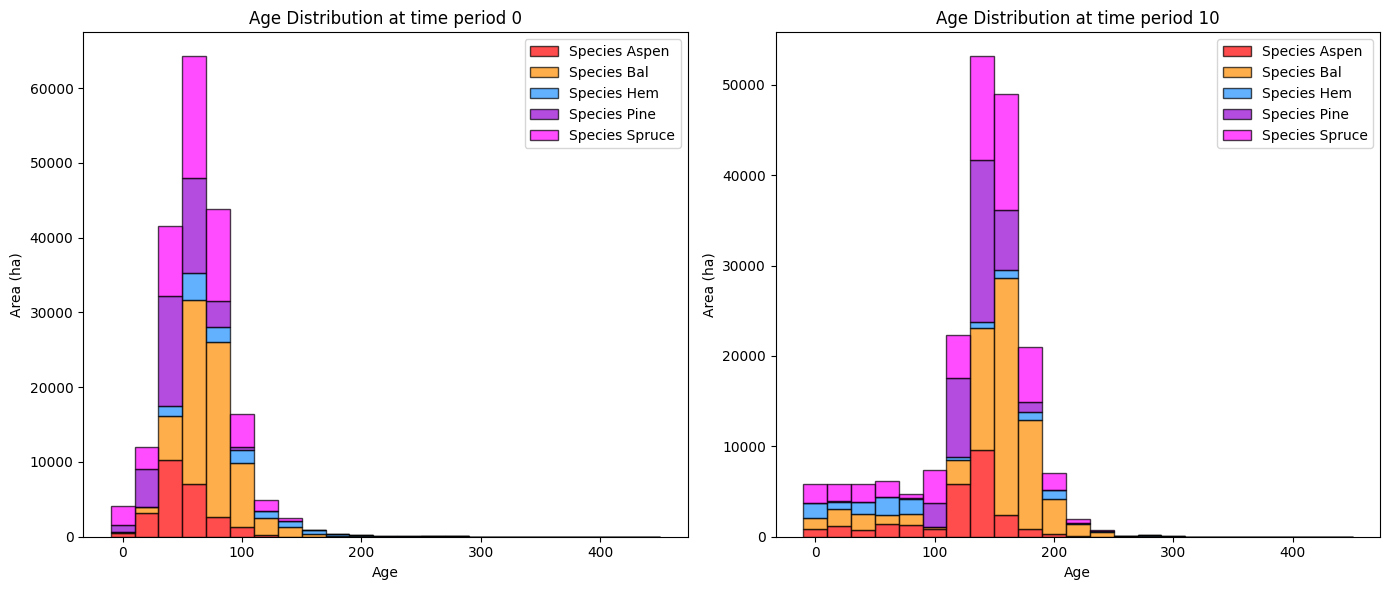

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_60%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5435.709671   5433.001137
Bal     278.565372  12108.102006  11829.536634
Aspen   273.490478   8780.570265   8507.079787
Pine      0.000000   7482.278925   7482.278925
Hem     419.699331   1257.348112    837.648782

Overall diversity has **increased** by 34089.55 hectares from time period 0 to time period 10.


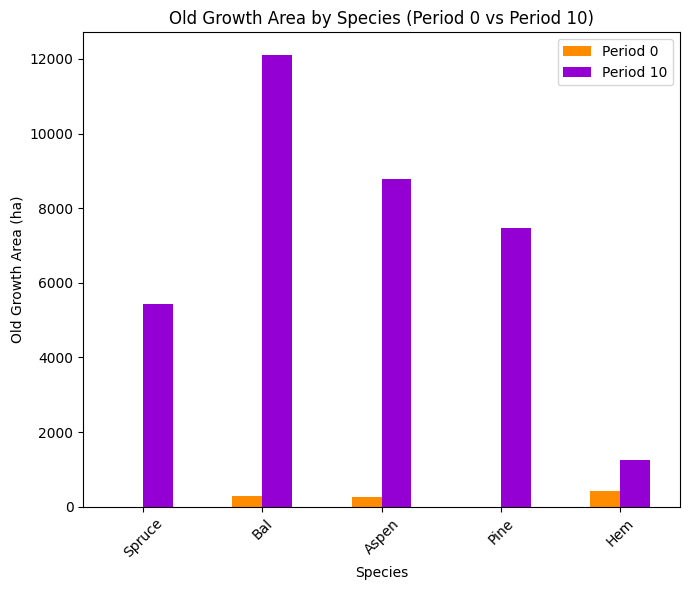

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_60%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8848

Diversity has **decreased** by 6.07% from time 0 to time 10.


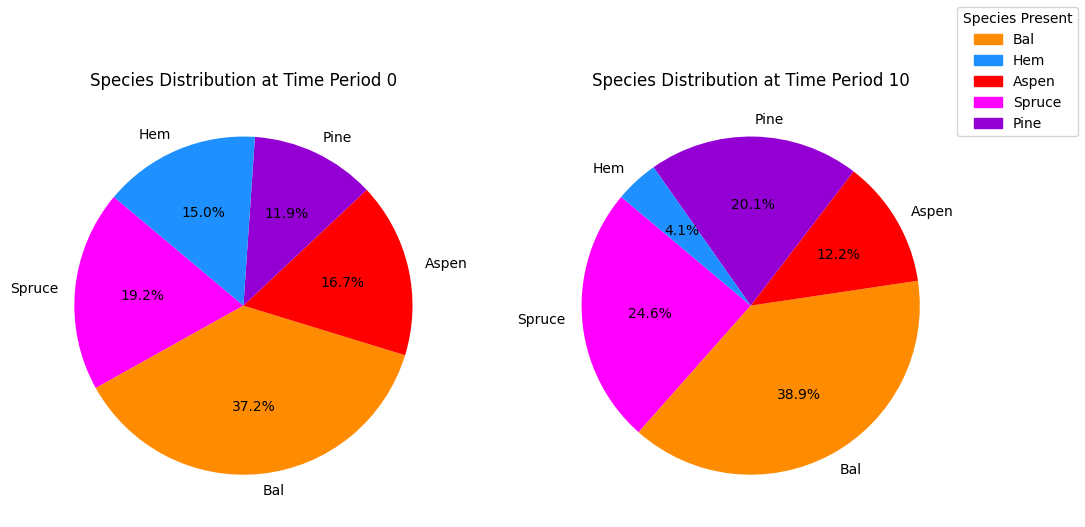

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_60%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x17162bc7
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.26s
Presolved: 1911 rows, 32225 columns, 407291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

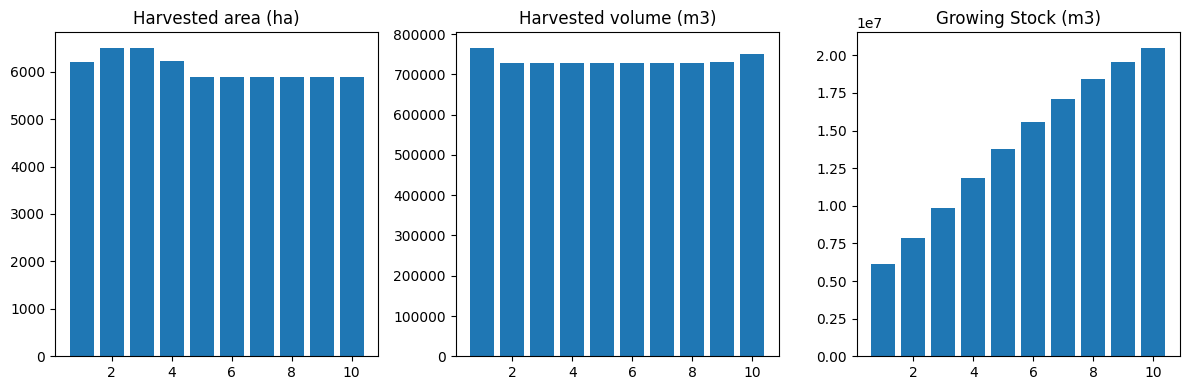

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7759
The economic indicator (the provincial government revenues) is:  264628
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


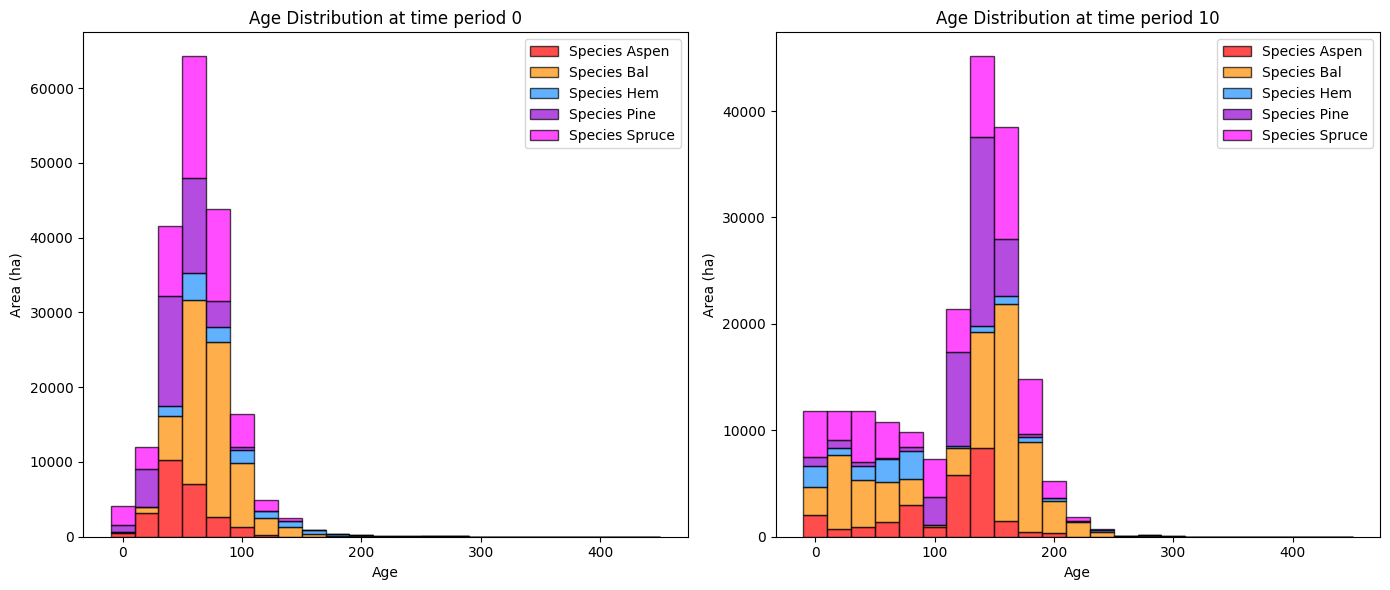

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4259.936249  4257.227716
Bal     278.565372  9020.773269  8742.207898
Aspen   273.490478  6525.108441  6251.617963
Pine      0.000000  5968.010518  5968.010518
Hem     419.699331   801.166864   381.467533

Overall diversity has **increased** by 25600.53 hectares from time period 0 to time period 10.


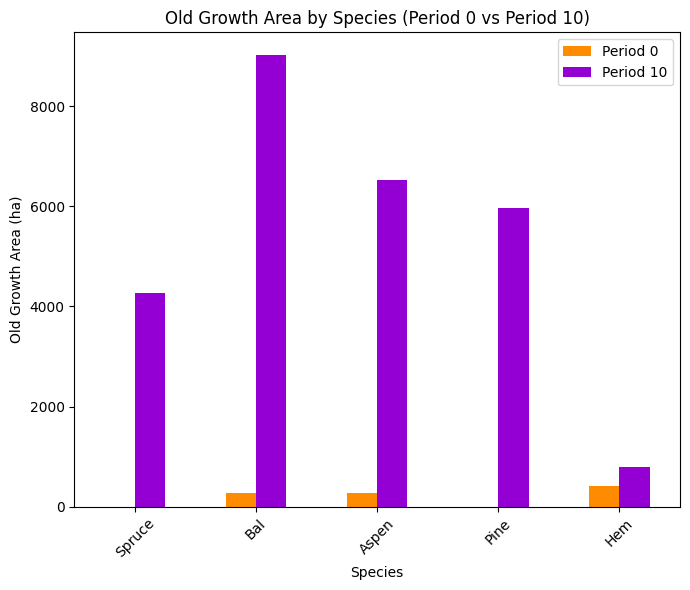

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9003

Diversity has **decreased** by 4.53% from time 0 to time 10.


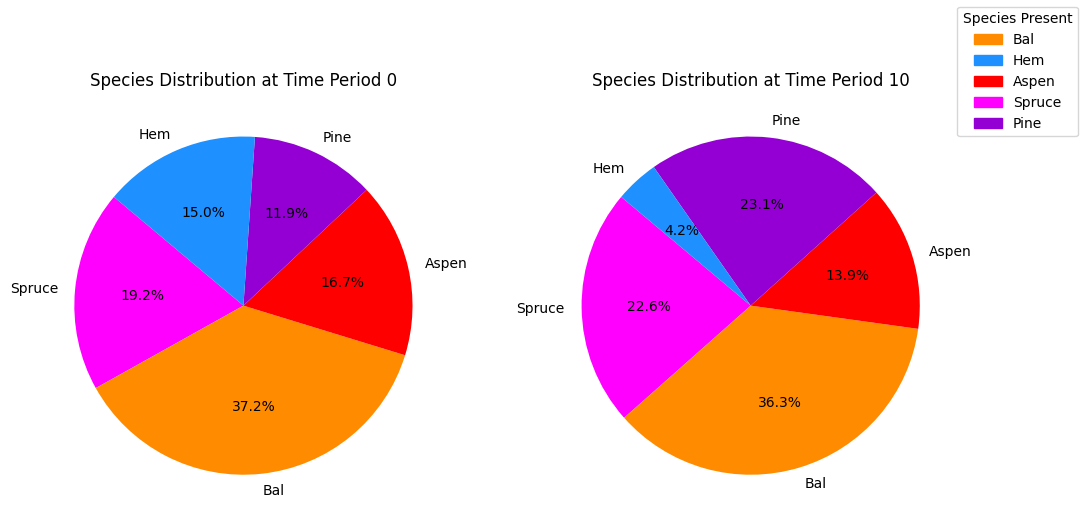

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_species_pie.pdf


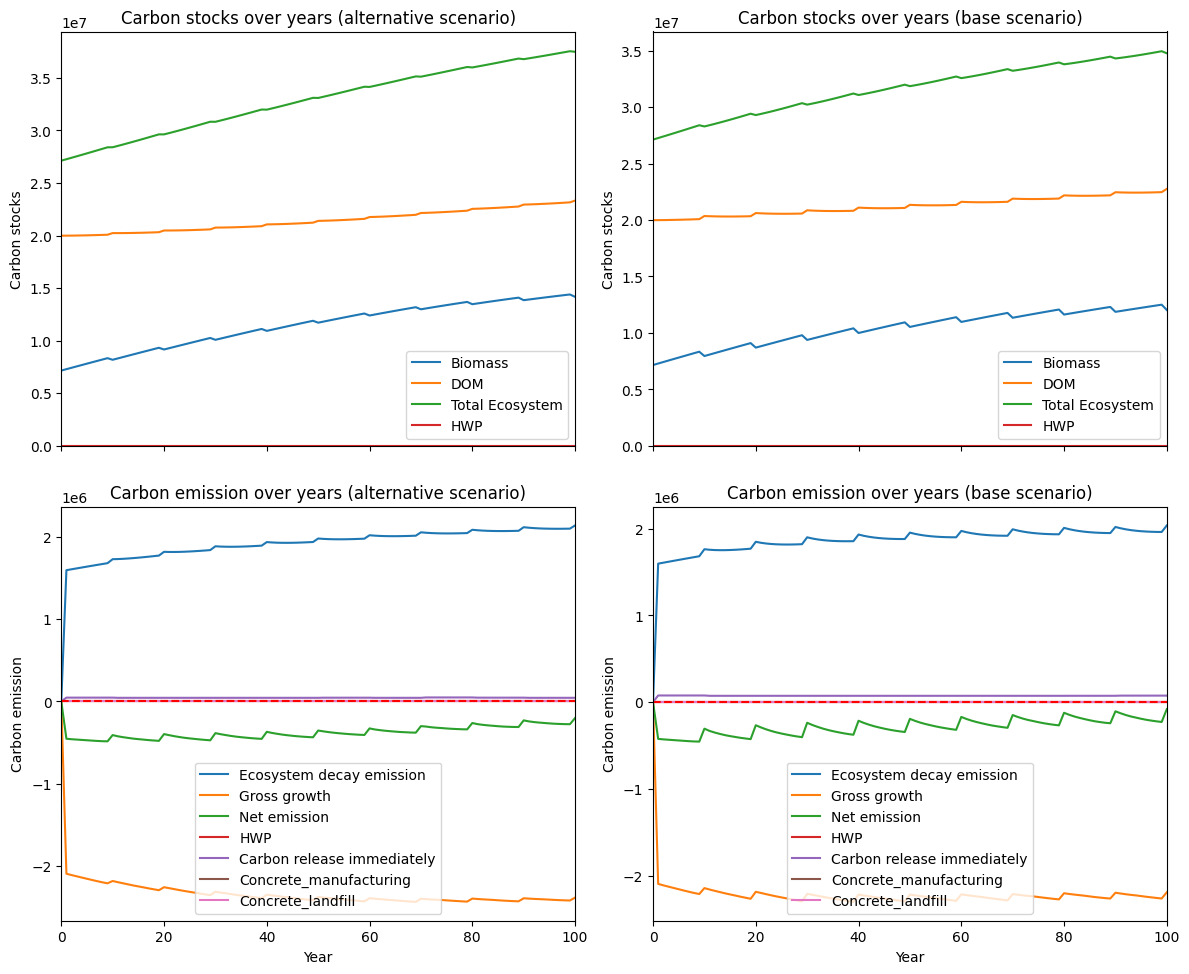

---------------------------------------------------------------------------------------
Net emission difference -1553737.9333390617
Net emission base scenario -10876559.492254097
Net emission alternative scenario -9322821.558915036
dollar_per_ton is:  6.436091817948663
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  1175.773421  1175.773421
Bal     0.0  3087.328737  3087.328737
Aspen   0.0  2255.461825  2255.461825
Pine    0.0  1514.268407  1514.268407
Hem     0.0   456.181249   456.181249

Overall, the old growth area has **increased** by 8489.01 hectares in the alternative scenario compared to the base scenario.


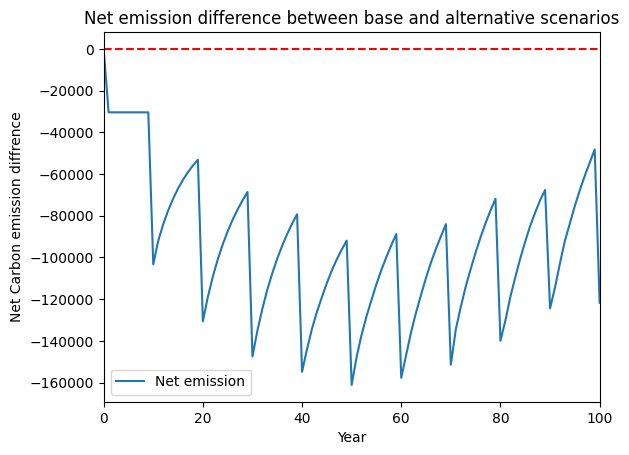

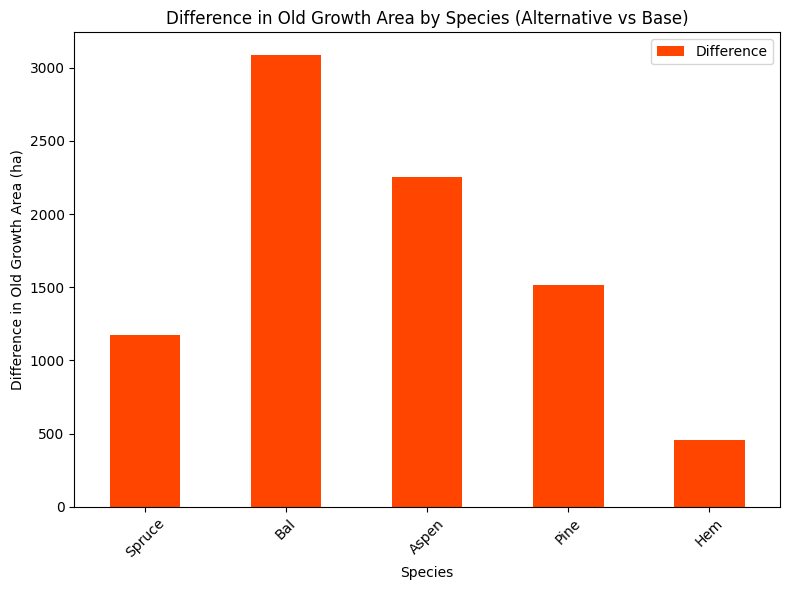

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_age_difference.pdf


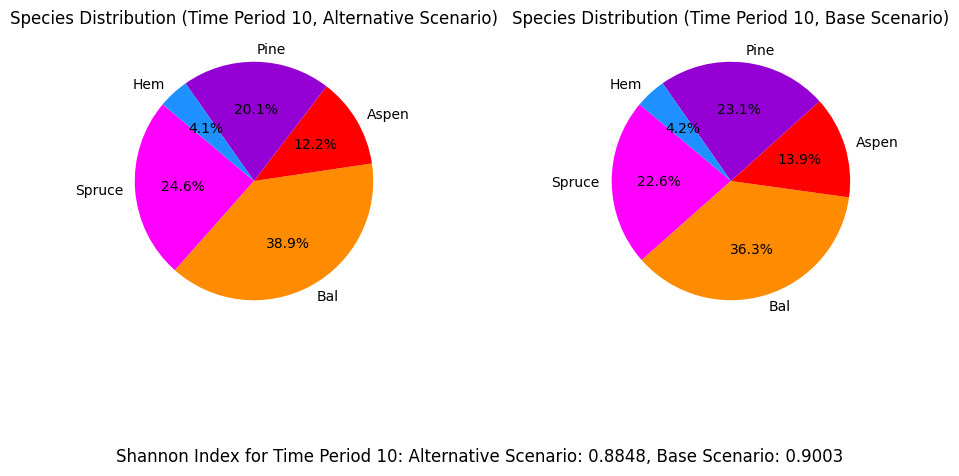

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_ha_gldbr_AAC_50%...
running the scenario for the Golden Bear mining site (50%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xd0a9ea1e
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.20s
Presolved: 1911 rows, 32226 

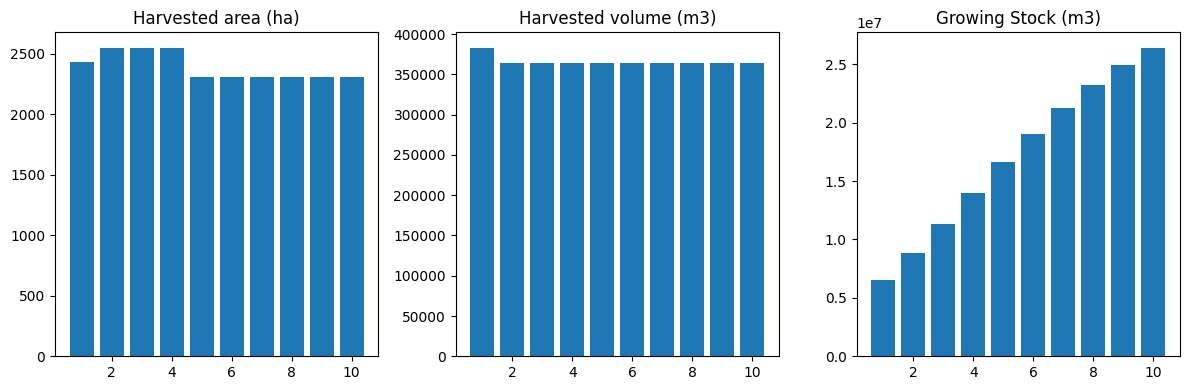

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_50%_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  3867
The economic indicator (the provincial government revenues) is:  131881
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


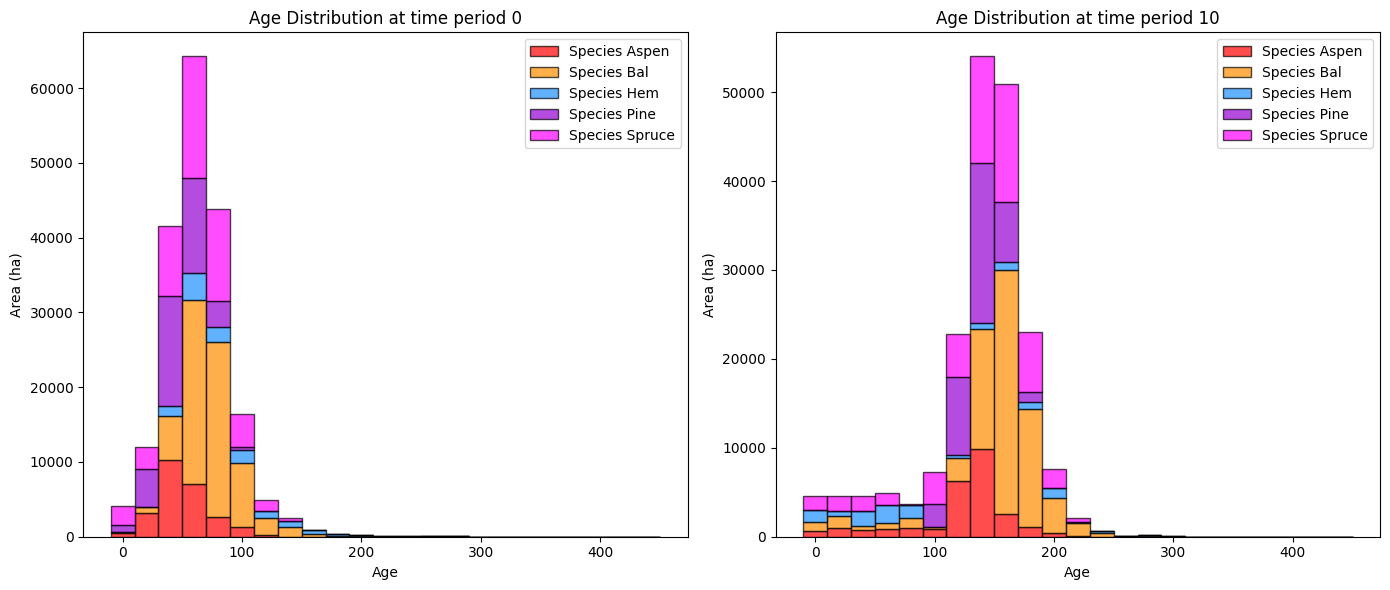

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_50%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5878.167261   5875.458727
Bal     278.565372  13316.418240  13037.852868
Aspen   273.490478   9641.724255   9368.233777
Pine      0.000000   7577.677029   7577.677029
Hem     419.699331   1459.085409   1039.386079

Overall diversity has **increased** by 36898.61 hectares from time period 0 to time period 10.


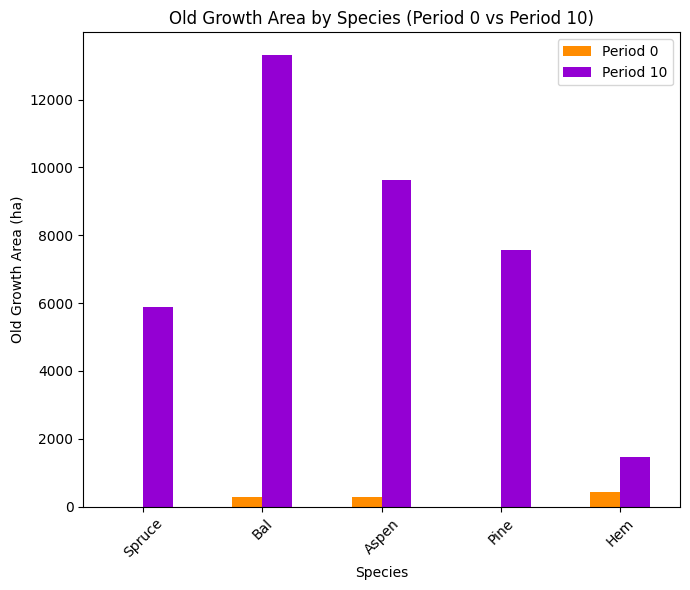

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_50%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8843

Diversity has **decreased** by 6.12% from time 0 to time 10.


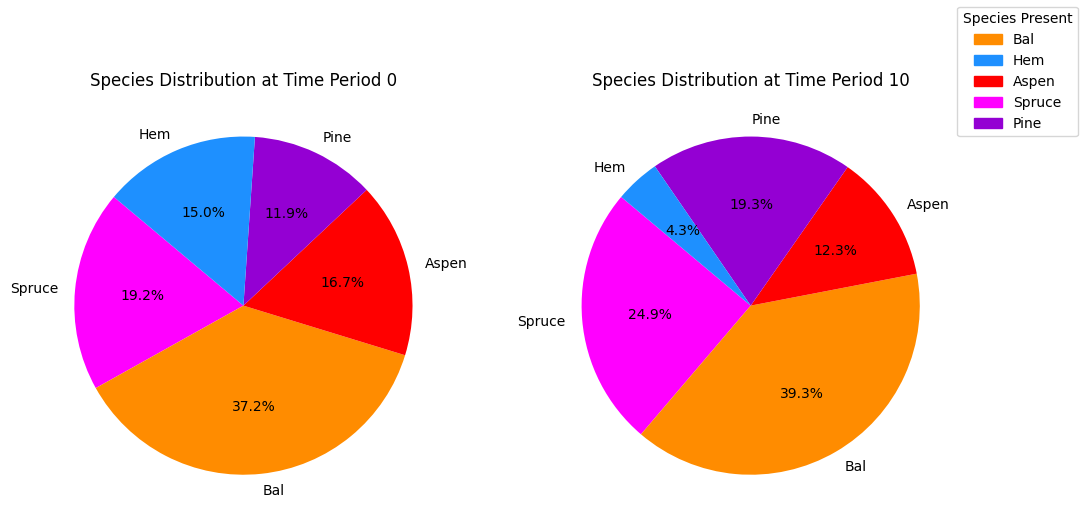

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_50%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x17162bc7
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.23s
Presolved: 1911 rows, 32225 columns, 407291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

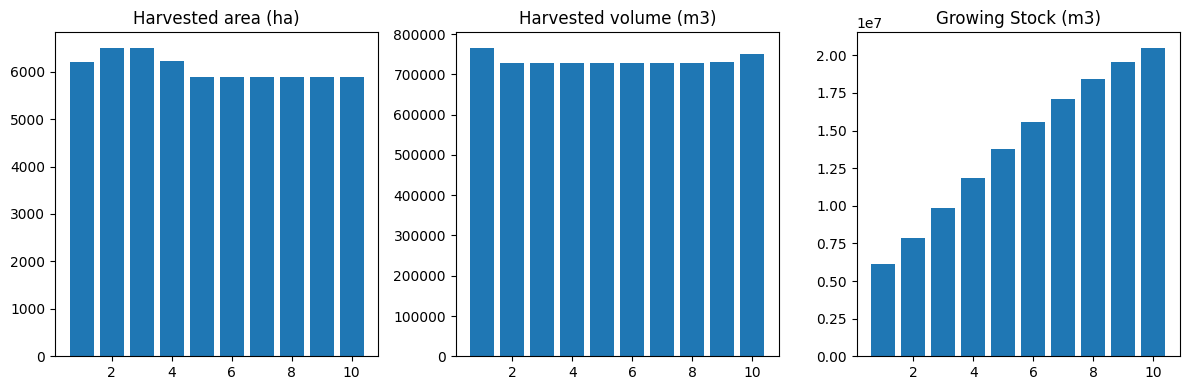

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7759
The economic indicator (the provincial government revenues) is:  264628
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


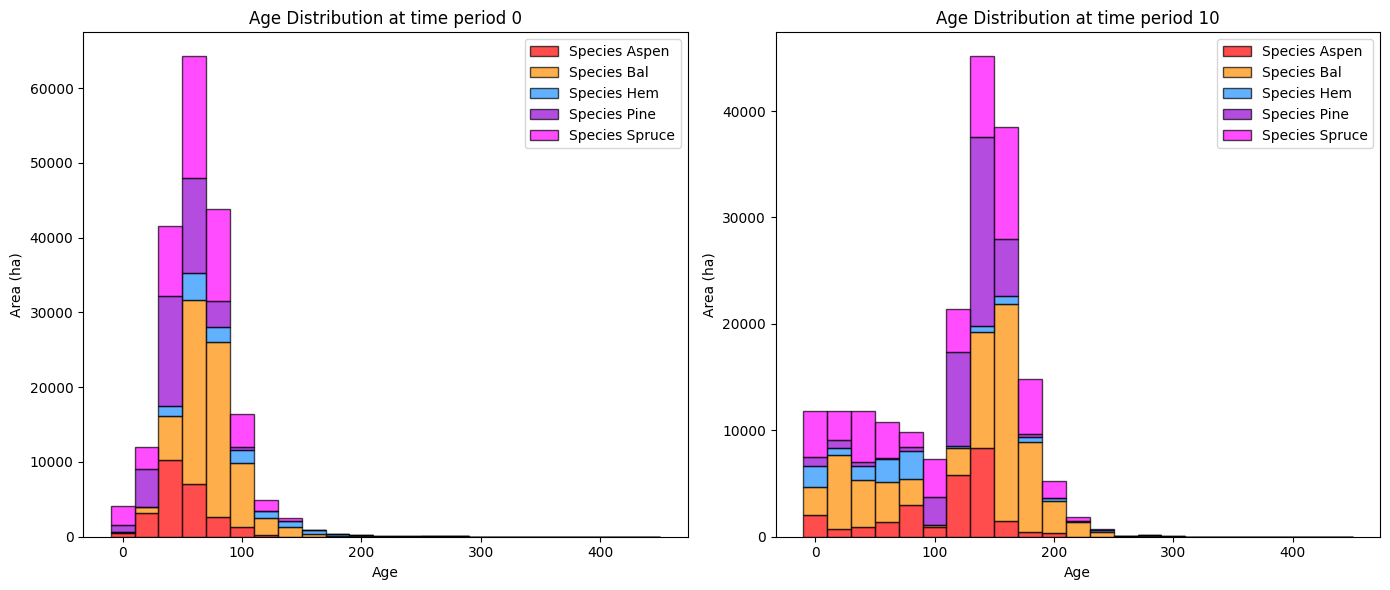

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4259.936249  4257.227716
Bal     278.565372  9020.773269  8742.207898
Aspen   273.490478  6525.108441  6251.617963
Pine      0.000000  5968.010518  5968.010518
Hem     419.699331   801.166864   381.467533

Overall diversity has **increased** by 25600.53 hectares from time period 0 to time period 10.


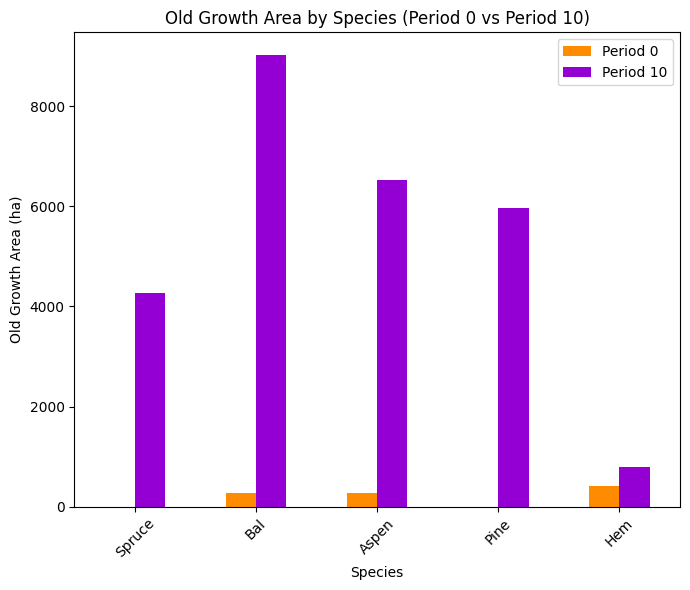

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9003

Diversity has **decreased** by 4.53% from time 0 to time 10.


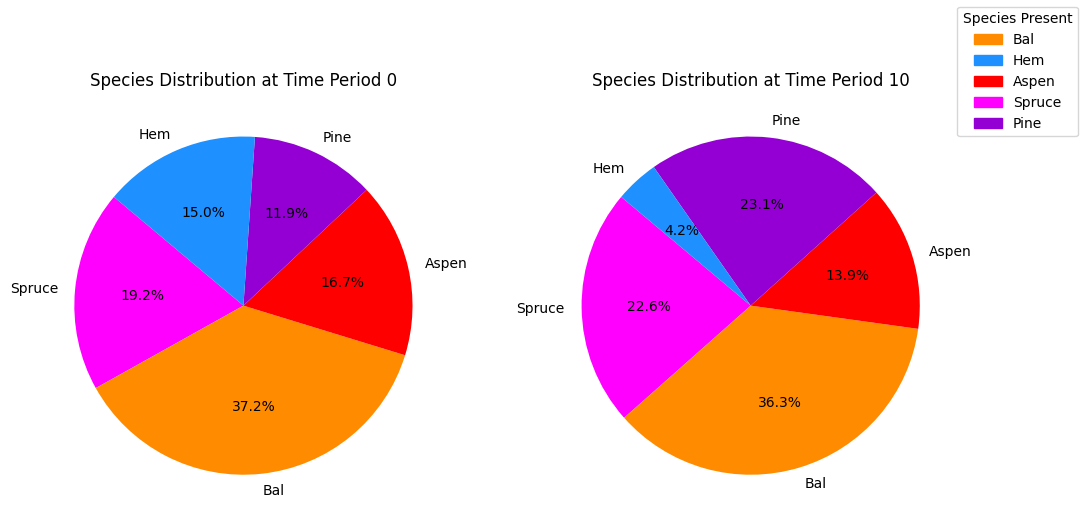

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_species_pie.pdf


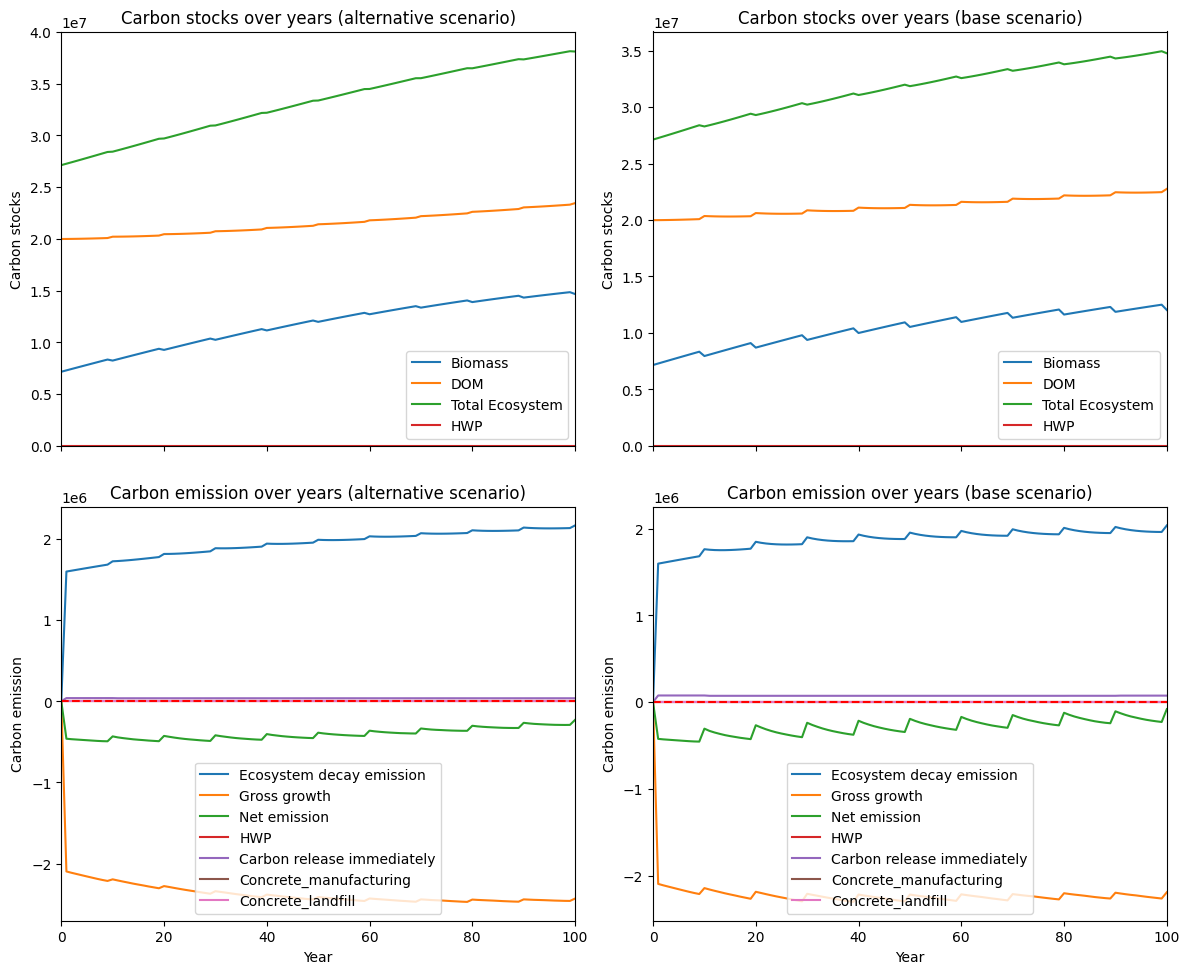

---------------------------------------------------------------------------------------
Net emission difference -1914446.4140135676
Net emission base scenario -11237267.972928602
Net emission alternative scenario -9322821.558915036
dollar_per_ton is:  5.223442101487375
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  1618.231011  1618.231011
Bal     0.0  4295.644970  4295.644970
Aspen   0.0  3116.615814  3116.615814
Pine    0.0  1609.666511  1609.666511
Hem     0.0   657.918546   657.918546

Overall, the old growth area has **increased** by 11298.08 hectares in the alternative scenario compared to the base scenario.


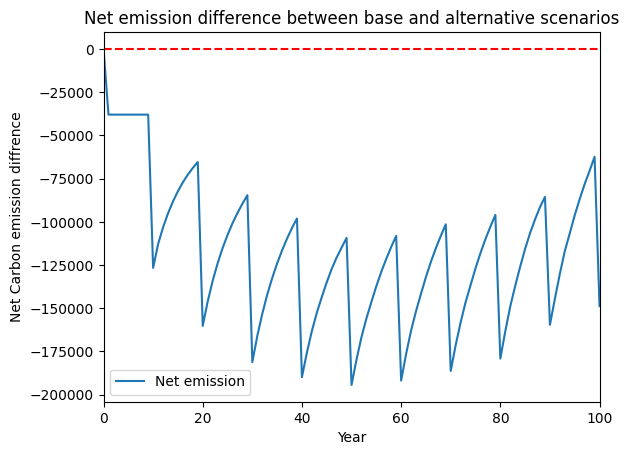

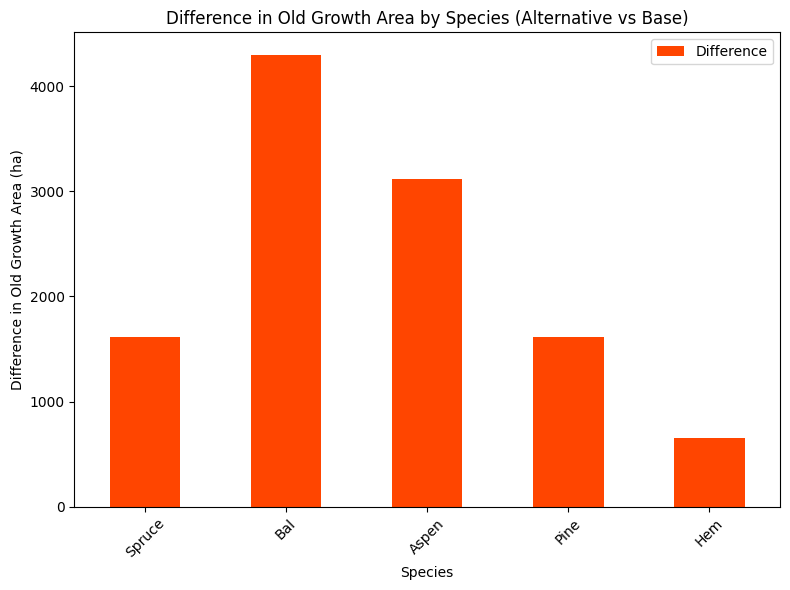

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_age_difference.pdf


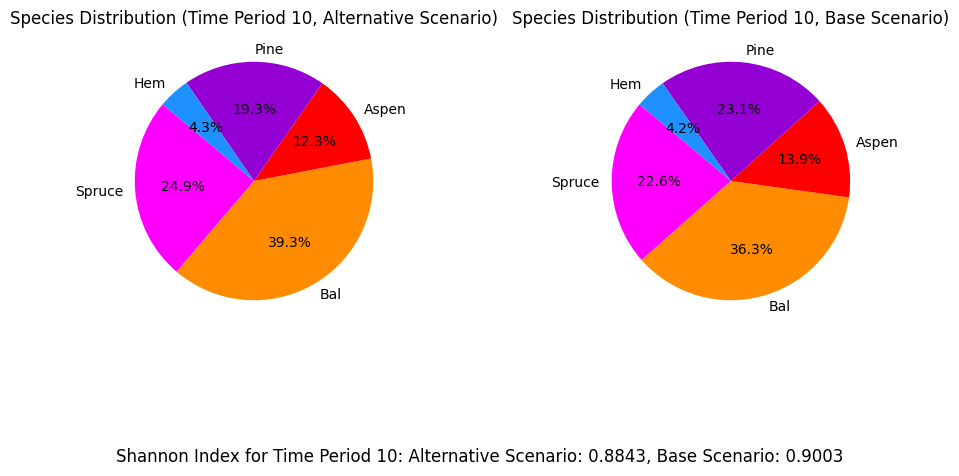

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_ha_gldbr_AAC_40%...
running the scenario for the Golden Bear mining site (40%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x184ee945
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.20s
Presolved: 1911 rows, 32226 

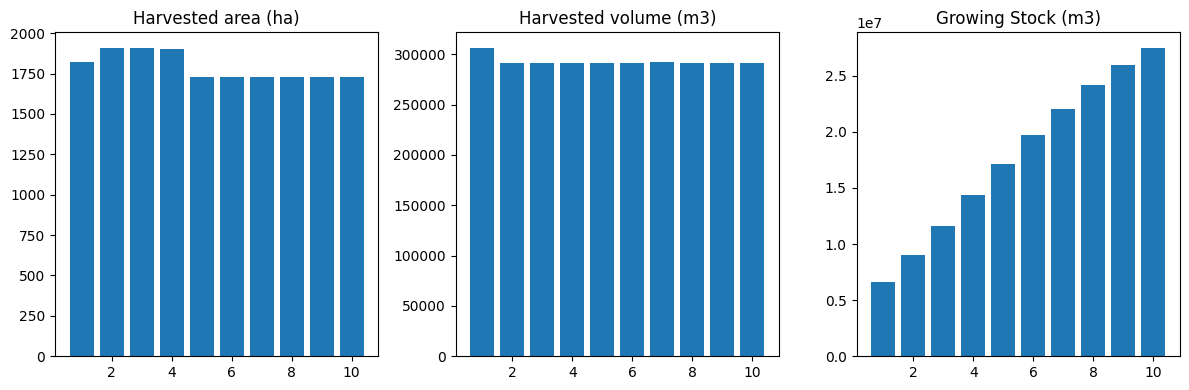

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_40%_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  3094
The economic indicator (the provincial government revenues) is:  105539
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


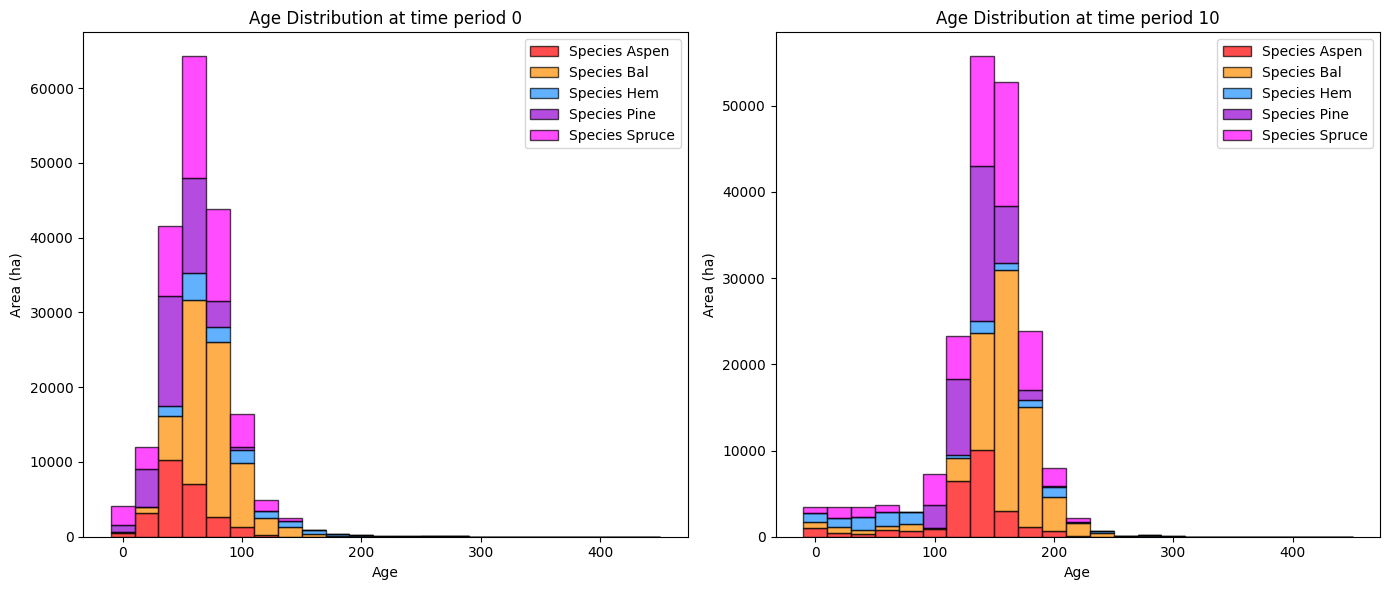

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_40%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   6457.218580   6454.510047
Bal     278.565372  13811.648105  13533.082733
Aspen   273.490478  10611.398243  10337.907765
Pine      0.000000   7624.792624   7624.792624
Hem     419.699331   1499.652633   1079.953303

Overall diversity has **increased** by 39030.25 hectares from time period 0 to time period 10.


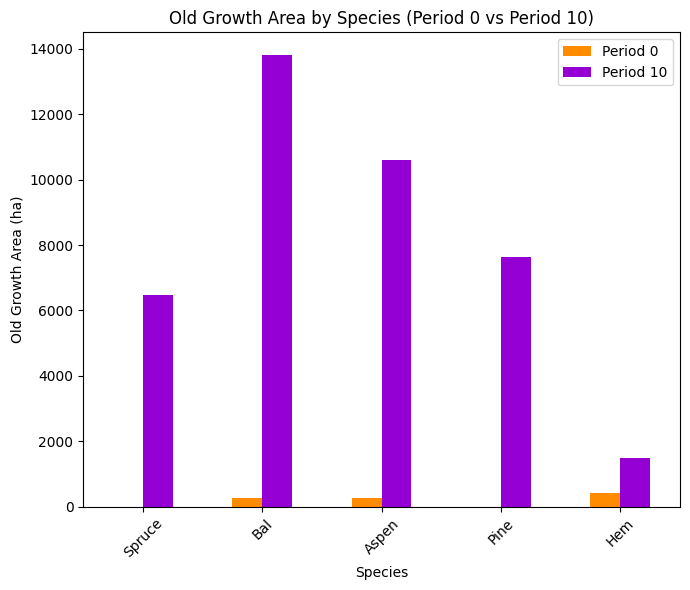

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_40%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8875

Diversity has **decreased** by 5.80% from time 0 to time 10.


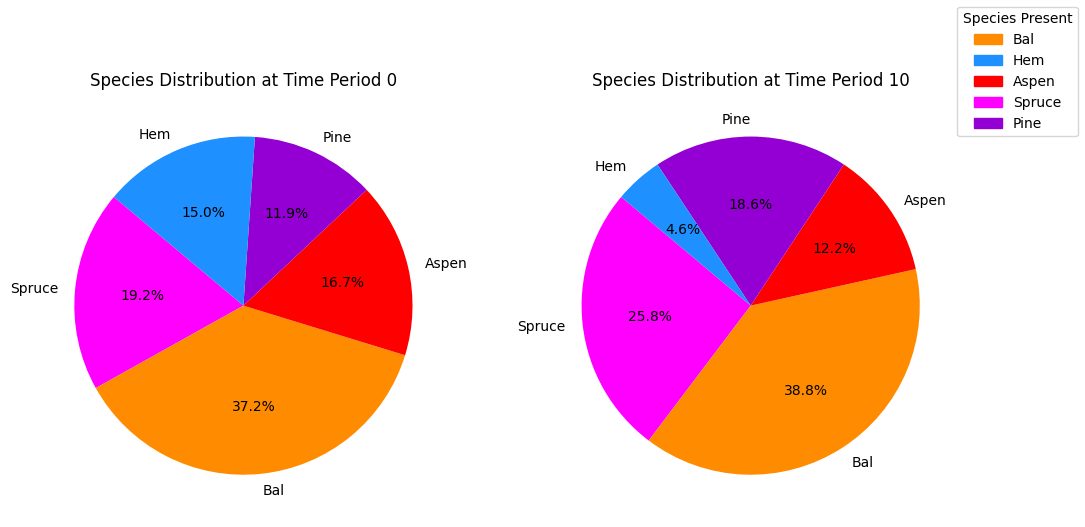

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_40%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x17162bc7
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.21s
Presolved: 1911 rows, 32225 columns, 407291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

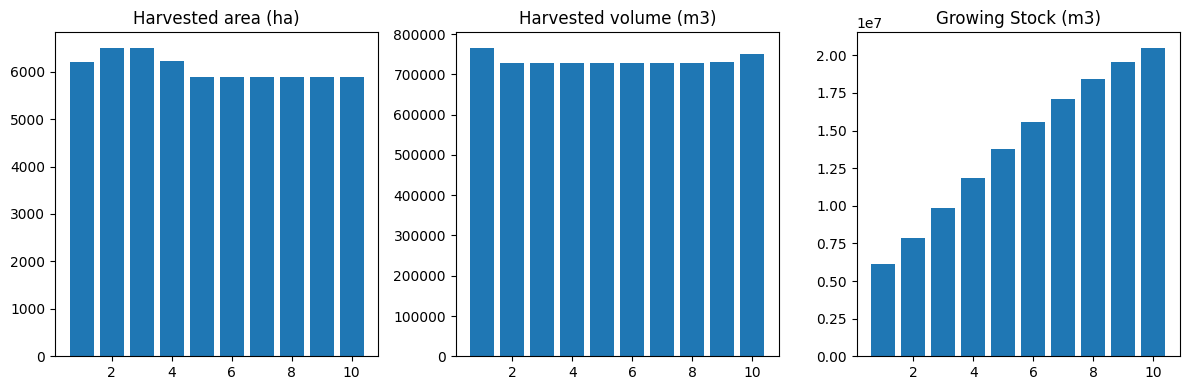

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7759
The economic indicator (the provincial government revenues) is:  264628
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


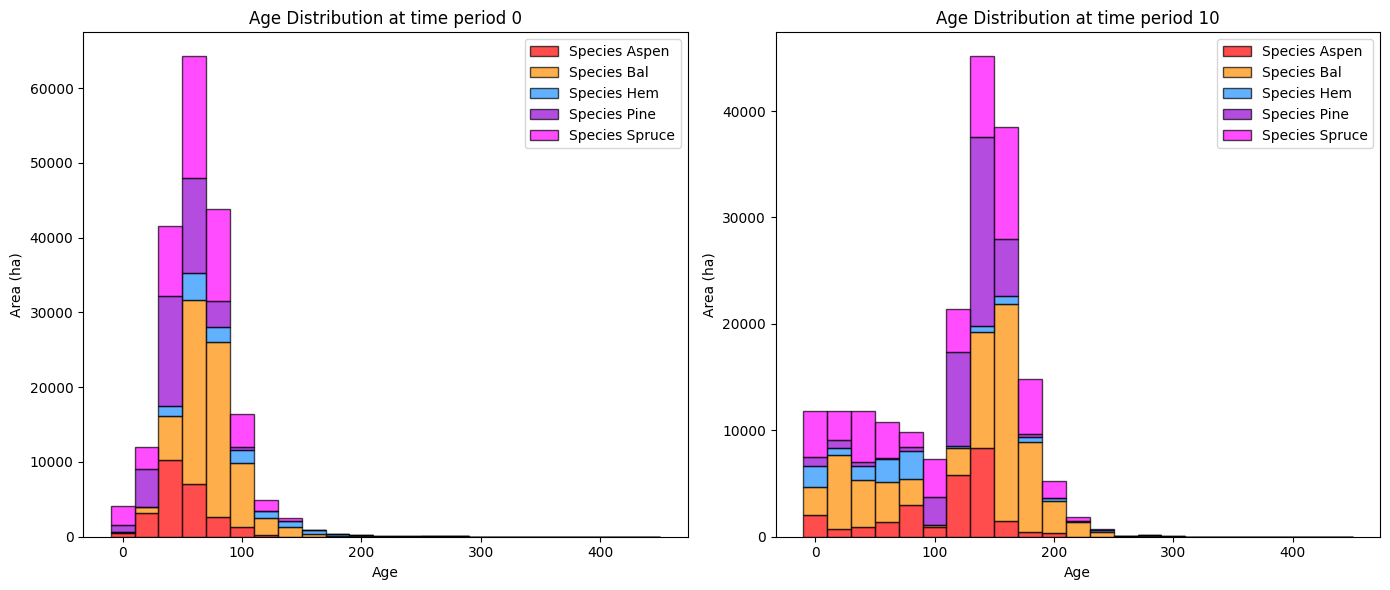

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4259.936249  4257.227716
Bal     278.565372  9020.773269  8742.207898
Aspen   273.490478  6525.108441  6251.617963
Pine      0.000000  5968.010518  5968.010518
Hem     419.699331   801.166864   381.467533

Overall diversity has **increased** by 25600.53 hectares from time period 0 to time period 10.


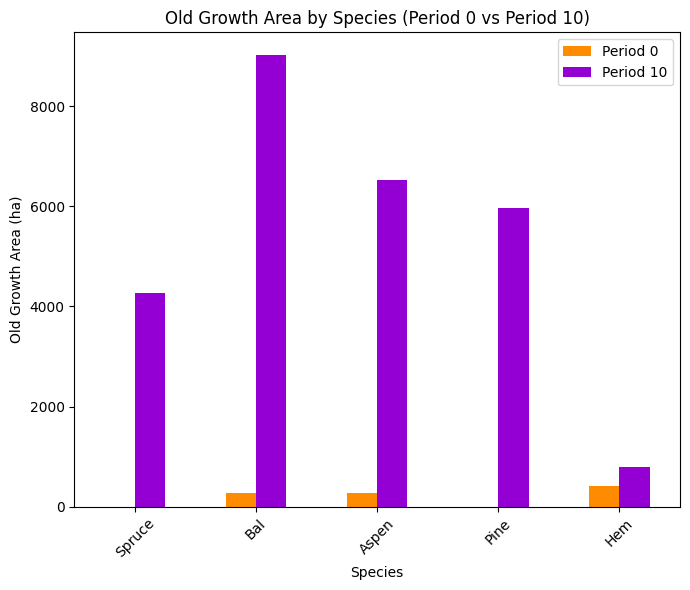

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9003

Diversity has **decreased** by 4.53% from time 0 to time 10.


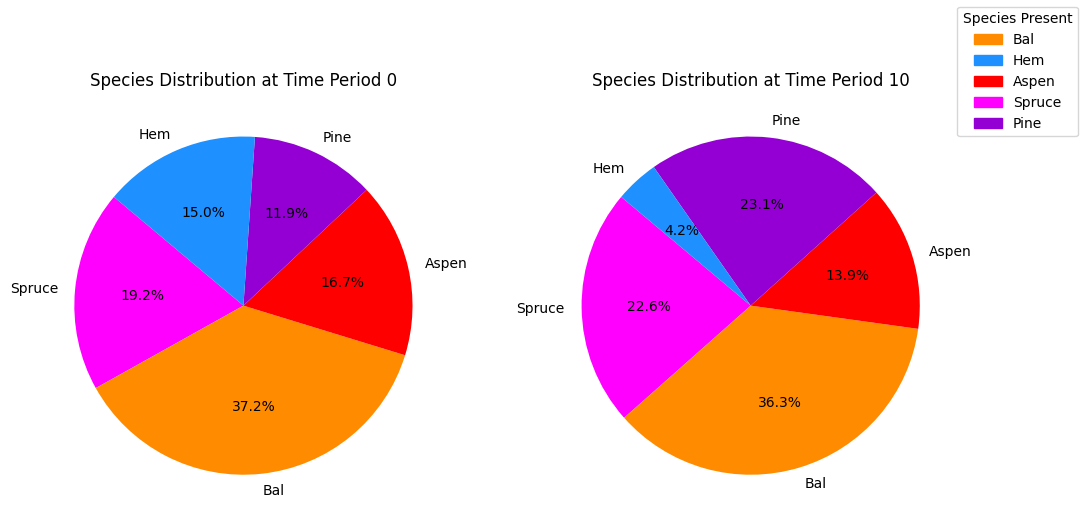

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_species_pie.pdf


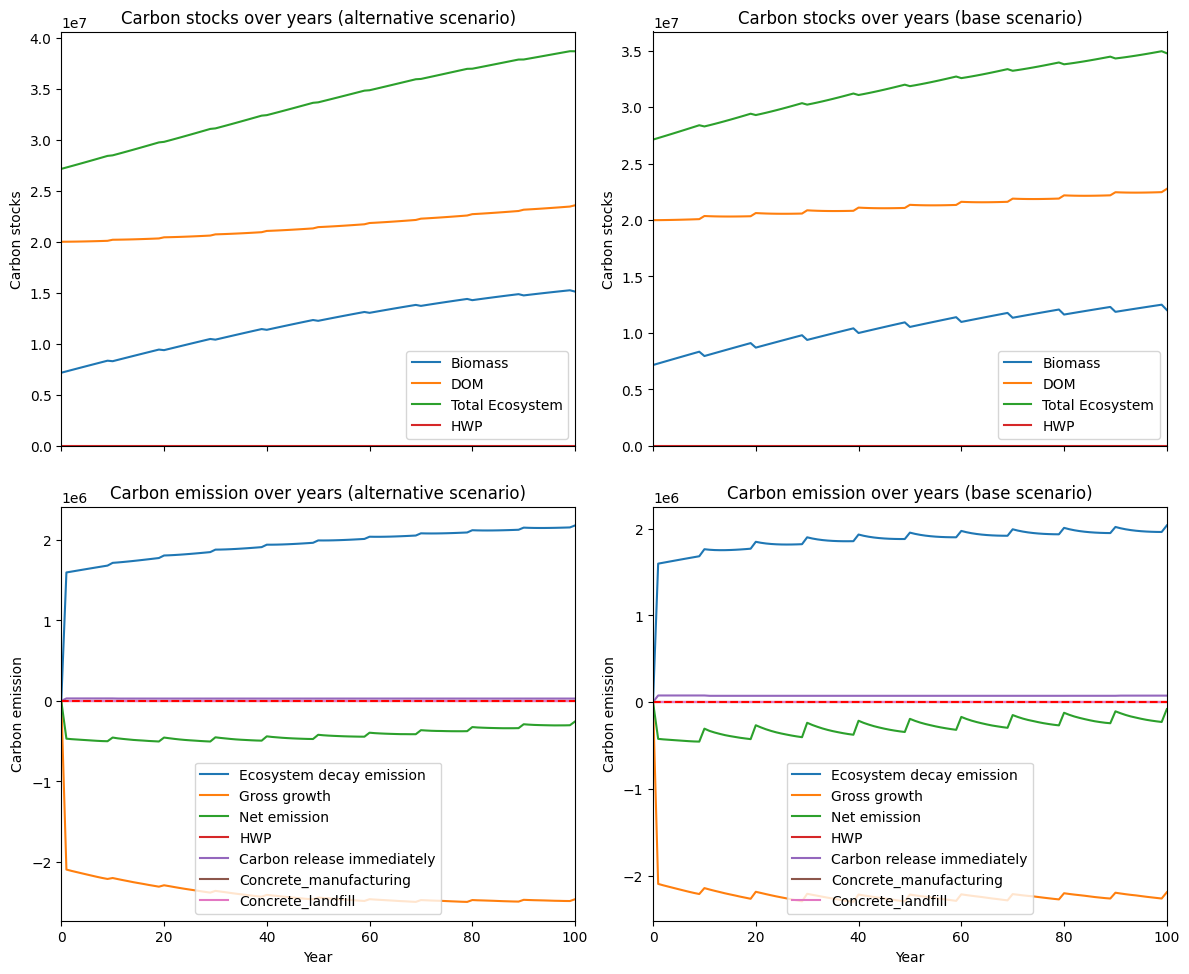

---------------------------------------------------------------------------------------
Net emission difference -2263196.5468078945
Net emission base scenario -11586018.10572293
Net emission alternative scenario -9322821.558915036
dollar_per_ton is:  4.418529187888878
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  2197.282331  2197.282331
Bal     0.0  4790.874836  4790.874836
Aspen   0.0  4086.289802  4086.289802
Pine    0.0  1656.782105  1656.782105
Hem     0.0   698.485770   698.485770

Overall, the old growth area has **increased** by 13429.71 hectares in the alternative scenario compared to the base scenario.


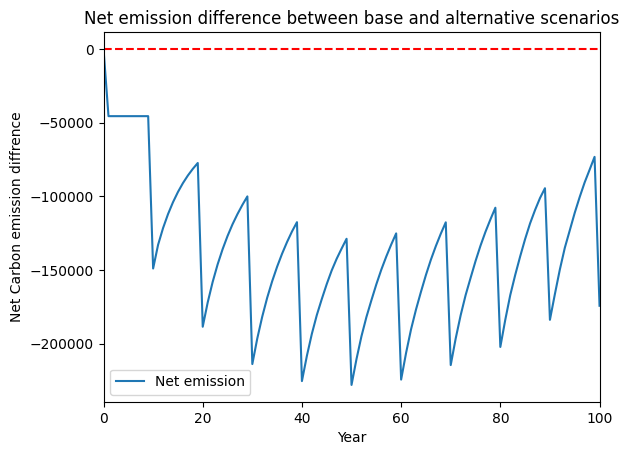

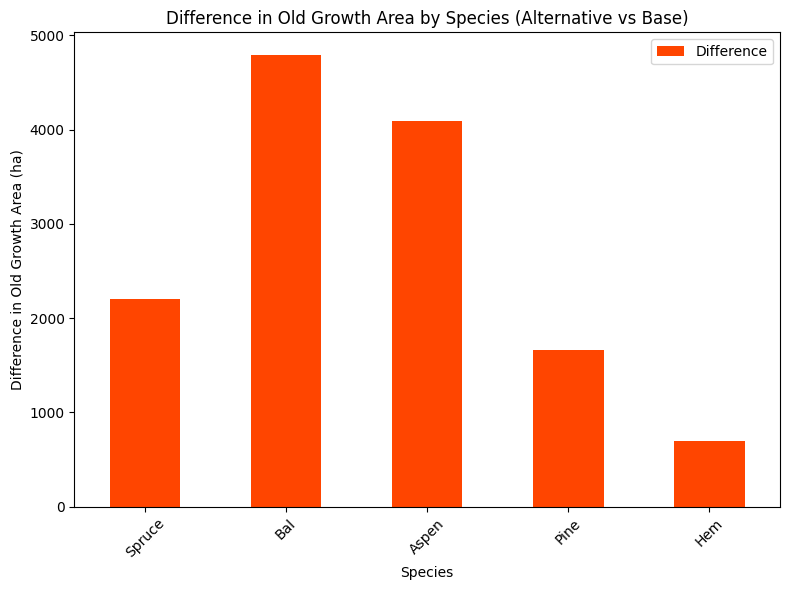

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_age_difference.pdf


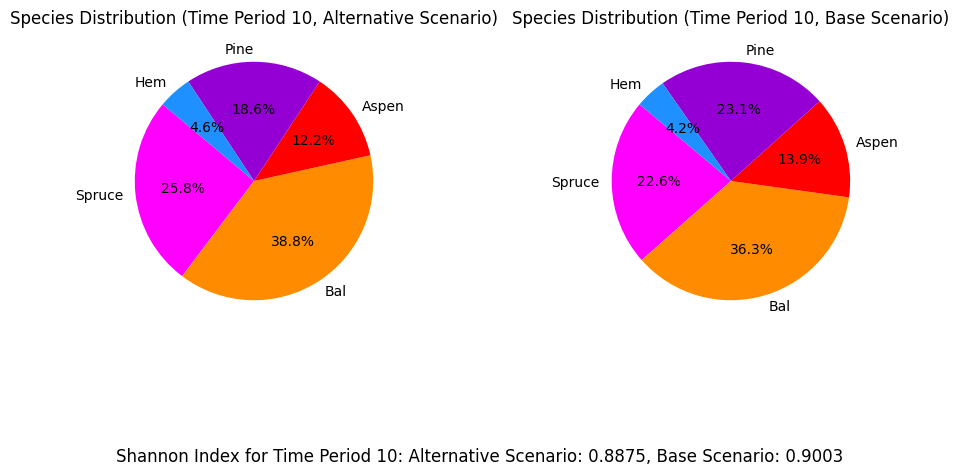

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_ha_gldbr_AAC_30%...
running the scenario for the Golden Bear mining site (30%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x3a744025
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.25s
Presolved: 1911 rows, 32226 

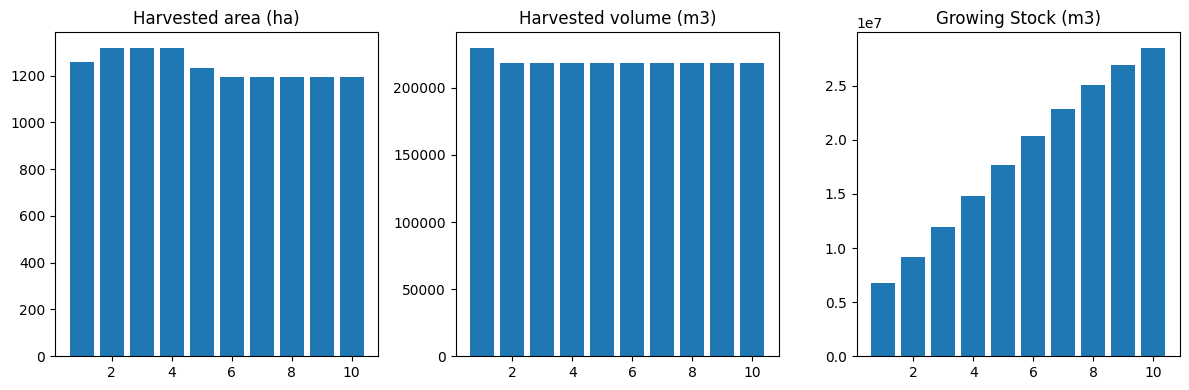

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_30%_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  2320
The economic indicator (the provincial government revenues) is:  79128
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


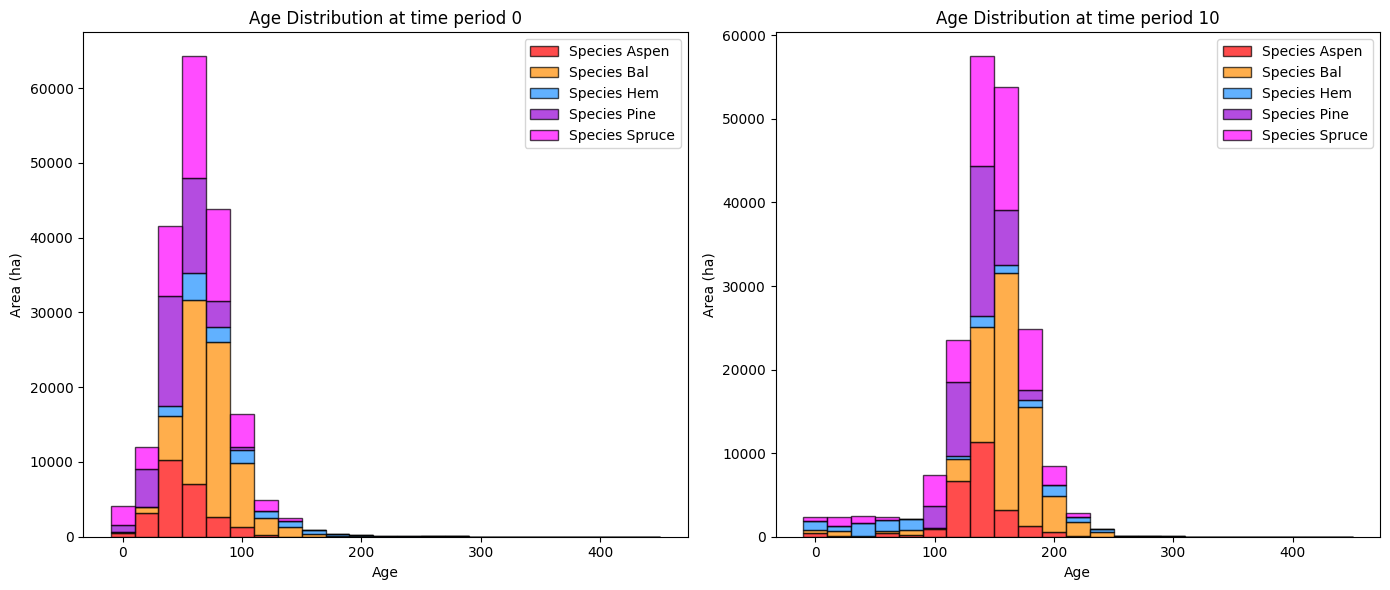

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_30%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   6906.304600   6903.596066
Bal     278.565372  14649.119171  14370.553799
Aspen   273.490478  11948.339062  11674.848584
Pine      0.000000   7631.887200   7631.887200
Hem     419.699331   1957.558344   1537.859013

Overall diversity has **increased** by 42118.74 hectares from time period 0 to time period 10.


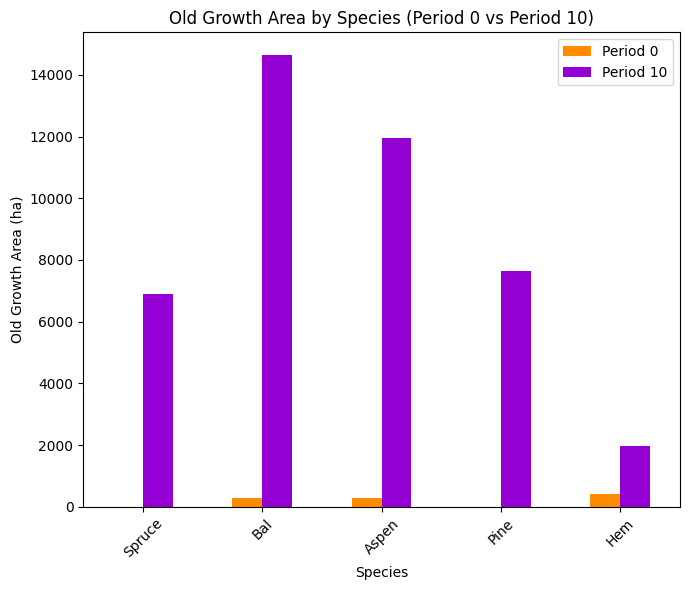

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_30%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8930

Diversity has **decreased** by 5.26% from time 0 to time 10.


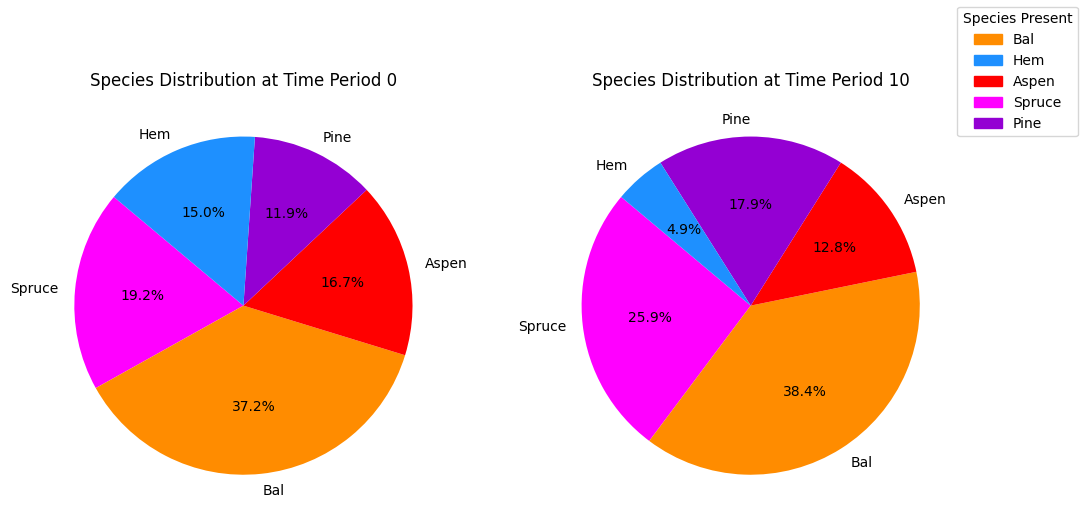

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_30%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x17162bc7
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.23s
Presolved: 1911 rows, 32225 columns, 407291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

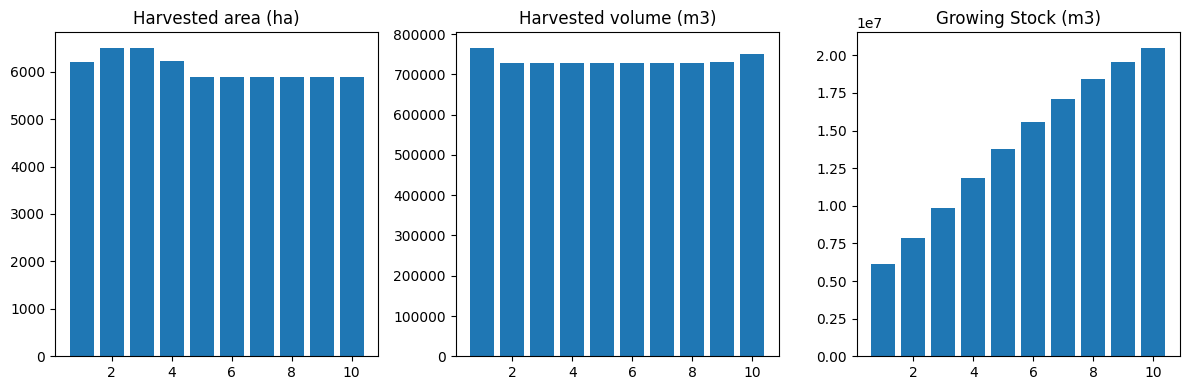

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7759
The economic indicator (the provincial government revenues) is:  264628
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


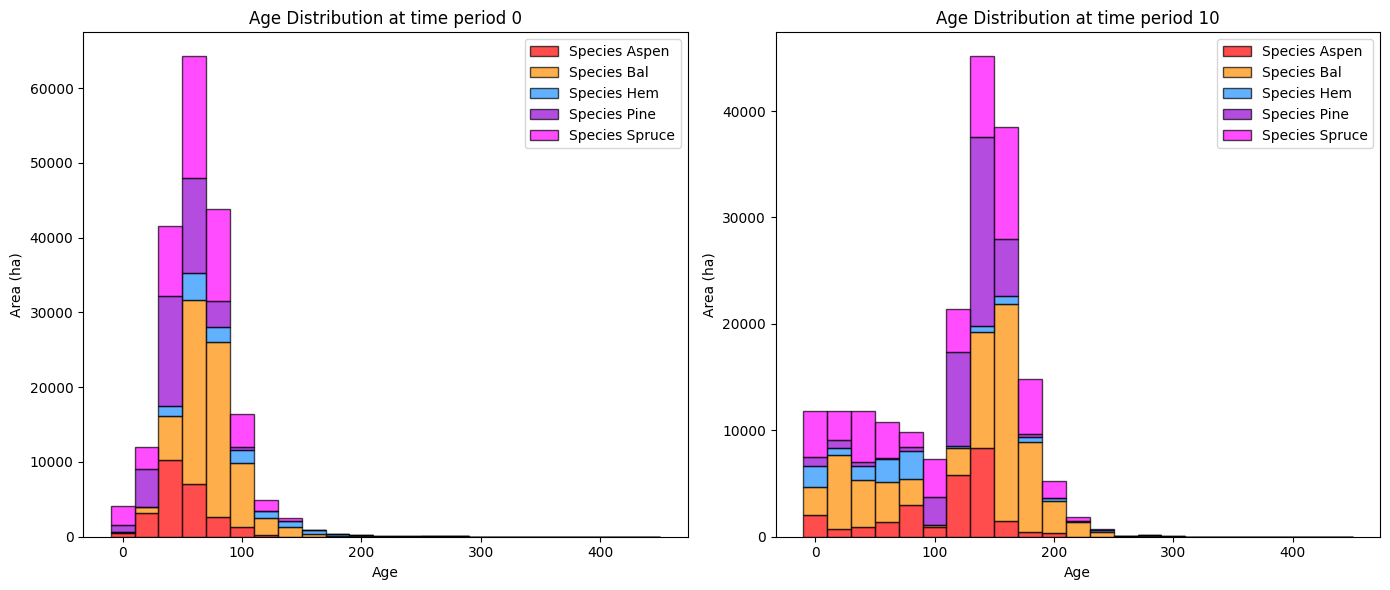

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4259.936249  4257.227716
Bal     278.565372  9020.773269  8742.207898
Aspen   273.490478  6525.108441  6251.617963
Pine      0.000000  5968.010518  5968.010518
Hem     419.699331   801.166864   381.467533

Overall diversity has **increased** by 25600.53 hectares from time period 0 to time period 10.


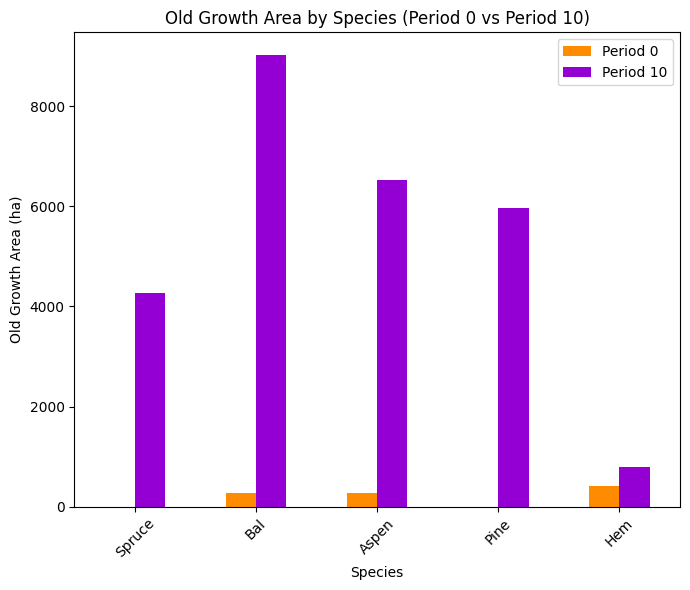

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9003

Diversity has **decreased** by 4.53% from time 0 to time 10.


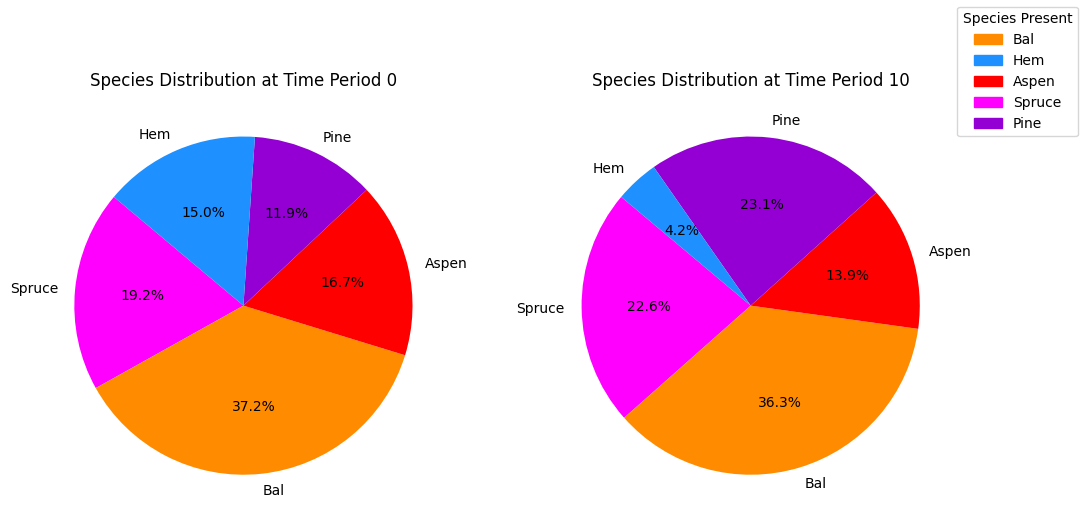

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_species_pie.pdf


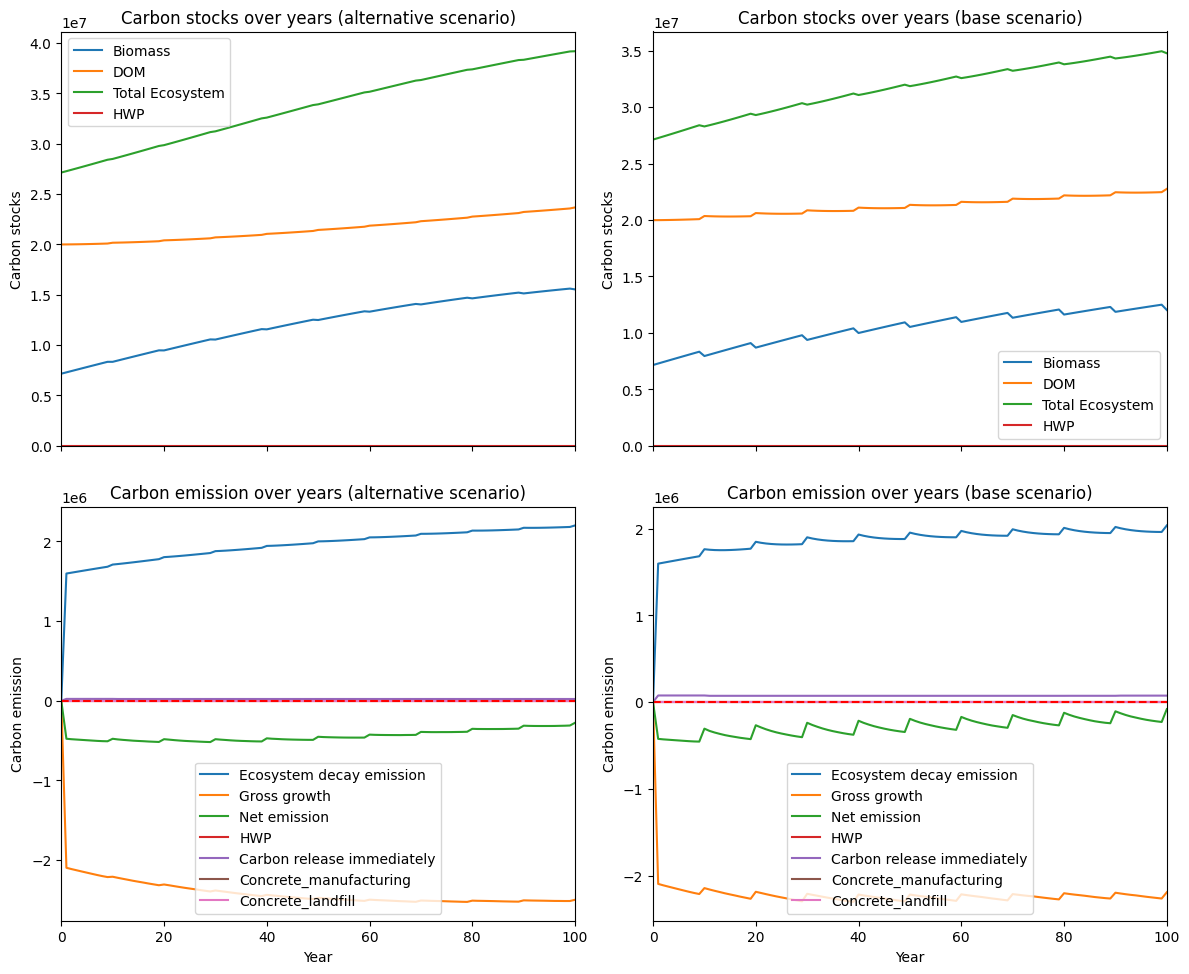

---------------------------------------------------------------------------------------
Net emission difference -2610588.7757275472
Net emission base scenario -11933410.334642585
Net emission alternative scenario -9322821.558915036
dollar_per_ton is:  3.8305535107547115
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  2646.368350  2646.368350
Bal     0.0  5628.345901  5628.345901
Aspen   0.0  5423.230622  5423.230622
Pine    0.0  1663.876682  1663.876682
Hem     0.0  1156.391480  1156.391480

Overall, the old growth area has **increased** by 16518.21 hectares in the alternative scenario compared to the base scenario.


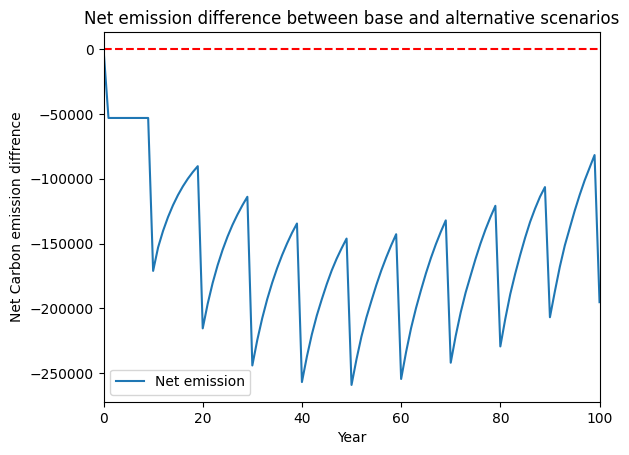

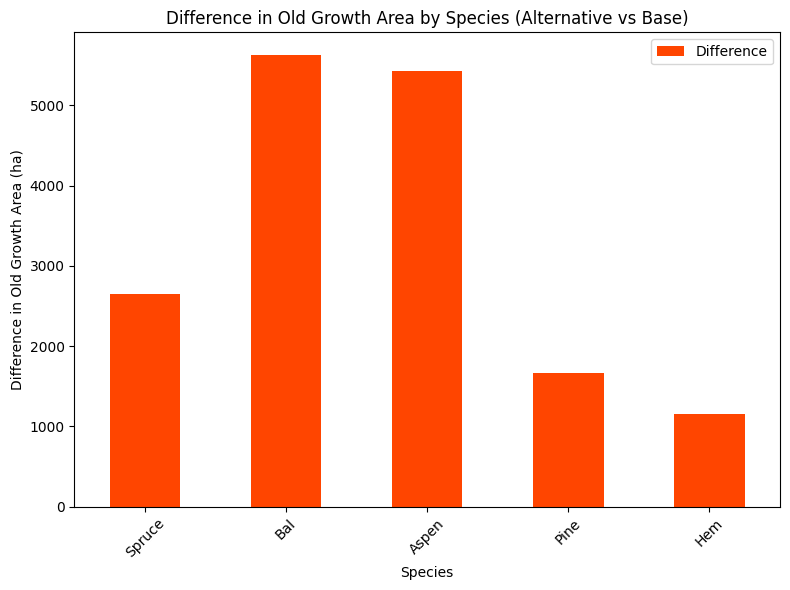

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_age_difference.pdf


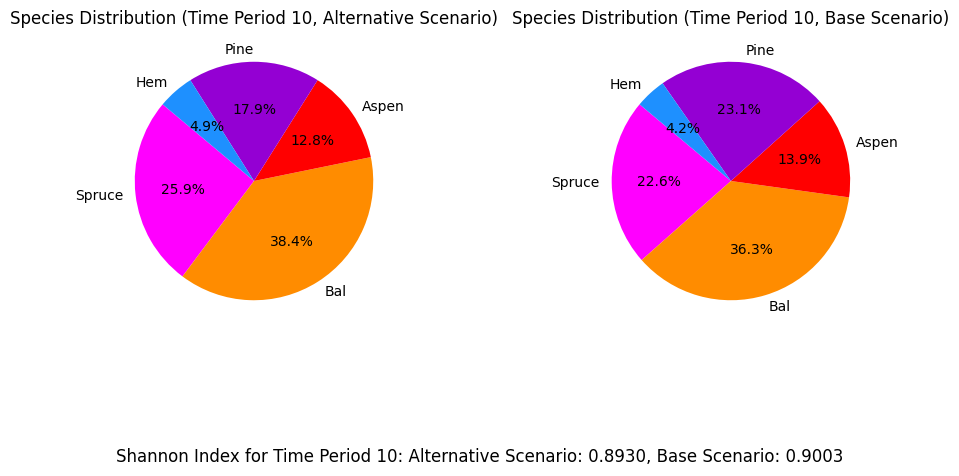

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_ha_gldbr_AAC_20%...
running the scenario for the Golden Bear mining site (20%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x05723b1c
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.19s
Presolved: 1911 rows, 32226 

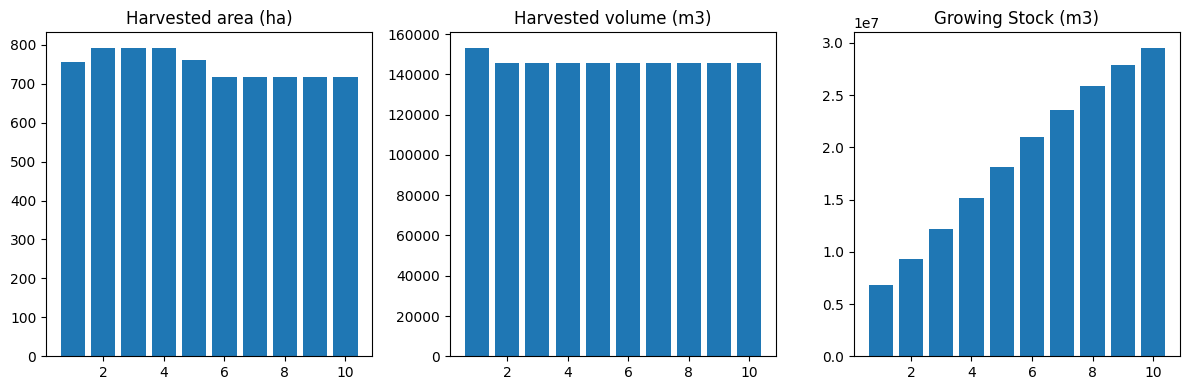

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_20%_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  1546
The economic indicator (the provincial government revenues) is:  52752
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


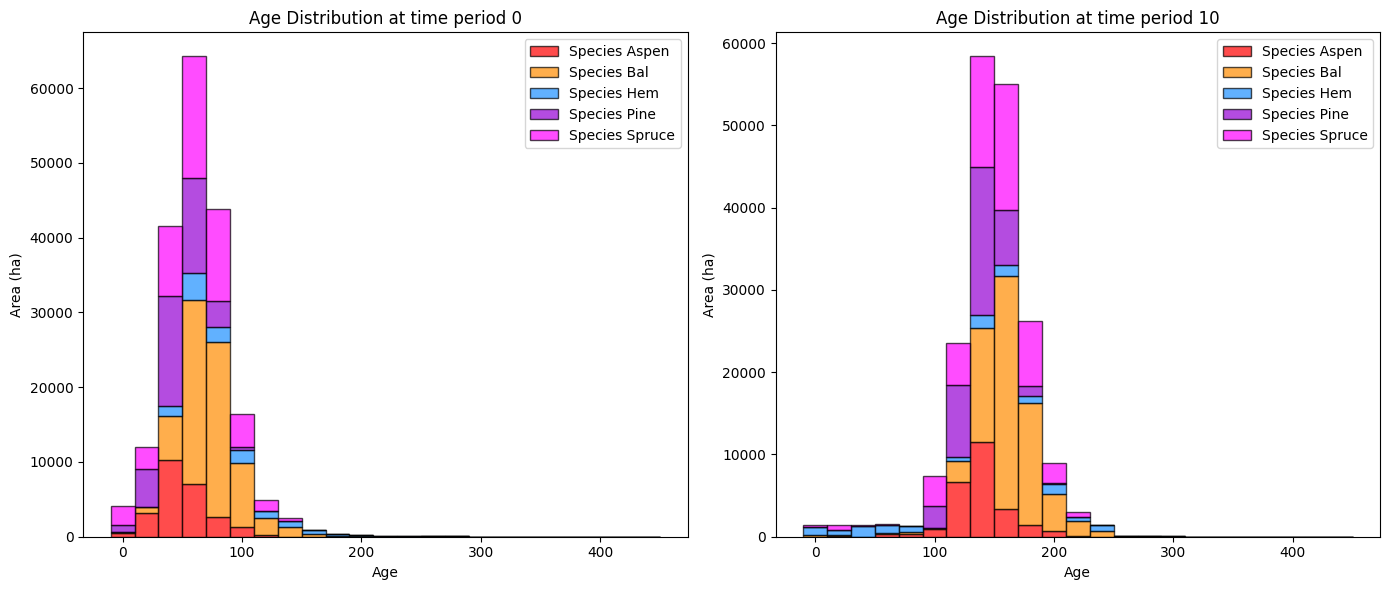

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_20%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   7631.878145   7629.169611
Bal     278.565372  15437.808084  15159.242712
Aspen   273.490478  12500.156018  12226.665540
Pine      0.000000   7631.887200   7631.887200
Hem     419.699331   2337.796602   1918.097272

Overall diversity has **increased** by 44565.06 hectares from time period 0 to time period 10.


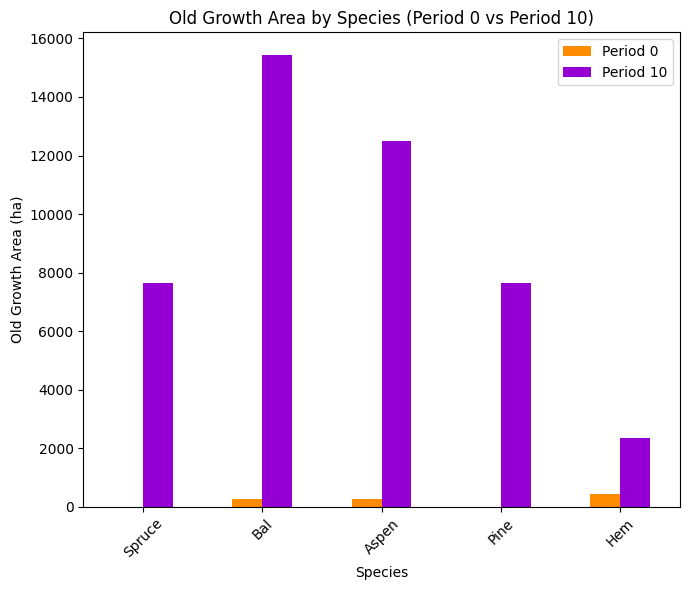

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_20%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8988

Diversity has **decreased** by 4.68% from time 0 to time 10.


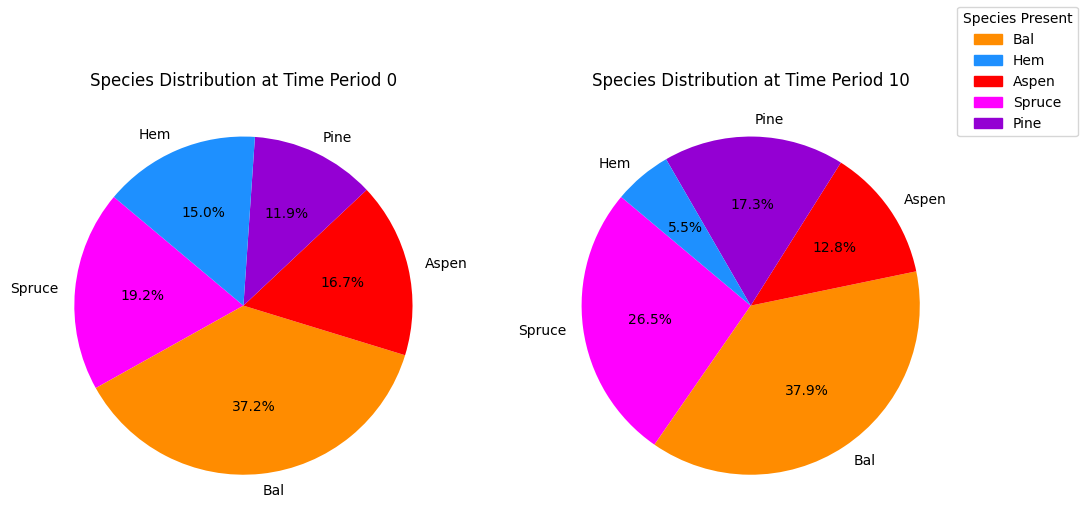

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_20%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x17162bc7
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.20s
Presolved: 1911 rows, 32225 columns, 407291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

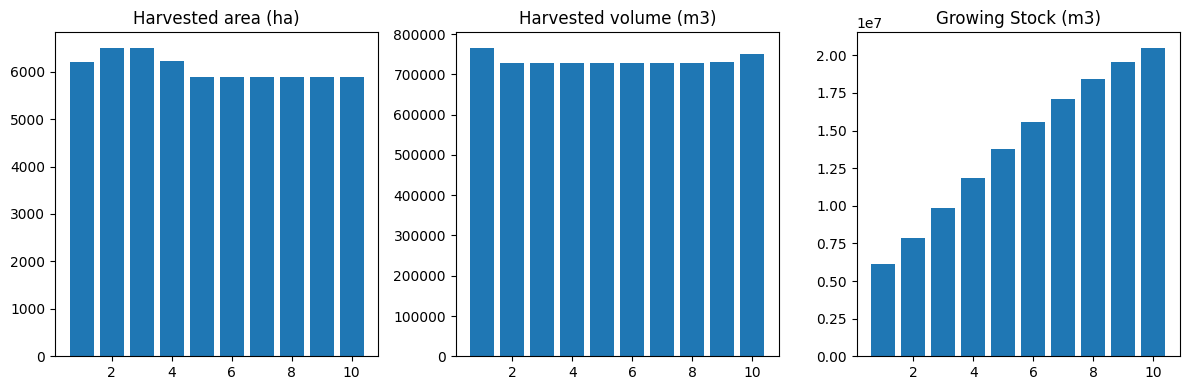

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7759
The economic indicator (the provincial government revenues) is:  264628
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


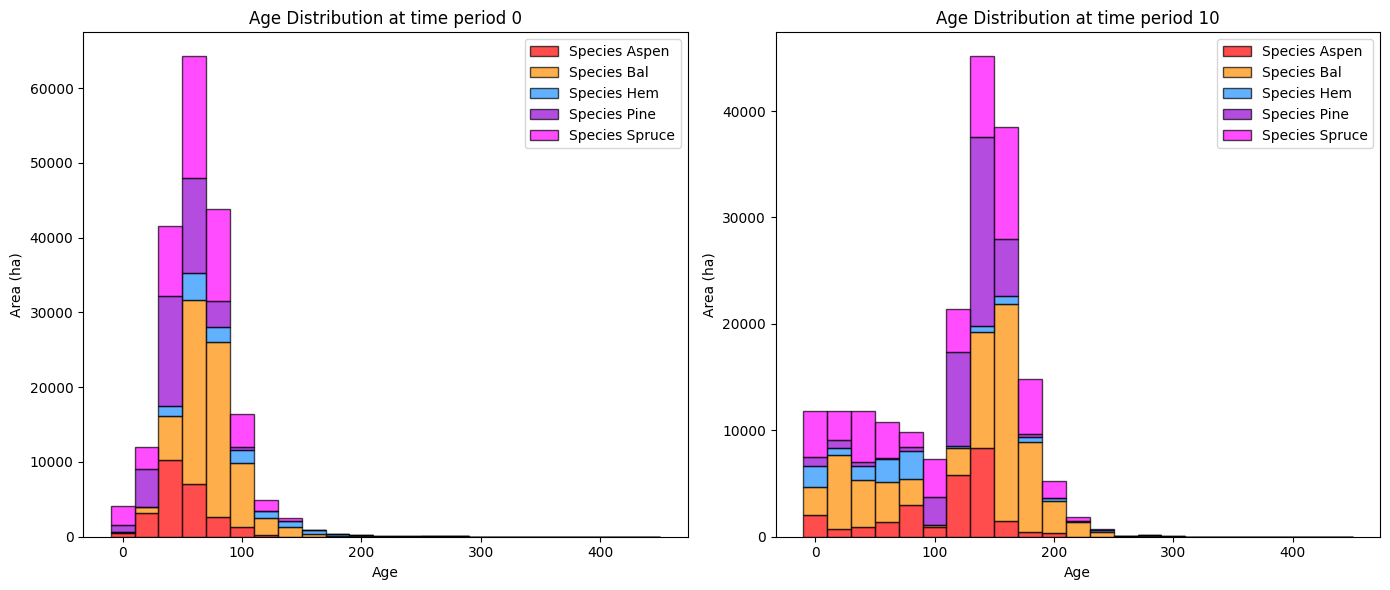

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4259.936249  4257.227716
Bal     278.565372  9020.773269  8742.207898
Aspen   273.490478  6525.108441  6251.617963
Pine      0.000000  5968.010518  5968.010518
Hem     419.699331   801.166864   381.467533

Overall diversity has **increased** by 25600.53 hectares from time period 0 to time period 10.


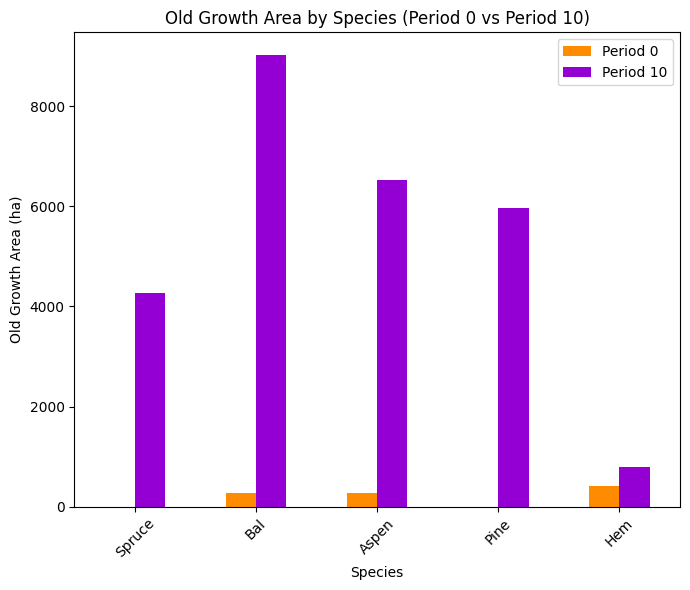

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9003

Diversity has **decreased** by 4.53% from time 0 to time 10.


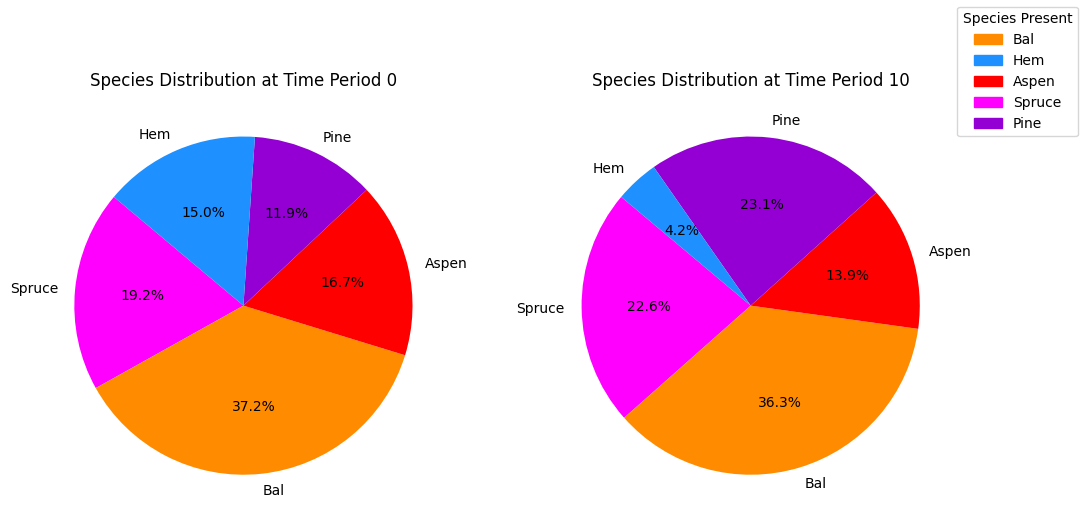

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_species_pie.pdf


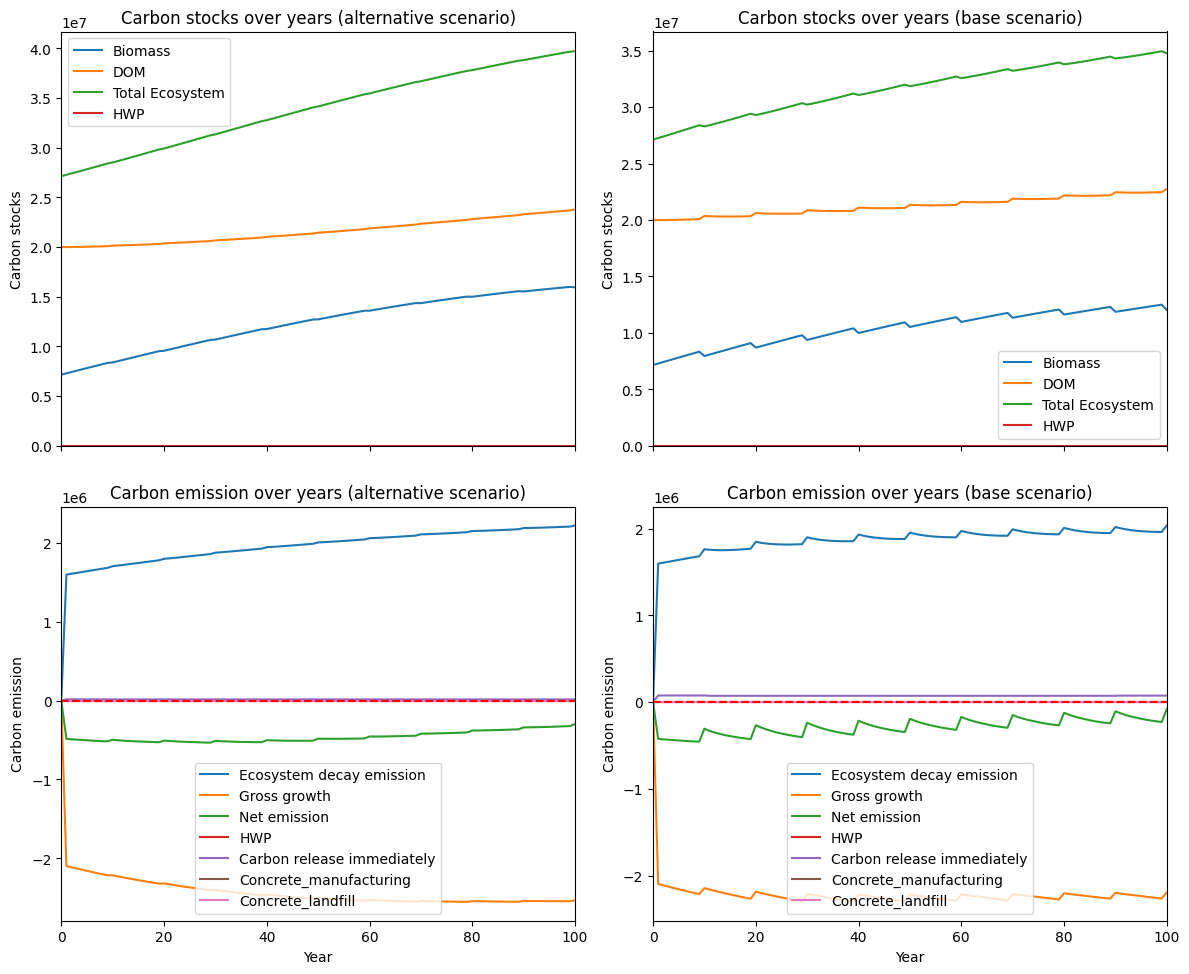

---------------------------------------------------------------------------------------
Net emission difference -2930233.813281483
Net emission base scenario -12253055.372196518
Net emission alternative scenario -9322821.558915036
dollar_per_ton is:  3.4126969508966565
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  3371.941895  3371.941895
Bal     0.0  6417.034815  6417.034815
Aspen   0.0  5975.047577  5975.047577
Pine    0.0  1663.876682  1663.876682
Hem     0.0  1536.629739  1536.629739

Overall, the old growth area has **increased** by 18964.53 hectares in the alternative scenario compared to the base scenario.


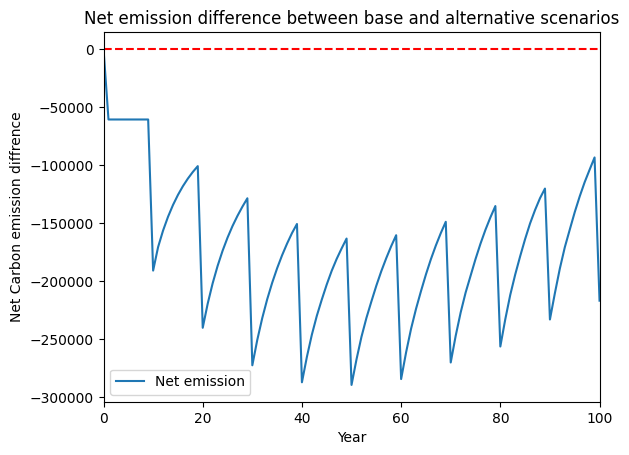

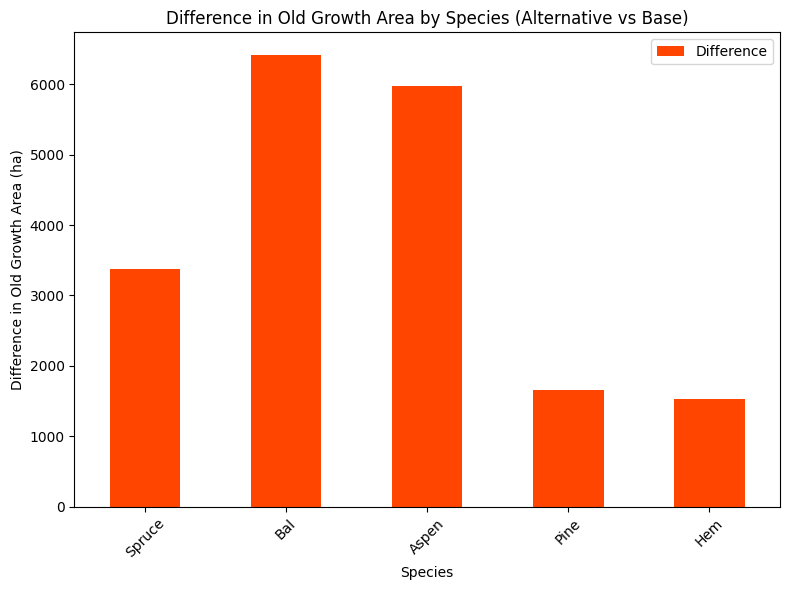

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_age_difference.pdf


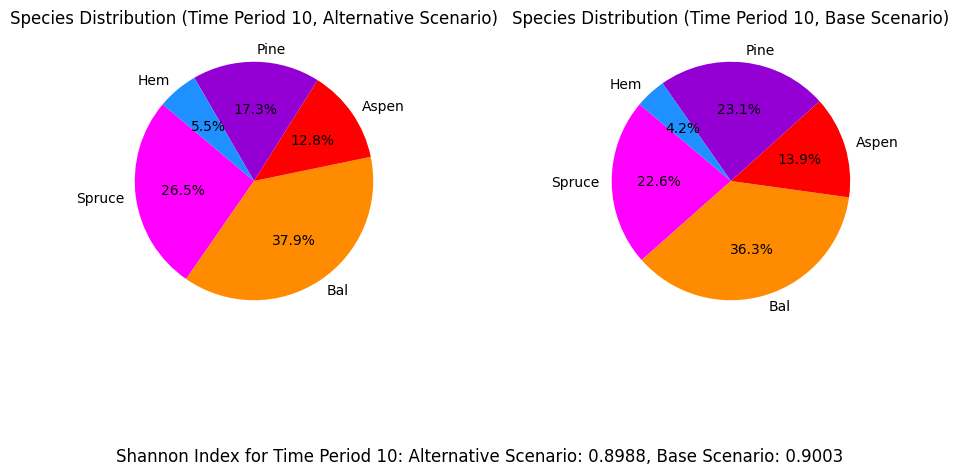

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_ha_gldbr_AAC_10%...
running the scenario for the Golden Bear mining site (10%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xb2ed4560
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.24s
Presolved: 1911 rows, 32226 

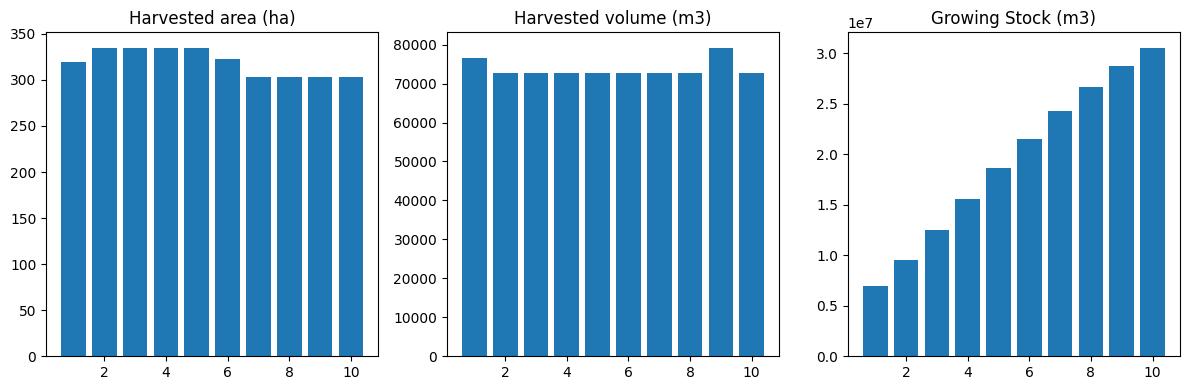

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_10%_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  780
The economic indicator (the provincial government revenues) is:  26607
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


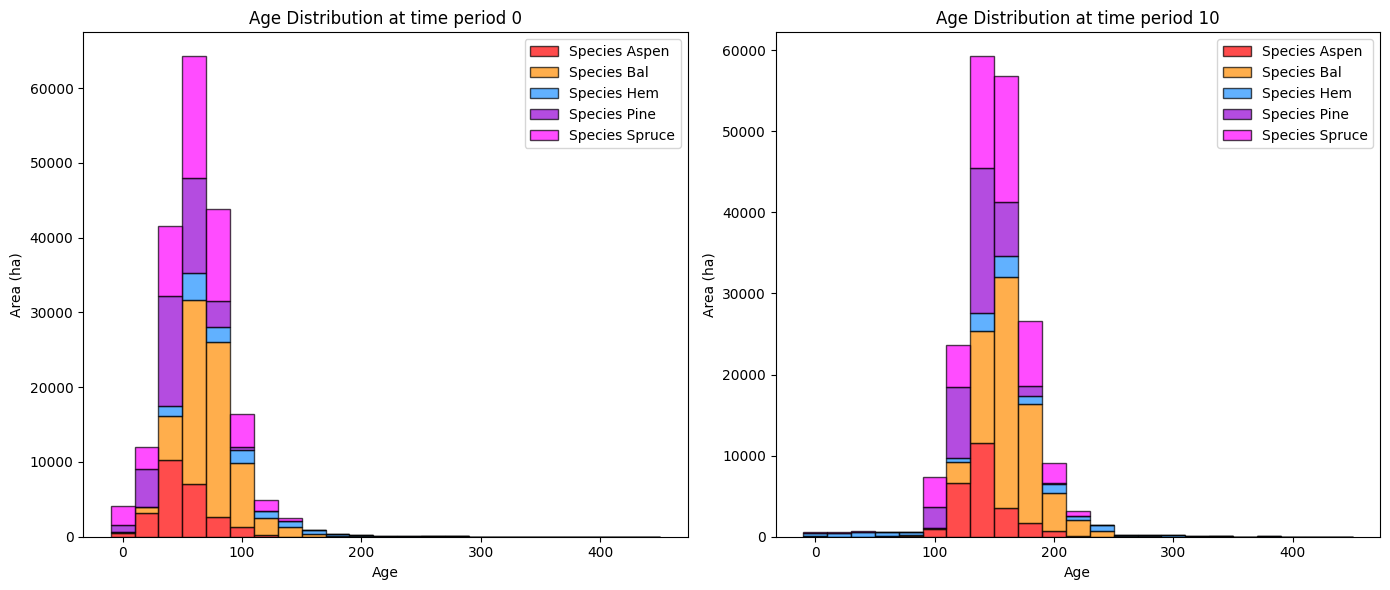

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_10%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   7877.183617   7874.475083
Bal     278.565372  15757.258242  15478.692870
Aspen   273.490478  12989.123297  12715.632819
Pine      0.000000   7631.887200   7631.887200
Hem     419.699331   2901.038689   2481.339359

Overall diversity has **increased** by 46182.03 hectares from time period 0 to time period 10.


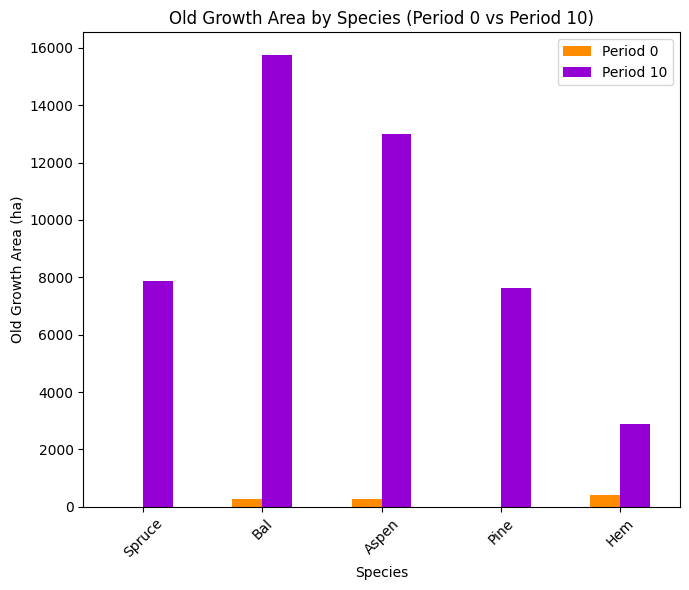

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_10%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9137

Diversity has **decreased** by 3.18% from time 0 to time 10.


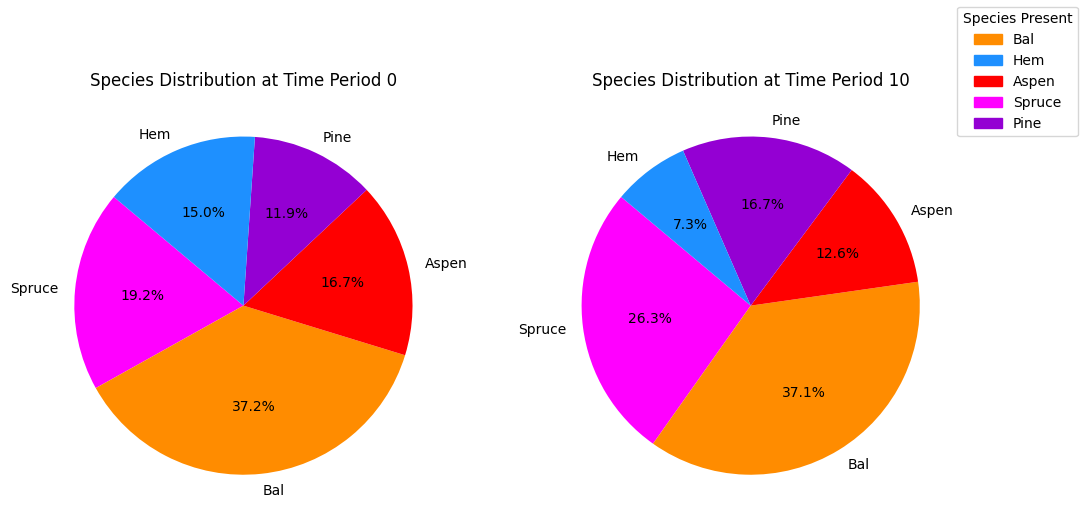

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_gldbr_AAC_10%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x17162bc7
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 3905 columns
Presolve time: 0.19s
Presolved: 1911 rows, 32225 columns, 407291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

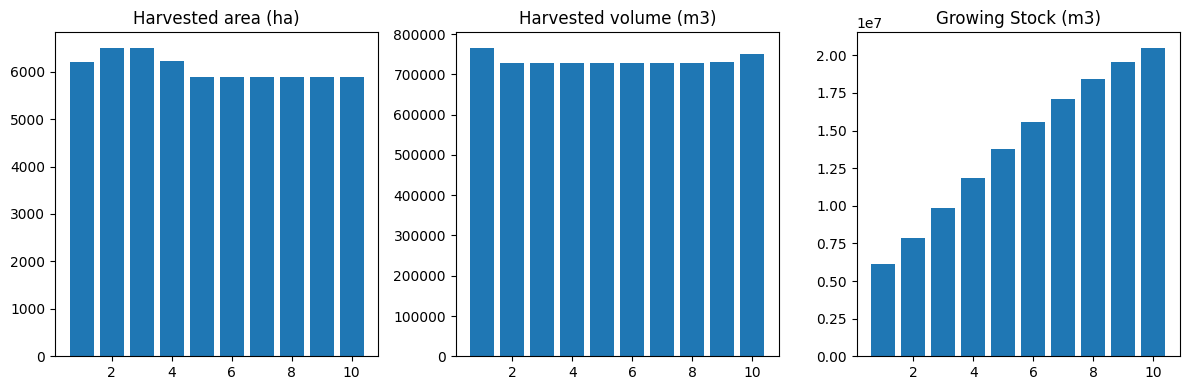

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7759
The economic indicator (the provincial government revenues) is:  264628
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


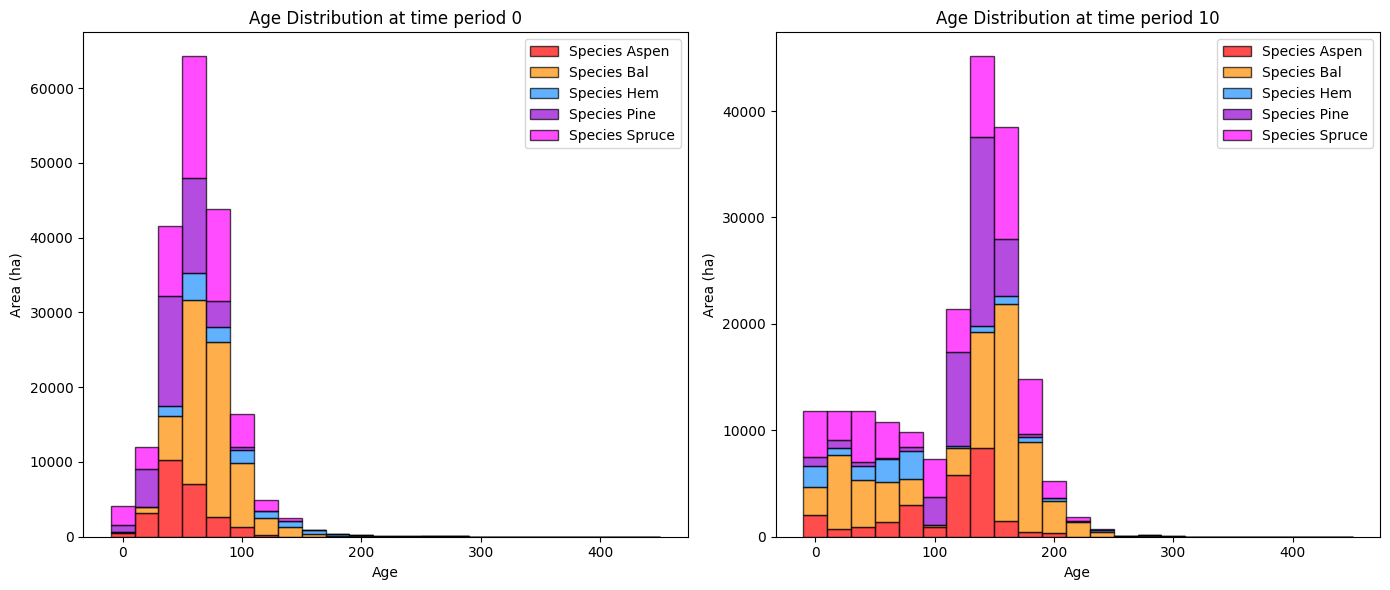

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4259.936249  4257.227716
Bal     278.565372  9020.773269  8742.207898
Aspen   273.490478  6525.108441  6251.617963
Pine      0.000000  5968.010518  5968.010518
Hem     419.699331   801.166864   381.467533

Overall diversity has **increased** by 25600.53 hectares from time period 0 to time period 10.


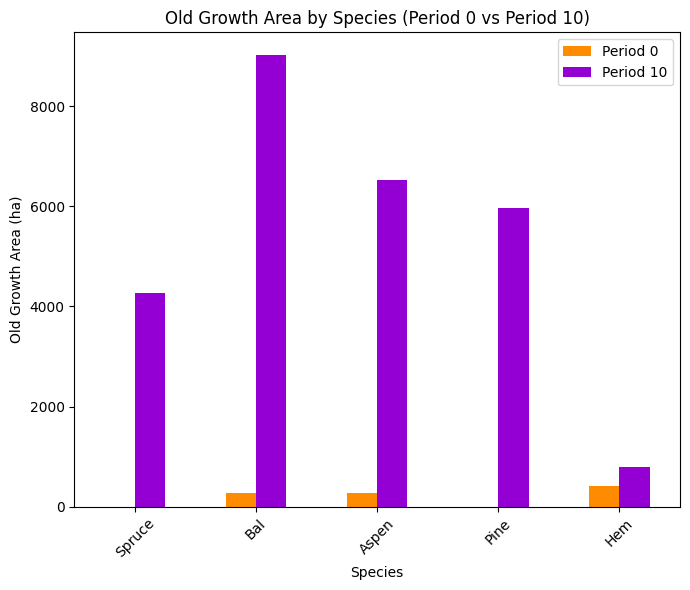

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9003

Diversity has **decreased** by 4.53% from time 0 to time 10.


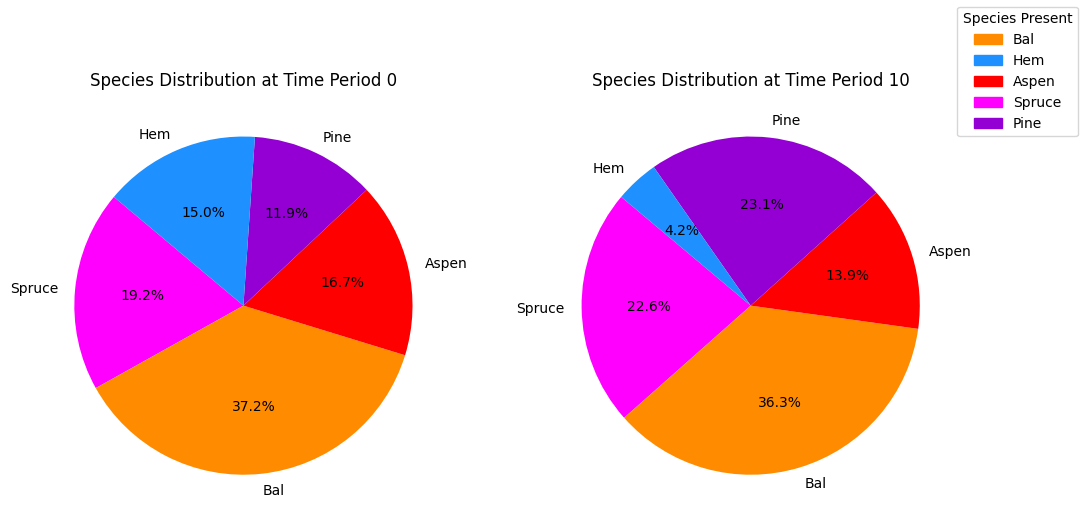

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_bau_gldbr_species_pie.pdf


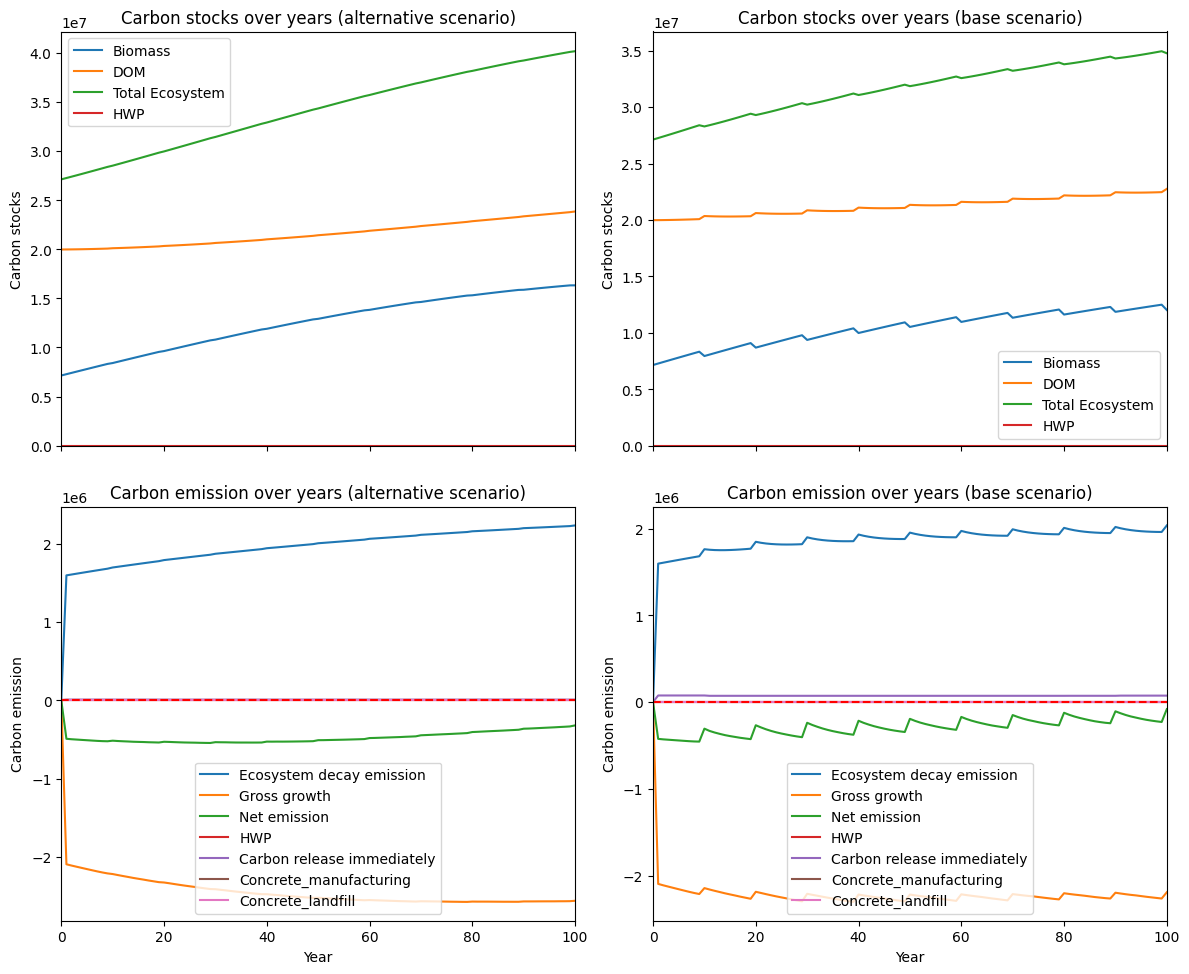

---------------------------------------------------------------------------------------
Net emission difference -3245505.384448035
Net emission base scenario -12568326.943363072
Net emission alternative scenario -9322821.558915036
dollar_per_ton is:  3.0811842272449983
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  3617.247368  3617.247368
Bal     0.0  6736.484973  6736.484973
Aspen   0.0  6464.014856  6464.014856
Pine    0.0  1663.876682  1663.876682
Hem     0.0  2099.871826  2099.871826

Overall, the old growth area has **increased** by 20581.50 hectares in the alternative scenario compared to the base scenario.


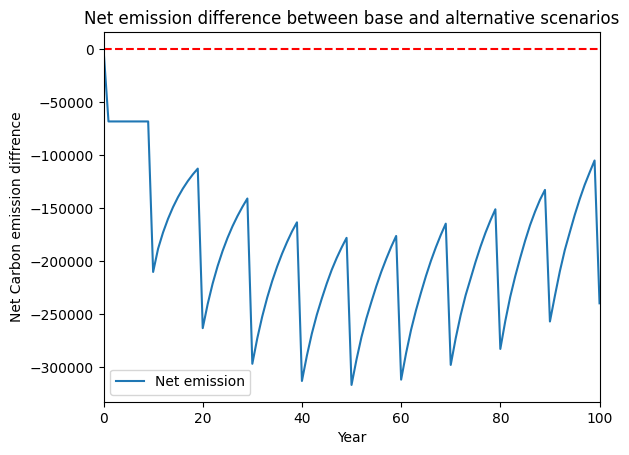

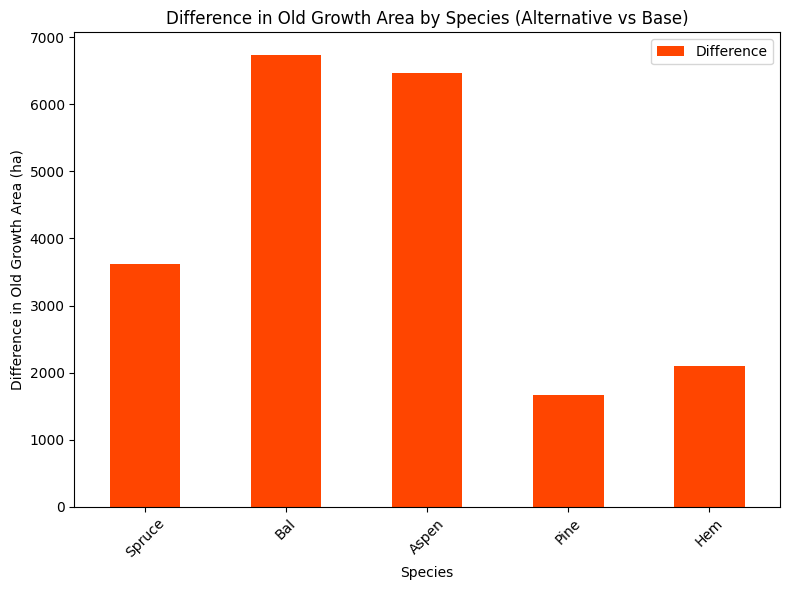

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_age_difference.pdf


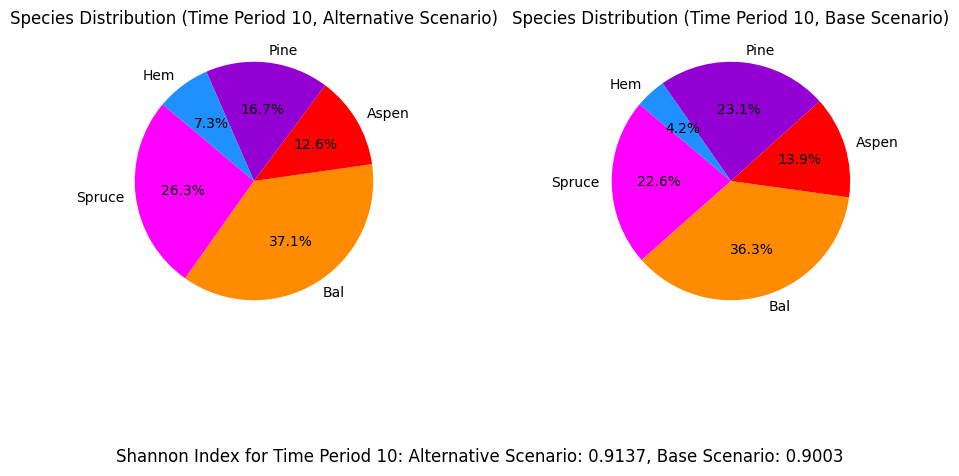

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_ha_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
It took 108.0 minutes to run all scenarios.


In [25]:
Start = time.time()
scenario_names = scenario_options.get(case_study, [])
for scenario_name in scenario_names:
    print(f"Running for {case_study}_{obj_mode}_{scenario_name}...")
    results_scenarios(fm, 
                      clt_percentage, 
                      credibility, 
                      budget_input, 
                      n_steps, 
                      max_harvest, 
                      scenario_name, 
                      displacement_effect, 
                      hwp_pool_effect_value, 
                      release_immediately_value, 
                      case_study, 
                      obj_mode,                   
                      pickle_output_base=False, 
                      pickle_output_alter=False)
print('It took', round((time.time() - Start) / 60, 1), "minutes to run all scenarios.")

In [26]:
print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")

It took 108.0 minutes to run this script.
